# Single Index Model
The Single Index Model is a regression model that describes the relationship between the returns of a security and the returns of a market index. The model is given by the equation:
$$ R_i = \alpha_i + \beta_i R_m + \epsilon_i $$
Where:
- $R_i$ is the return of security $i$
- $\alpha_i$ is the intercept term, representing the expected return of security $i$ when the market return is zero
- $\beta_i$ is the slope term, representing the sensitivity of security $i$ to the market return
- $R_m$ is the return of the market index
- $\epsilon_i$ is the error term, representing the idiosyncratic risk of security $i$ 

The Alpha ($\alpha_i$) represents the portion of the security's return that is not explained by the market return. A positive alpha indicates that the security has outperformed the market, while a negative alpha indicates underperformance. The Beta ($\beta_i$) measures the sensitivity of the security's returns to changes in the market return. A beta greater than 1 indicates that the security is more volatile than the market, while a beta less than 1 indicates that it is less volatile. The error term ($\epsilon_i$) captures the idiosyncratic risk of the security, which is the risk that is specific to that security and cannot be diversified away.



### Firm-Specific Risk, Systematic Risk, and Total Risk
- **Firm-Specific Risk**: This is the risk that is unique to a particular company or industry. It can be caused by factors such as management decisions, product recalls, or regulatory changes. Firm-specific risk can be diversified away by holding a well-diversified portfolio of securities.
- **Systematic Risk**: This is the risk that affects the entire market or economy. It can be caused by factors such as interest rate changes, inflation, or geopolitical events. Systematic risk cannot be diversified away and is measured by the beta of a security.
- **Total Risk**: This is the combination of firm-specific risk and systematic risk. It is measured by the standard deviation of a security's returns. Total risk can be reduced through diversification, but it cannot be eliminated entirely.


Total Risk is the combination of systematic risk and firm-specific risk. Systematic risk is the risk that affects the entire market, while firm-specific risk is the risk that is unique to a particular company. Total risk can be reduced through diversification, as holding a variety of assets can help to mitigate the impact of firm-specific risk. However, systematic risk cannot be diversified away, as it affects all assets in the market.

Example Using Tesla and the S&P 500 first.

In [1]:
from portfolio import config
from portfolio.data.data_ingestion import DataIngestion
from portfolio.models.single_index_model import SingleIndexModel

# load in data ingestion

obj = DataIngestion()

# load in all prices

prices = obj.get_all_prices()

# get returns for prices

returns = obj.compute_returns(prices)


# run single index model

sim = SingleIndexModel()

get_models = sim.get_models(
    tickers=config.all_tickers,
    market_ticker=config.sp500_ticker,
    returns=returns
)


# example using Tesla first

betas = sim.get_betas()
alphas = sim.get_alphas()
systematic_risks = sim.get_systematic_risks()
error_terms = sim.get_residuals()
firm_specific_risk = sim.get_firm_specific_risks()
systematic_risks = sim.get_systematic_risks()
total_risks = sim.get_total_risks()




print(f"Alpha Values for Tesla: {alphas.get('TSLA')}")
print(f"Beta Values for Tesla: {betas.get('TSLA')}")
print(f"Error Terms for Tesla: {error_terms.get('TSLA')}")
print(f"Firm Specific Risk for Tesla: {firm_specific_risk.get('TSLA')}")
print(f"Systematic Risk for Tesla: {systematic_risks.get('TSLA')}")
print(f"Total Risks for Tesla: {total_risks.get('TSLA')}")


[*********************100%***********************]  121 of 121 completed


Alpha Values for Tesla: -0.007023334609243938
Beta Values for Tesla: 1.7396937834759294
Error Terms for Tesla: Date
2026-03-16    0.000544
2026-03-17    0.012063
2026-03-18    0.014442
2026-03-19   -0.019968
2026-03-20    0.000911
2026-03-23    0.022129
2026-03-24    0.019258
2026-03-25    0.005219
2026-03-26    0.001445
2026-03-27    0.008488
2026-03-30   -0.004215
2026-03-31    0.002702
2026-04-01    0.020134
2026-04-02   -0.049142
2026-04-06   -0.022226
2026-04-07   -0.011785
dtype: float64
Firm Specific Risk for Tesla: 0.0003246327620999251
Systematic Risk for Tesla: 0.00042084056681278395
Total Risks for Tesla: 0.0007454733289127091


### Now for the SP500

In [2]:
# sp500
print(f"Alpha Values for SP500: {alphas.get('^GSPC')}")
print(f"Beta Values for SP500: {betas.get('^GSPC')}")
print(f"Error Terms for SP500: {error_terms.get('^GSPC')}")
print(f"Firm Specific Risk for SP500: {firm_specific_risk.get('^GSPC')}")
print(f"Systematic Risk for SP500: {systematic_risks.get('^GSPC')}")
print(f"Total Risks for SP500: {total_risks.get('^GSPC')}")

Alpha Values for SP500: 4.336808689942018e-19
Beta Values for SP500: 1.0000000000000004
Error Terms for SP500: Date
2026-03-16   -5.204170e-18
2026-03-17   -1.734723e-18
2026-03-18    5.204170e-18
2026-03-19    8.673617e-19
2026-03-20    6.938894e-18
2026-03-23   -5.204170e-18
2026-03-24    1.301043e-18
2026-03-25   -3.469447e-18
2026-03-26    6.938894e-18
2026-03-27    6.938894e-18
2026-03-30    1.734723e-18
2026-03-31   -1.387779e-17
2026-04-01   -3.469447e-18
2026-04-02   -8.673617e-19
2026-04-06   -1.734723e-18
2026-04-07   -7.589415e-19
dtype: float64
Firm Specific Risk for SP500: 2.828785829280564e-35
Systematic Risk for SP500: 0.00013905031392768766
Total Risks for SP500: 0.00013905031392768766


### Explanation of the output
The Beta value for the Sp500 is 1, which means that the returns of the S&P 500 are perfectly correlated with the market return. The Alpha value is close to zero, which indicates that the S&P 500 has not outperformed or underperformed the market. The Sp500 is being compared to itself, so it makes sense that the beta is 1 and the alpha is close to zero. The error term is also close to zero.

In [3]:
# r2 score for tsla
print(f"R2 Score for TSLA: {get_models['TSLA'].rsquared}")
print(f"R2 Score for Sp500: {get_models['^GSPC'].rsquared}")

# comparison to other asset classes
print(f"R2 Score for Treasury Bond: {get_models['^TNX'].rsquared}")
print(f"R2 Score for Bitcoin: {get_models['BTC-USD'].rsquared}")
print(f"R2 Score for QQQ: {get_models['QQQ'].rsquared}")

R2 Score for TSLA: 0.5645279991795145
R2 Score for Sp500: 1.0
R2 Score for Treasury Bond: 0.4072335101019069
R2 Score for Bitcoin: 0.3752311001601041
R2 Score for QQQ: 0.9835177341764502


# Miscellaneous Plots of Single Index Model

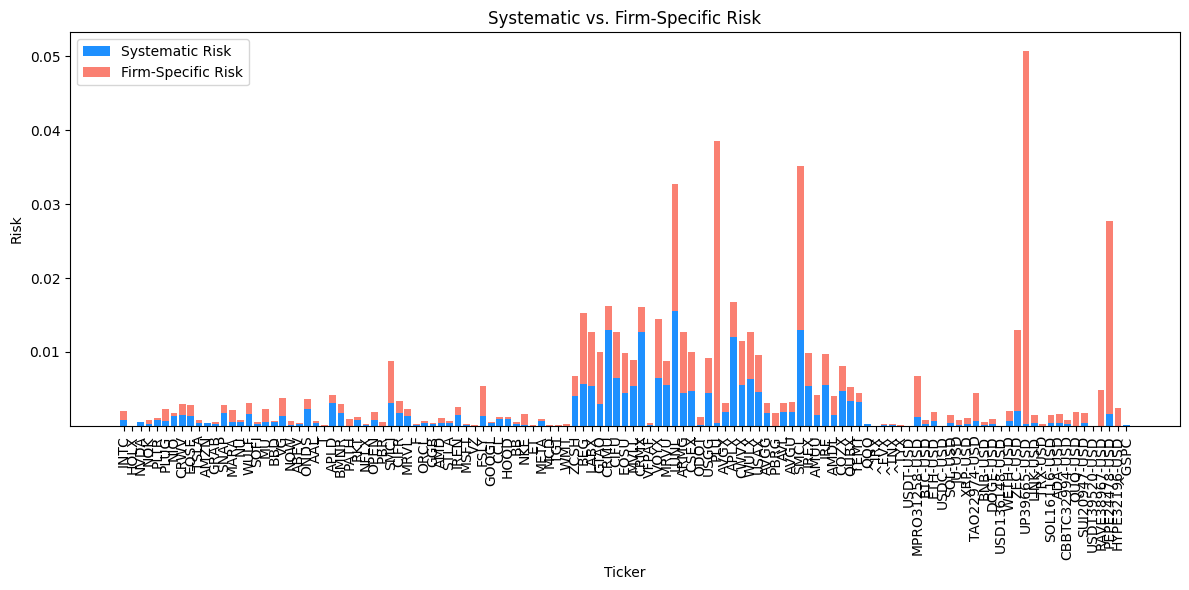

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# keys for plotting
tickers = list(systematic_risks.keys())
sys_risk = np.array([systematic_risks[t] for t in tickers])
firm_risk = np.array([firm_specific_risk[t] for t in tickers])

plt.figure(figsize=(12, 6))
plt.bar(tickers, sys_risk, label="Systematic Risk", color="dodgerblue")
plt.bar(tickers, firm_risk, bottom=sys_risk, label="Firm-Specific Risk", color="salmon")
plt.ylabel('Risk')
plt.xlabel('Ticker')
plt.title('Systematic vs. Firm-Specific Risk')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## All returns compared to Market Returns visually
This part will be long. All assets from the dataset will be compared to the market return visually. This will be done by plotting the returns of each asset against the returns of the market index (S&P 500) on a scatter plot. The slope of the line of best fit will represent the beta of each asset, while the intercept will represent the alpha. This visual representation will help to understand how each asset is correlated with the market and how much of its return can be attributed to systematic risk versus firm-specific risk.

                            OLS Regression Results                            
Dep. Variable:                   INTC   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     8.640
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0108
Time:                        11:29:44   Log-Likelihood:                 30.784
No. Observations:                  16   AIC:                            -57.57
Df Residuals:                      14   BIC:                            -56.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0103      0.009      1.088      0.2

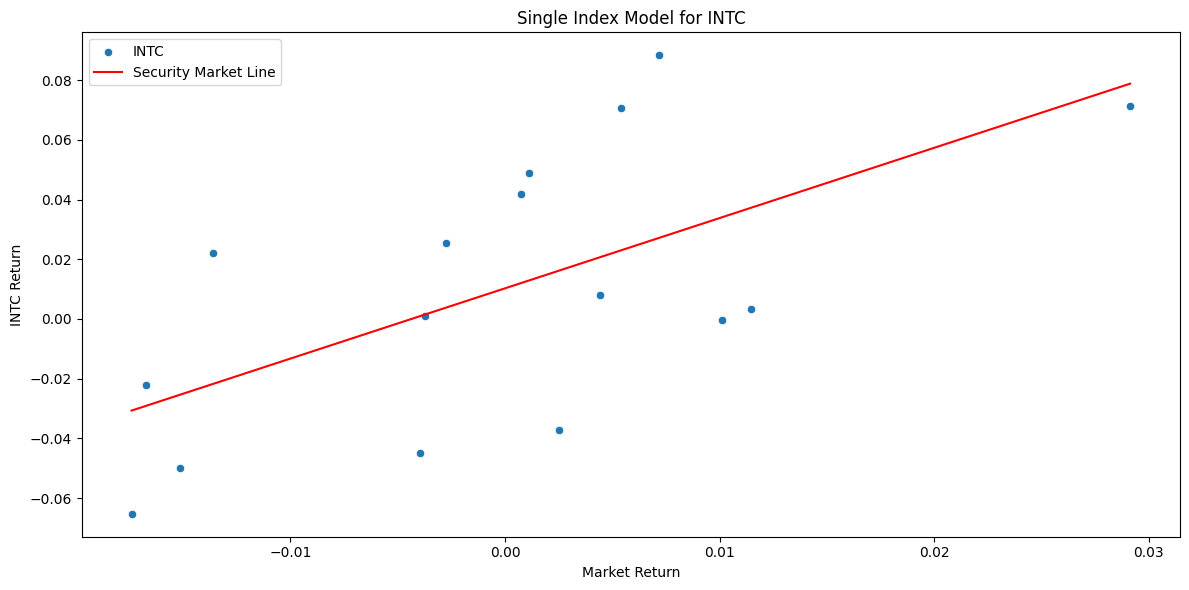

                            OLS Regression Results                            
Dep. Variable:                   HOLX   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                  0.008589
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.927
Time:                        11:29:44   Log-Likelihood:                 79.775
No. Observations:                  16   AIC:                            -155.6
Df Residuals:                      14   BIC:                            -154.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.670      0.1

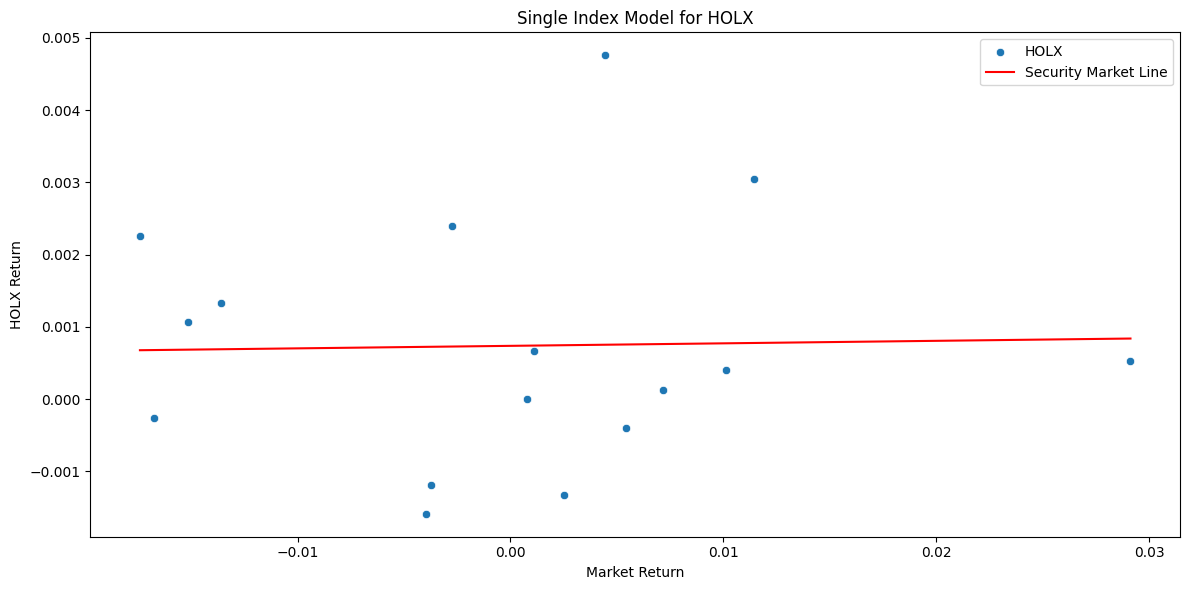

                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     103.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           7.40e-08
Time:                        11:29:45   Log-Likelihood:                 55.205
No. Observations:                  16   AIC:                            -106.4
Df Residuals:                      14   BIC:                            -104.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.002     -0.180      0.8

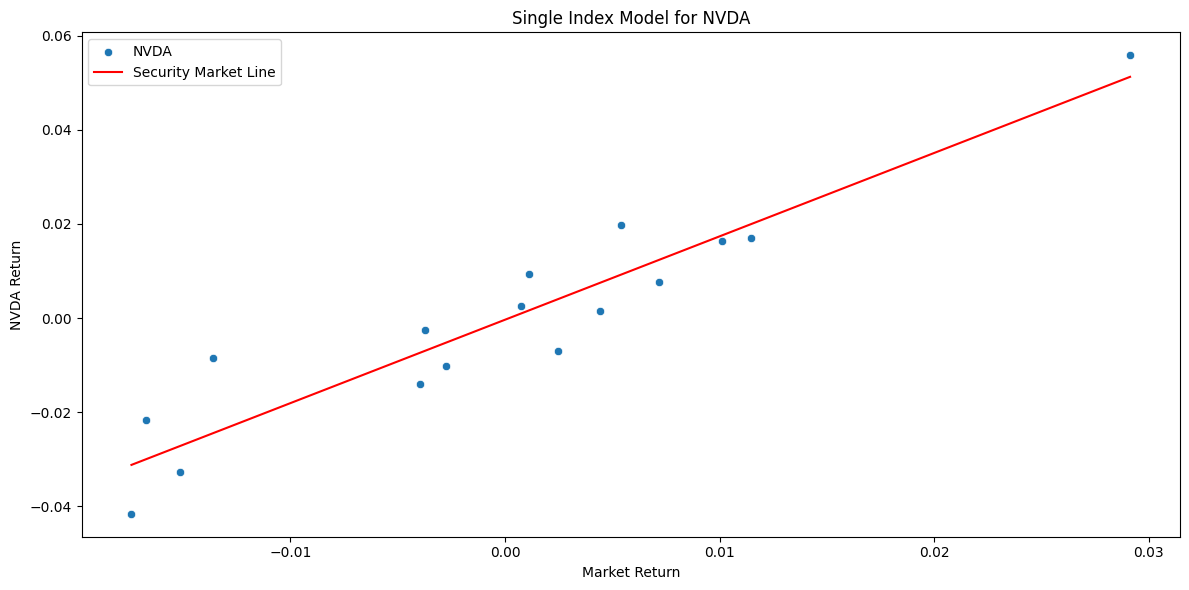

                            OLS Regression Results                            
Dep. Variable:                    NOK   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     6.929
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0197
Time:                        11:29:45   Log-Likelihood:                 37.892
No. Observations:                  16   AIC:                            -71.78
Df Residuals:                      14   BIC:                            -70.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      0.006      0.818      0.4

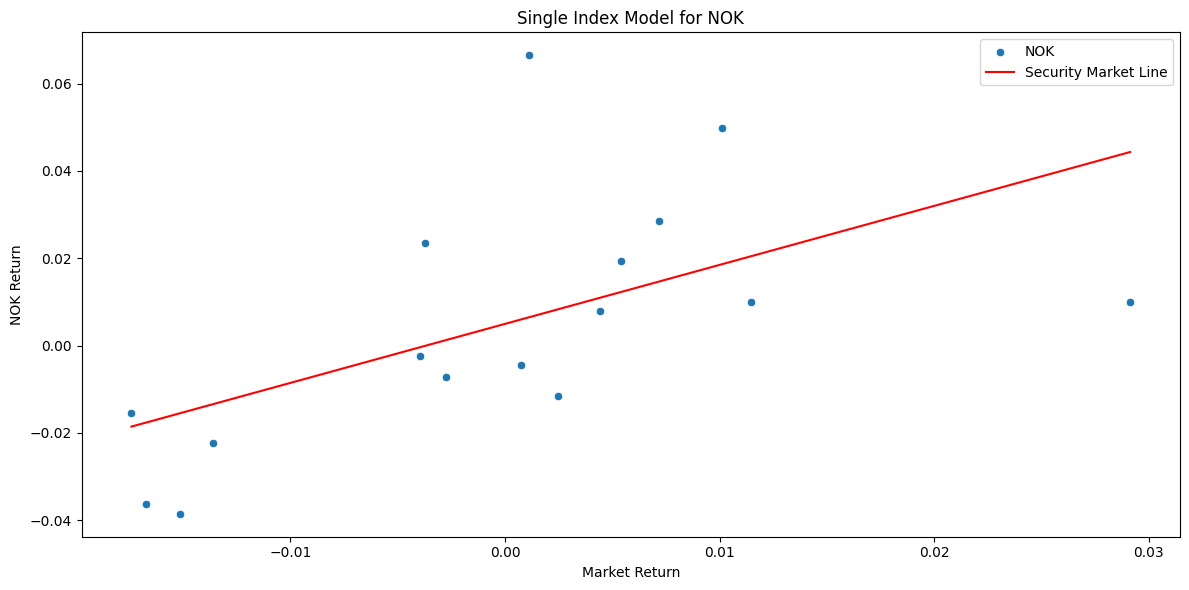

                            OLS Regression Results                            
Dep. Variable:                   PLTR   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     29.46
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           8.91e-05
Time:                        11:29:45   Log-Likelihood:                 41.095
No. Observations:                  16   AIC:                            -78.19
Df Residuals:                      14   BIC:                            -76.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.005      0.068      0.9

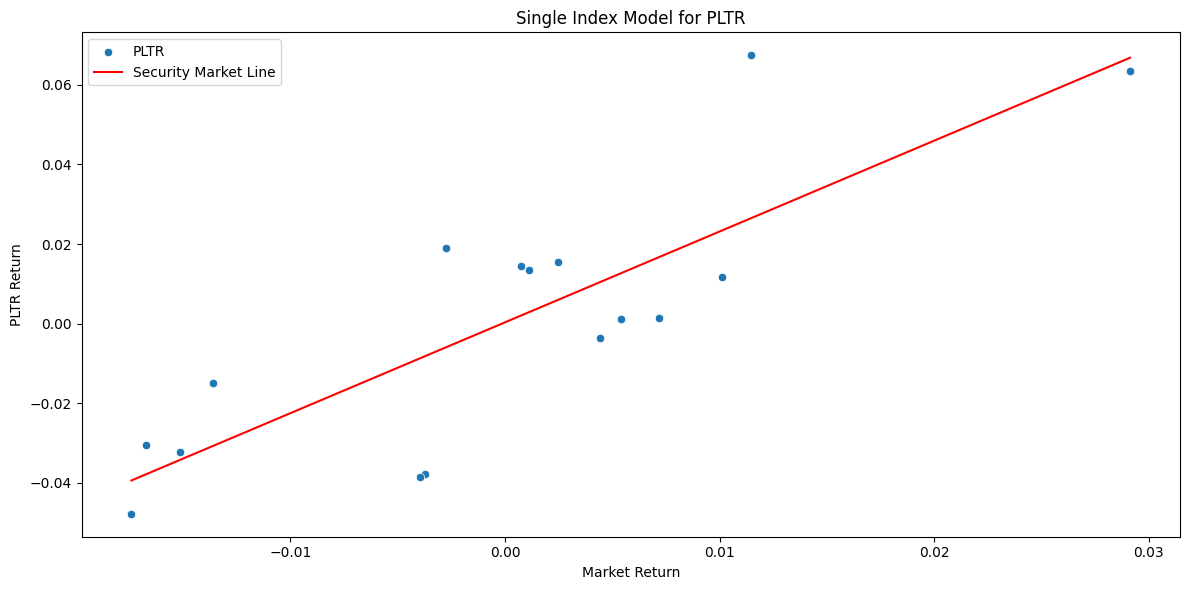

                            OLS Regression Results                            
Dep. Variable:                   PLUG   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     5.830
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0300
Time:                        11:29:45   Log-Likelihood:                 28.822
No. Observations:                  16   AIC:                            -53.64
Df Residuals:                      14   BIC:                            -52.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0112      0.011      1.054      0.3

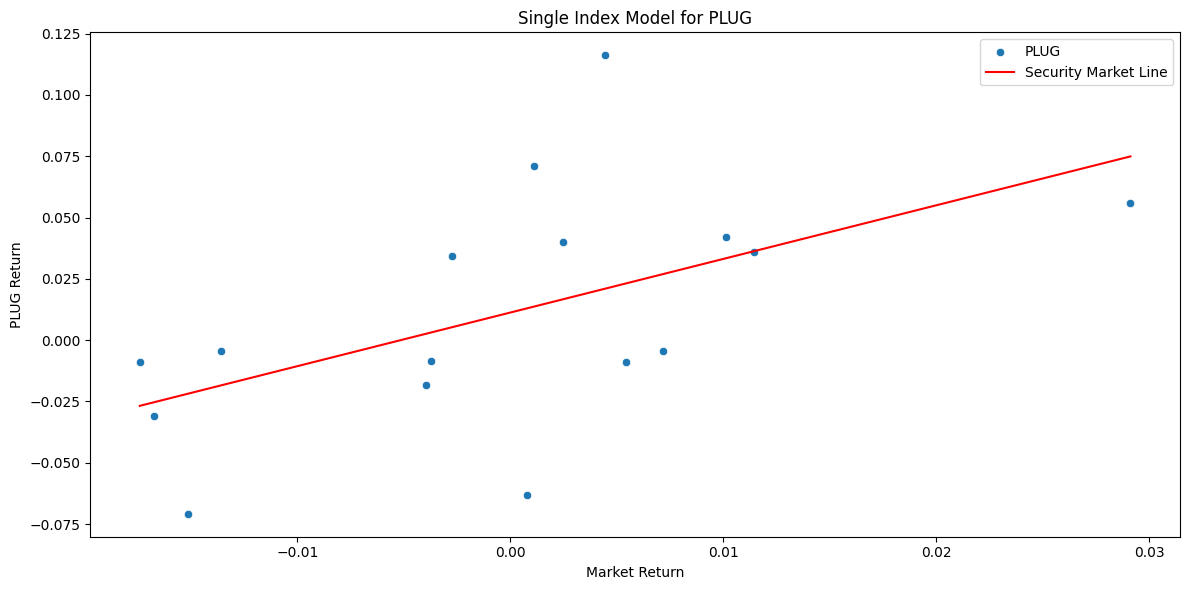

                            OLS Regression Results                            
Dep. Variable:                    NIO   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     41.31
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.58e-05
Time:                        11:29:45   Log-Likelihood:                 39.012
No. Observations:                  16   AIC:                            -74.02
Df Residuals:                      14   BIC:                            -72.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0040      0.006      0.713      0.4

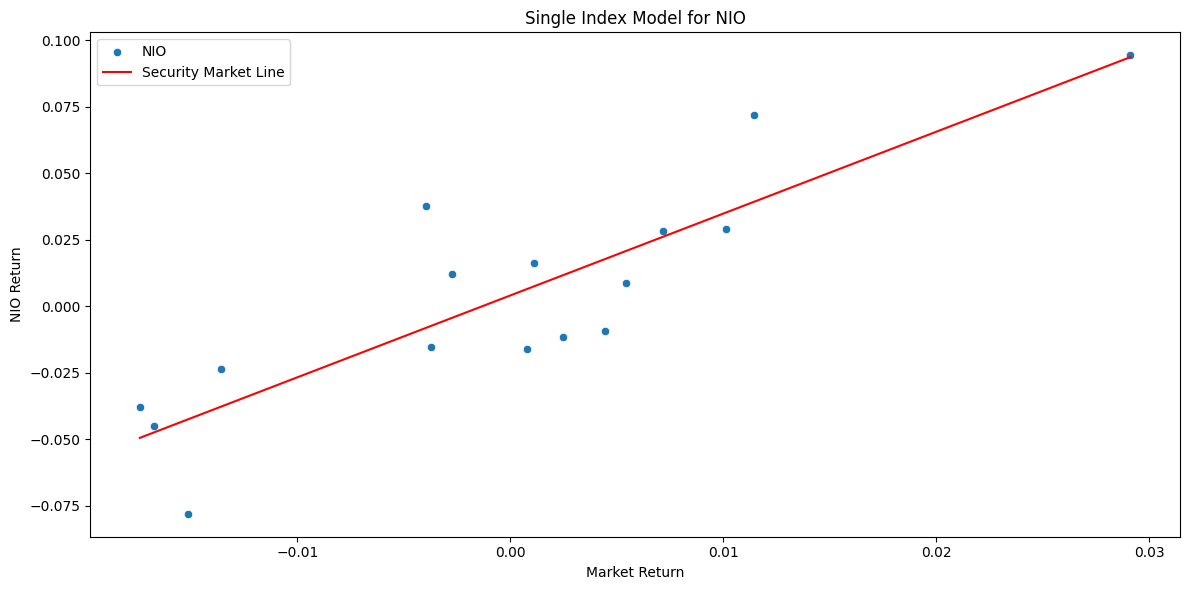

                            OLS Regression Results                            
Dep. Variable:                   CRWV   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     13.51
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00250
Time:                        11:29:45   Log-Likelihood:                 29.447
No. Observations:                  16   AIC:                            -54.89
Df Residuals:                      14   BIC:                            -53.35
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.010      0.467      0.6

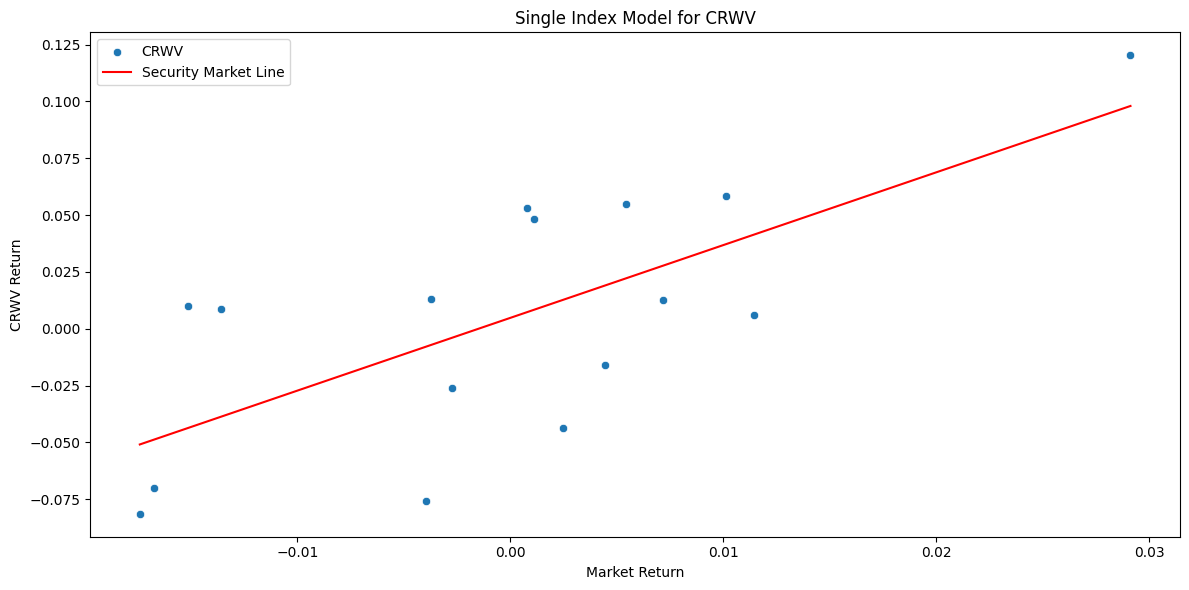

                            OLS Regression Results                            
Dep. Variable:                   EOSE   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     11.22
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00477
Time:                        11:29:46   Log-Likelihood:                 28.870
No. Observations:                  16   AIC:                            -53.74
Df Residuals:                      14   BIC:                            -52.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0134      0.011     -1.260      0.2

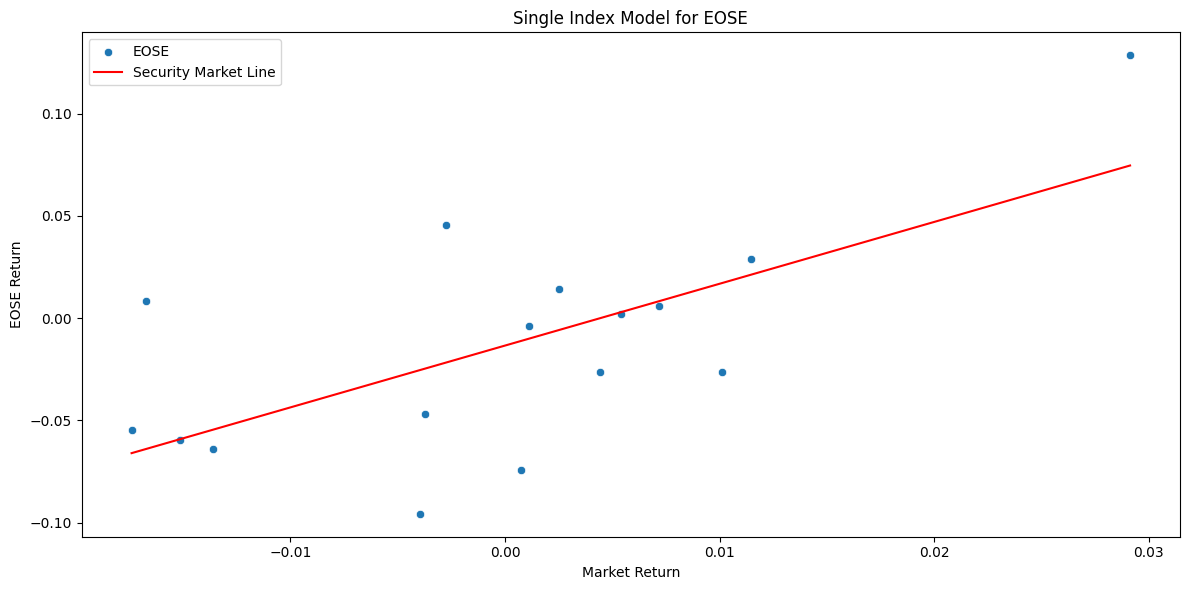

                            OLS Regression Results                            
Dep. Variable:                   TSLA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     18.15
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000792
Time:                        11:29:46   Log-Likelihood:                 41.560
No. Observations:                  16   AIC:                            -79.12
Df Residuals:                      14   BIC:                            -77.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0070      0.005     -1.458      0.1

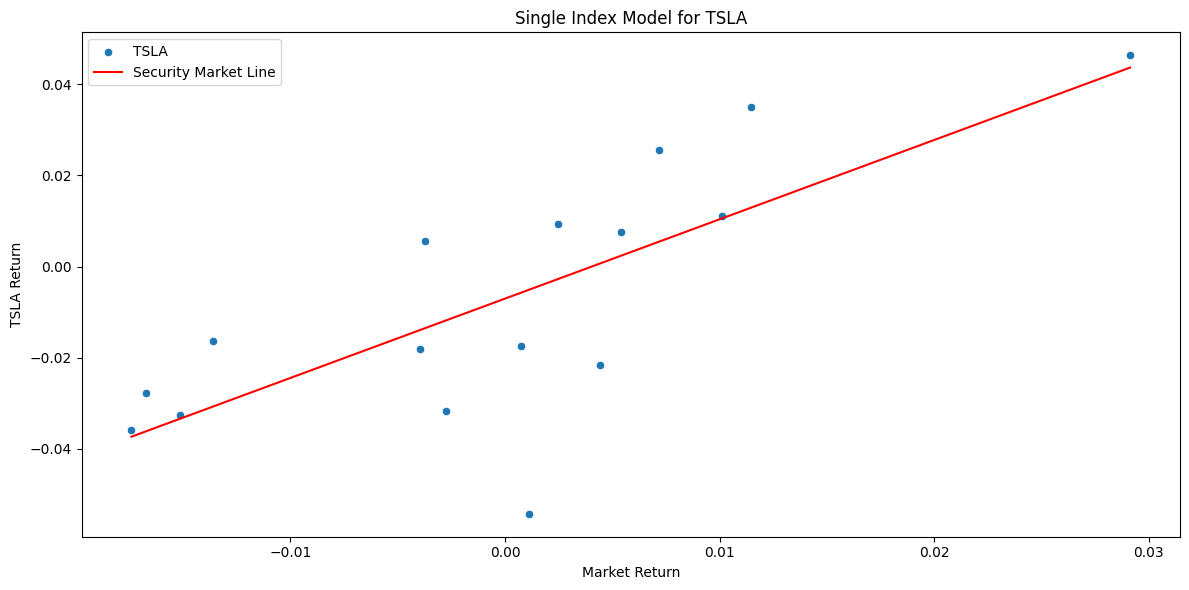

                            OLS Regression Results                            
Dep. Variable:                   AMZN   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     71.48
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           7.16e-07
Time:                        11:29:46   Log-Likelihood:                 54.372
No. Observations:                  16   AIC:                            -104.7
Df Residuals:                      14   BIC:                            -103.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.002      0.984      0.3

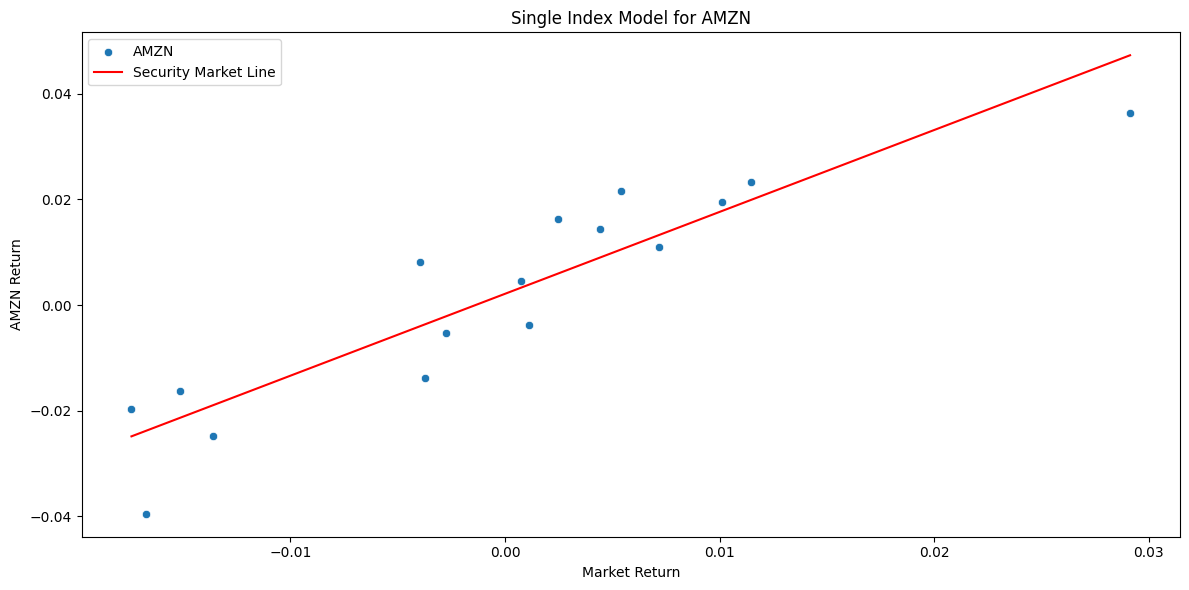

                            OLS Regression Results                            
Dep. Variable:                   GRAB   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     10.25
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00640
Time:                        11:29:46   Log-Likelihood:                 42.083
No. Observations:                  16   AIC:                            -80.17
Df Residuals:                      14   BIC:                            -78.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0026      0.005     -0.551      0.5

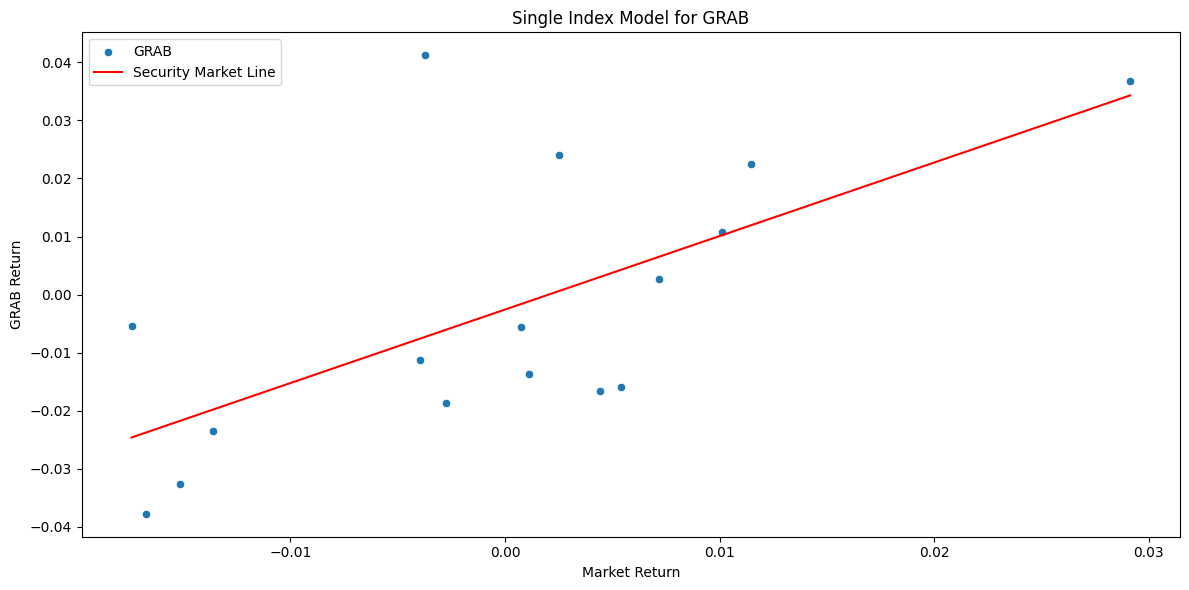

                            OLS Regression Results                            
Dep. Variable:                   SNAP   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     23.06
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000281
Time:                        11:29:46   Log-Likelihood:                 32.240
No. Observations:                  16   AIC:                            -60.48
Df Residuals:                      14   BIC:                            -58.94
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.009      0.560      0.5

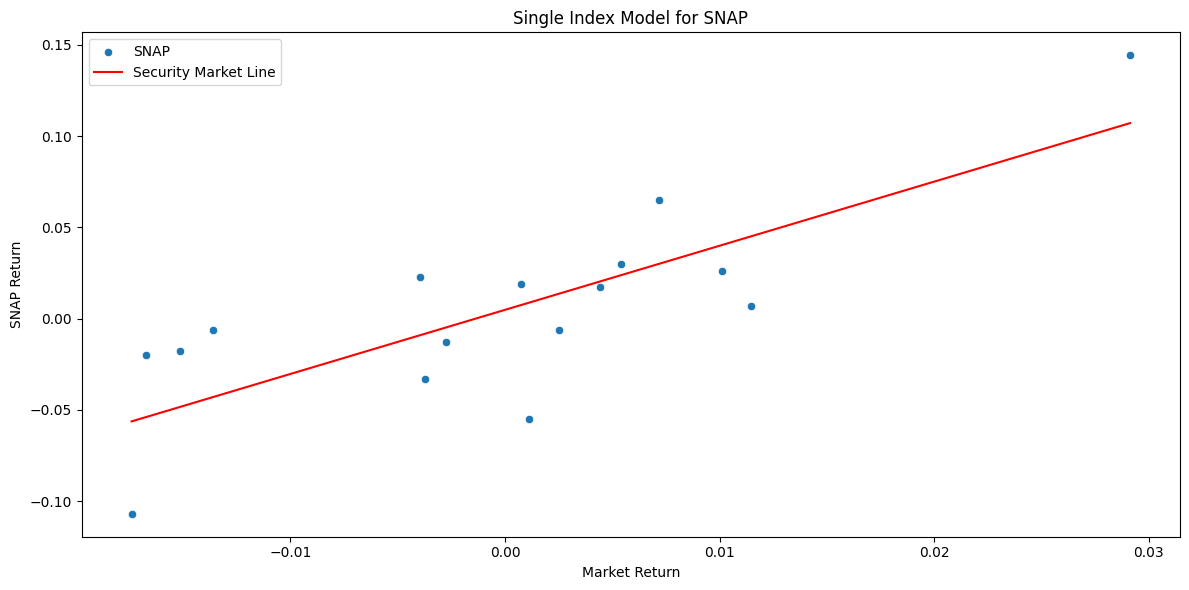

                            OLS Regression Results                            
Dep. Variable:                   MARA   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     4.958
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0429
Time:                        11:29:46   Log-Likelihood:                 29.062
No. Observations:                  16   AIC:                            -54.12
Df Residuals:                      14   BIC:                            -52.58
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.011     -0.119      0.9

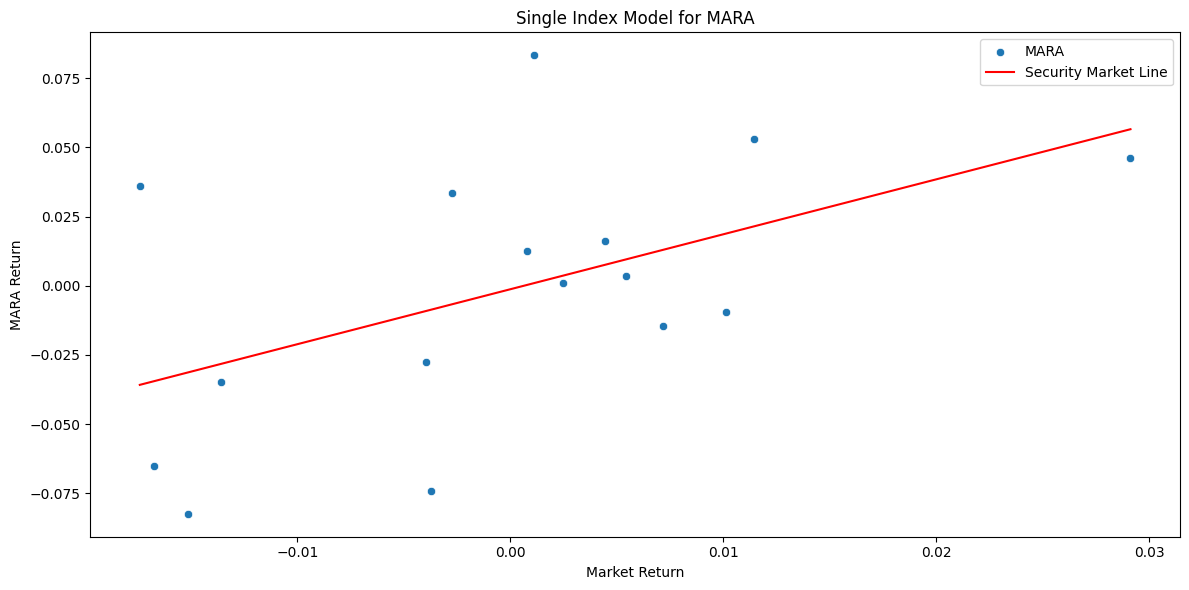

                            OLS Regression Results                            
Dep. Variable:                     NU   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     36.87
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.88e-05
Time:                        11:29:46   Log-Likelihood:                 45.508
No. Observations:                  16   AIC:                            -87.02
Df Residuals:                      14   BIC:                            -85.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.004      0.441      0.6

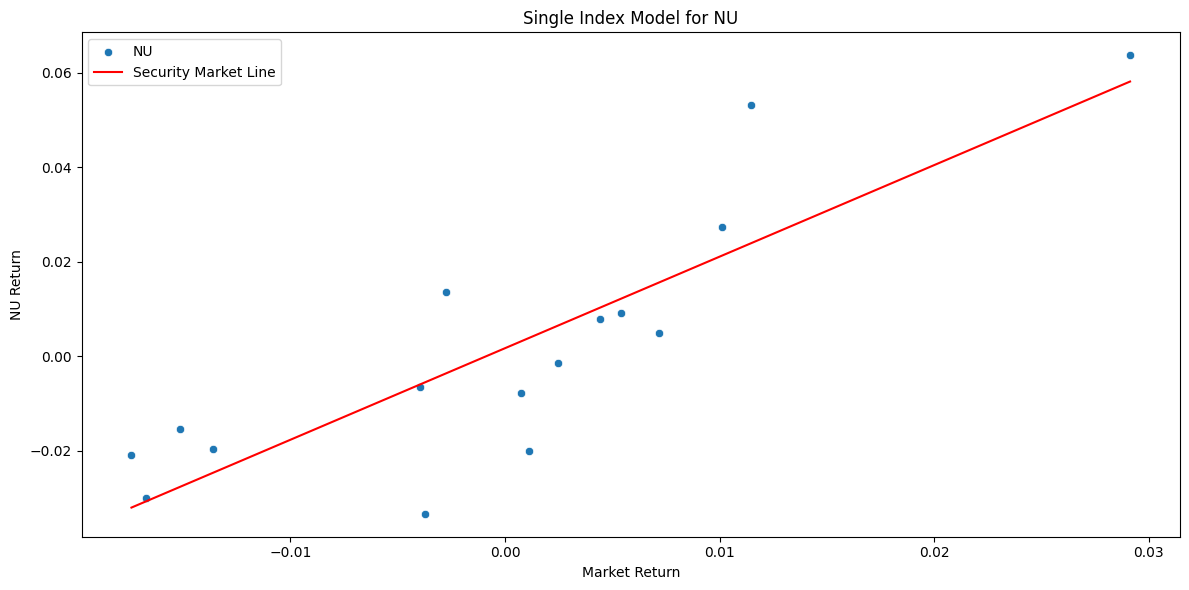

                            OLS Regression Results                            
Dep. Variable:                   WULF   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     15.10
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00165
Time:                        11:29:47   Log-Likelihood:                 29.321
No. Observations:                  16   AIC:                            -54.64
Df Residuals:                      14   BIC:                            -53.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0094      0.010      0.913      0.3

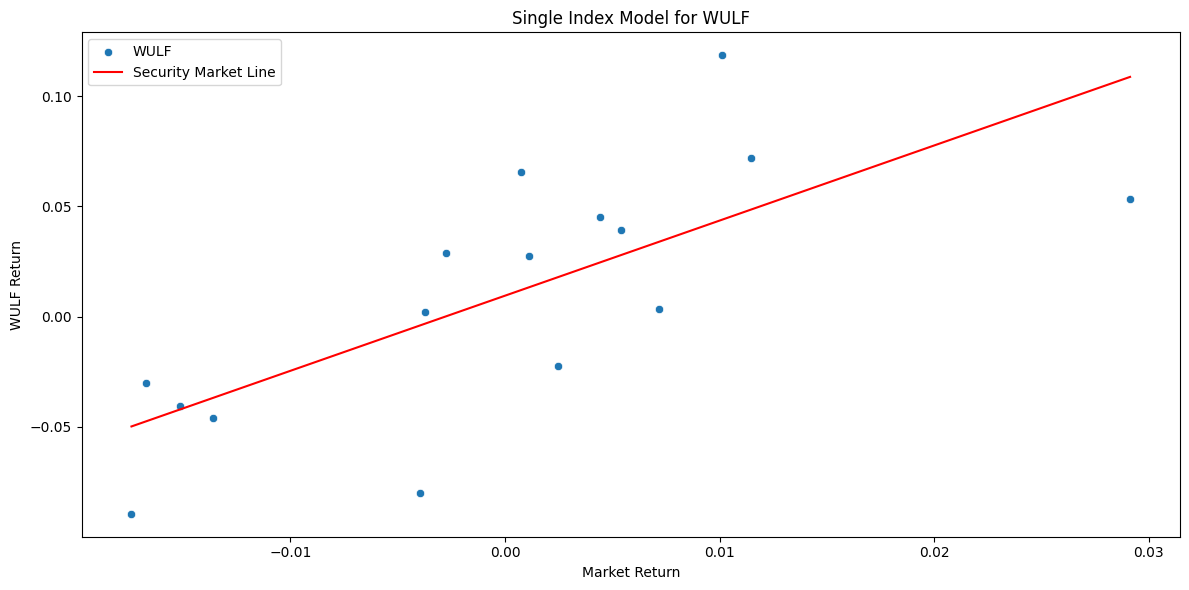

                            OLS Regression Results                            
Dep. Variable:                   SOFI   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     21.41
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000392
Time:                        11:29:47   Log-Likelihood:                 45.602
No. Observations:                  16   AIC:                            -87.20
Df Residuals:                      14   BIC:                            -85.66
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0057      0.004     -1.529      0.1

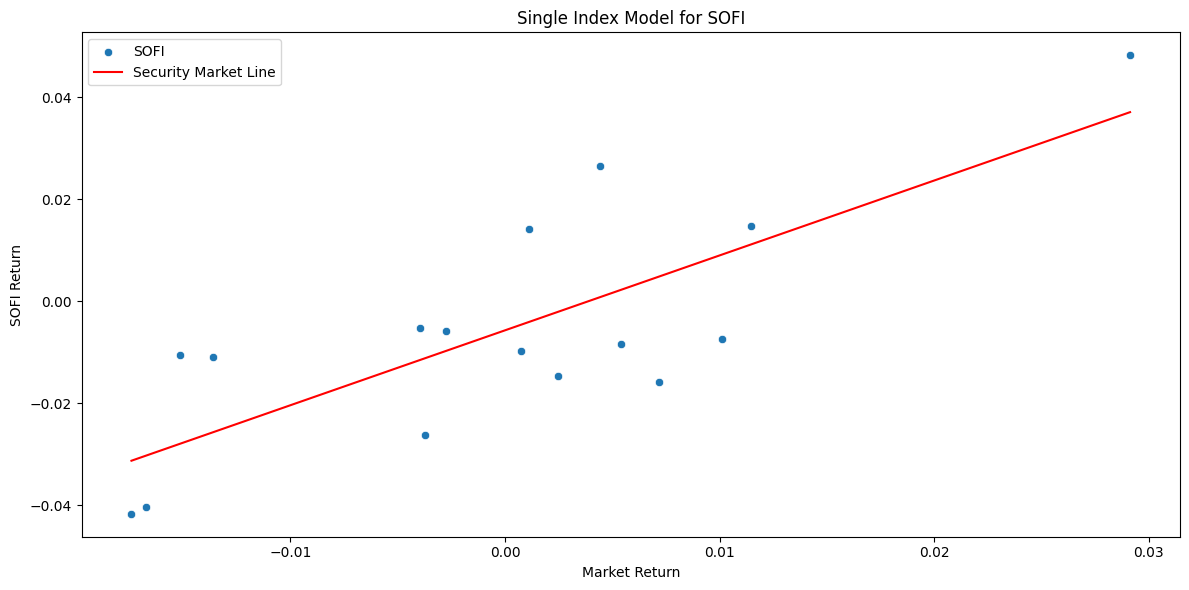

                            OLS Regression Results                            
Dep. Variable:                     MU   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     4.579
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0505
Time:                        11:29:47   Log-Likelihood:                 28.324
No. Observations:                  16   AIC:                            -52.65
Df Residuals:                      14   BIC:                            -51.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0062      0.011     -0.565      0.5

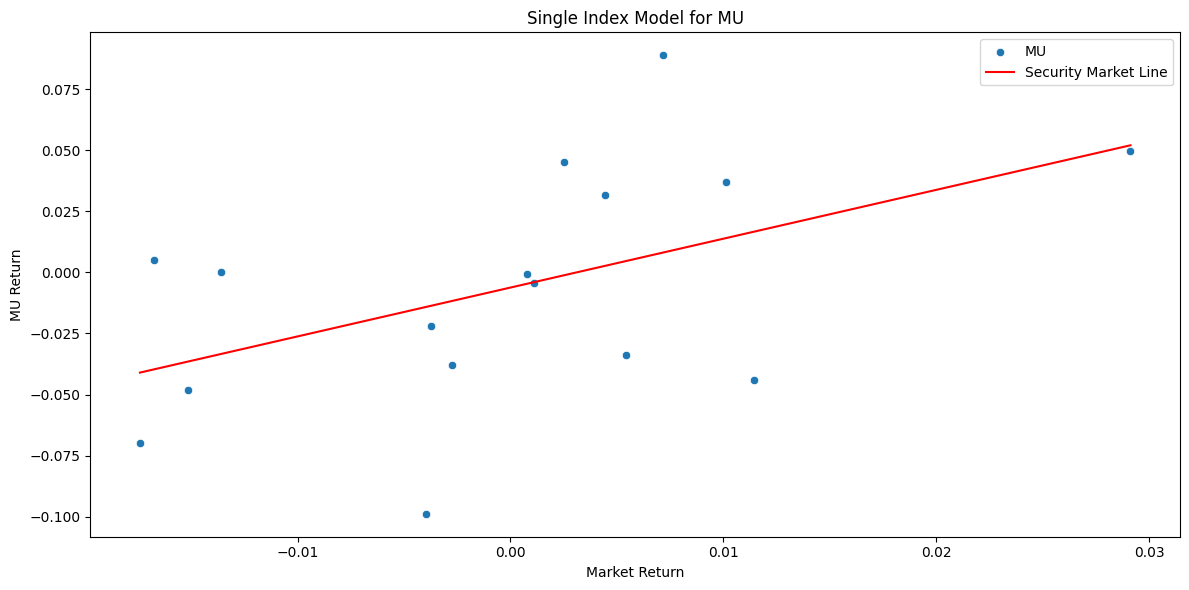

                            OLS Regression Results                            
Dep. Variable:                    BBD   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     40.78
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.69e-05
Time:                        11:29:47   Log-Likelihood:                 47.077
No. Observations:                  16   AIC:                            -90.15
Df Residuals:                      14   BIC:                            -88.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0036      0.003      1.066      0.3

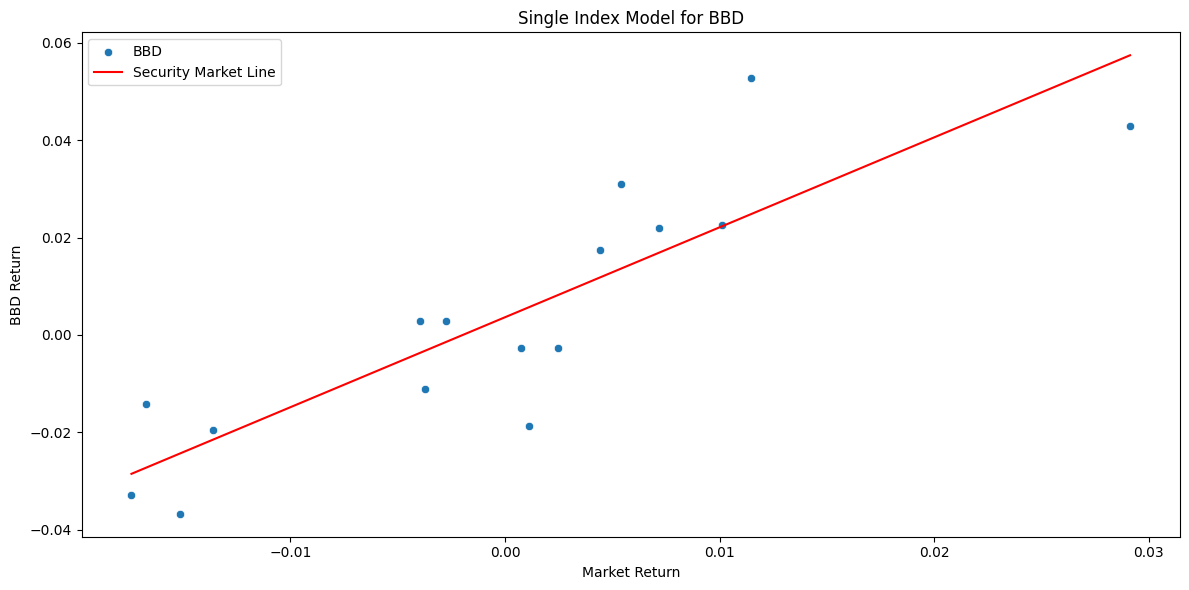

                            OLS Regression Results                            
Dep. Variable:                     VG   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     7.481
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0161
Time:                        11:29:47   Log-Likelihood:                 25.388
No. Observations:                  16   AIC:                            -46.78
Df Residuals:                      14   BIC:                            -45.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0142      0.013      1.075      0.3

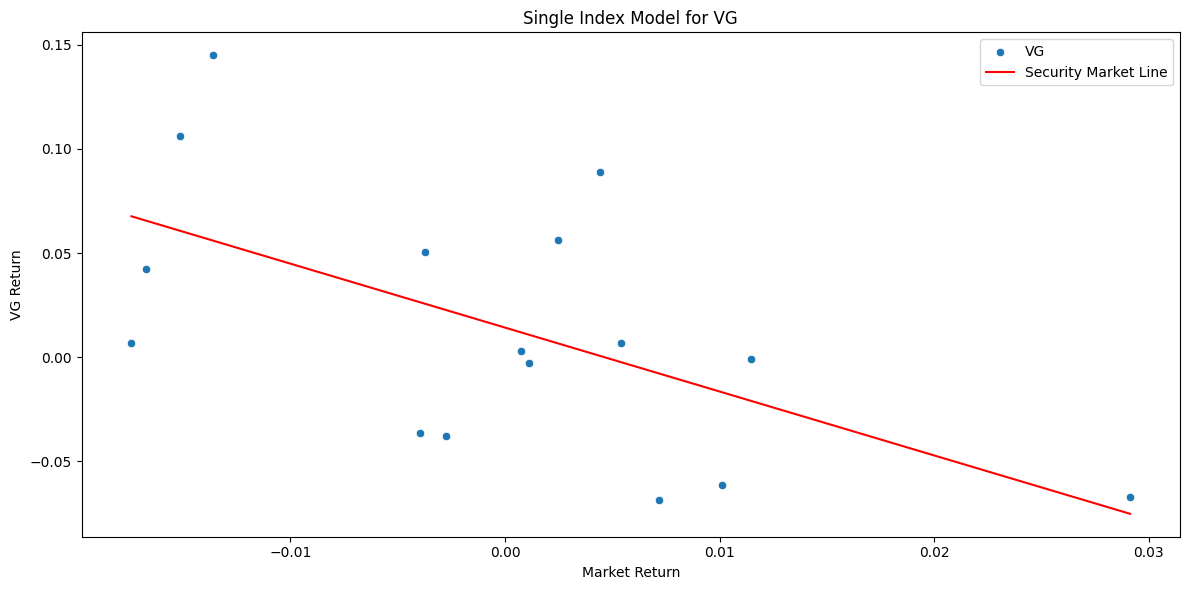

                            OLS Regression Results                            
Dep. Variable:                    NOW   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.111
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.310
Time:                        11:29:47   Log-Likelihood:                 36.978
No. Observations:                  16   AIC:                            -69.96
Df Residuals:                      14   BIC:                            -68.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0073      0.006     -1.131      0.2

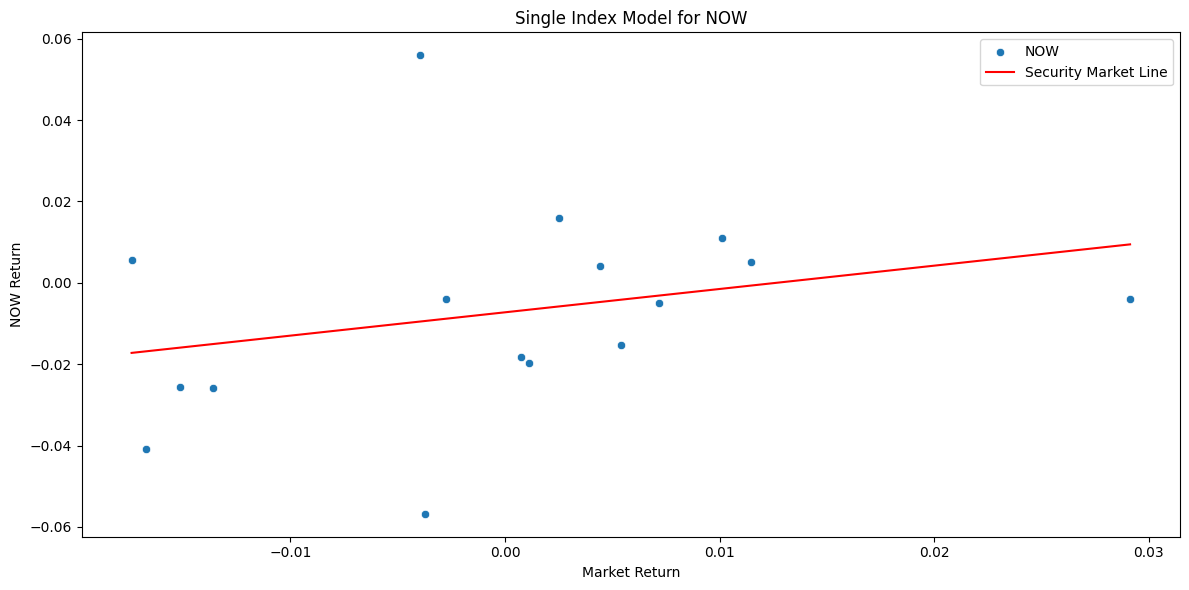

                            OLS Regression Results                            
Dep. Variable:                   ABEV   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     29.11
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           9.45e-05
Time:                        11:29:47   Log-Likelihood:                 49.482
No. Observations:                  16   AIC:                            -94.96
Df Residuals:                      14   BIC:                            -93.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.003      0.902      0.3

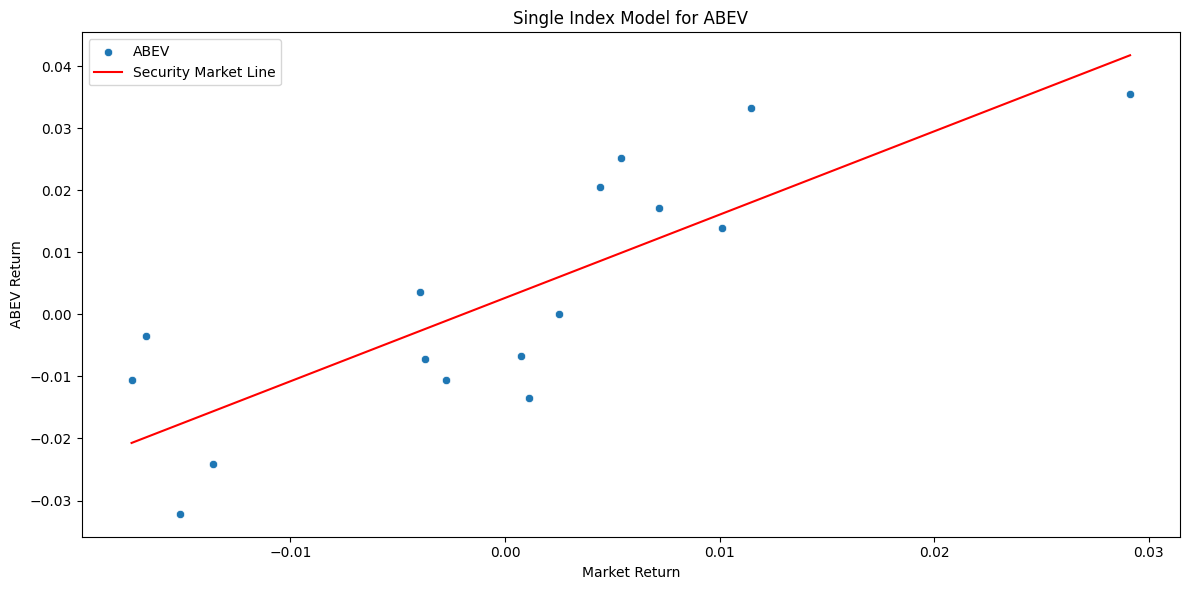

                            OLS Regression Results                            
Dep. Variable:                   ONDS   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     21.50
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000385
Time:                        11:29:48   Log-Likelihood:                 29.628
No. Observations:                  16   AIC:                            -55.26
Df Residuals:                      14   BIC:                            -53.71
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.010     -0.186      0.8

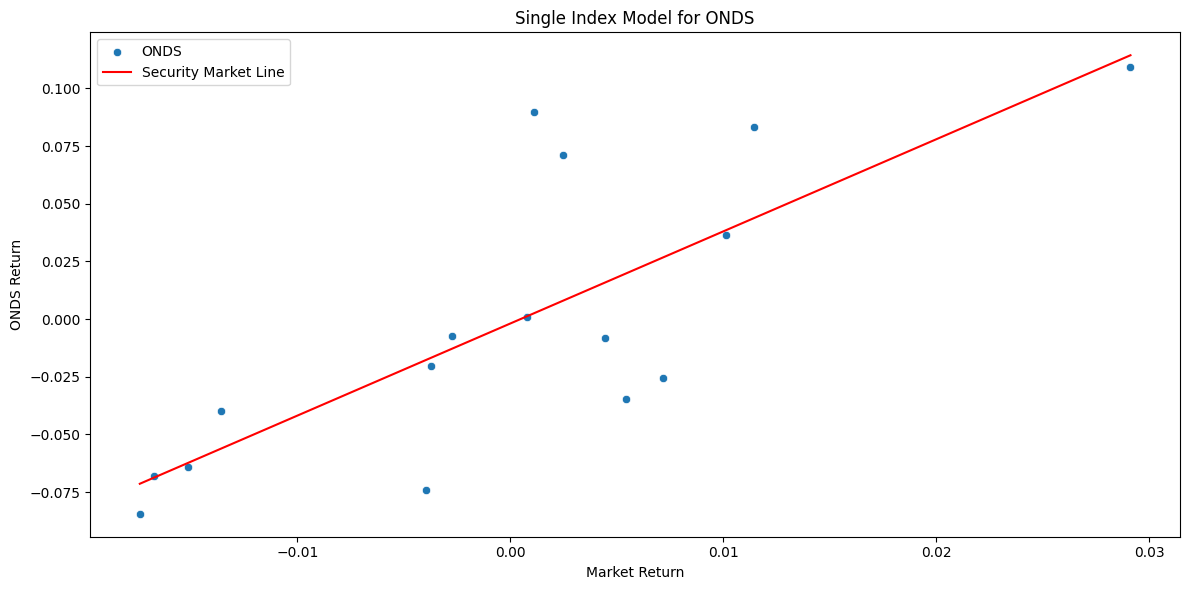

                            OLS Regression Results                            
Dep. Variable:                    AAL   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     25.32
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000183
Time:                        11:29:48   Log-Likelihood:                 43.995
No. Observations:                  16   AIC:                            -83.99
Df Residuals:                      14   BIC:                            -82.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0035      0.004      0.844      0.4

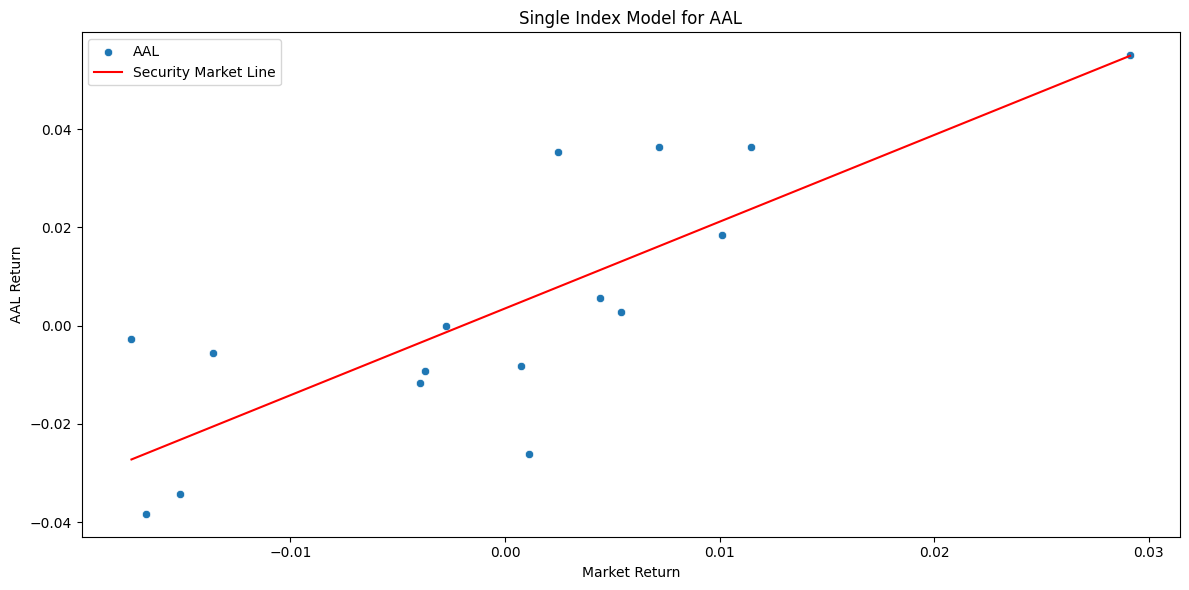

                            OLS Regression Results                            
Dep. Variable:                      T   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                  0.007446
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.932
Time:                        11:29:48   Log-Likelihood:                 49.305
No. Observations:                  16   AIC:                            -94.61
Df Residuals:                      14   BIC:                            -93.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.003      0.262      0.7

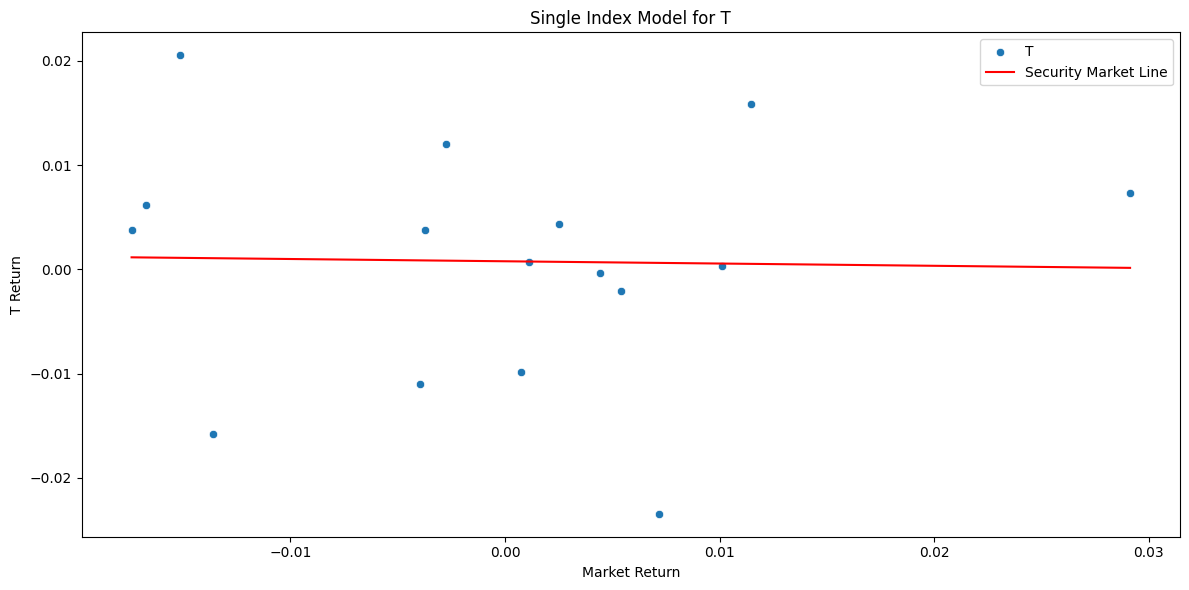

                            OLS Regression Results                            
Dep. Variable:                   APLD   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     35.17
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.67e-05
Time:                        11:29:48   Log-Likelihood:                 31.096
No. Observations:                  16   AIC:                            -58.19
Df Residuals:                      14   BIC:                            -56.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0020      0.009     -0.217      0.8

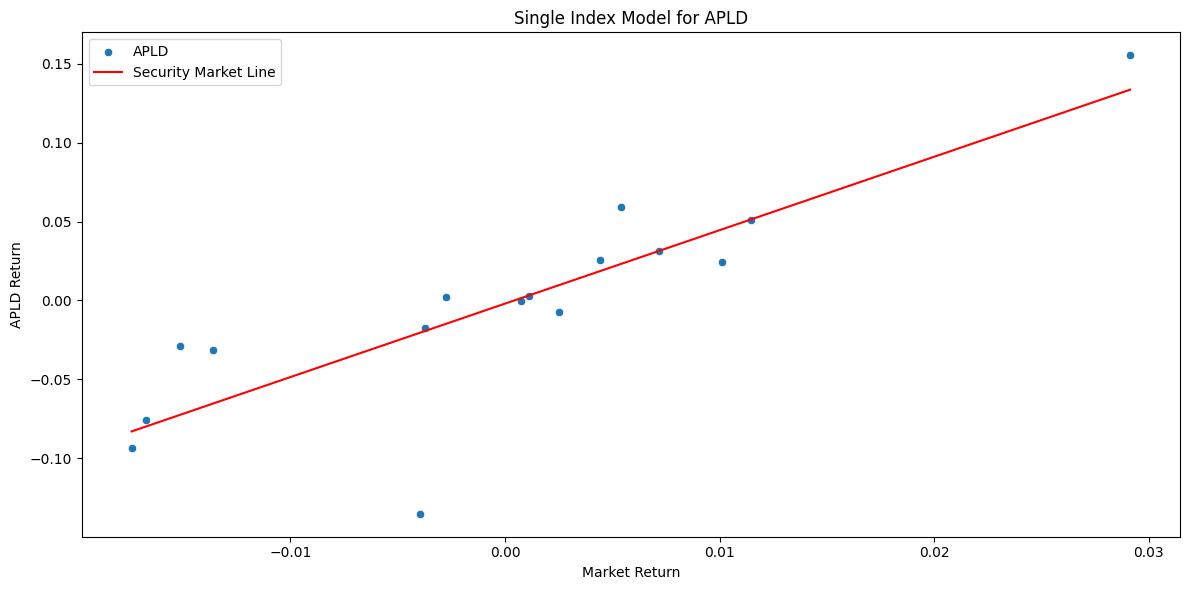

                            OLS Regression Results                            
Dep. Variable:                   BMNR   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     20.95
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000431
Time:                        11:29:48   Log-Likelihood:                 31.164
No. Observations:                  16   AIC:                            -58.33
Df Residuals:                      14   BIC:                            -56.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.009      0.063      0.9

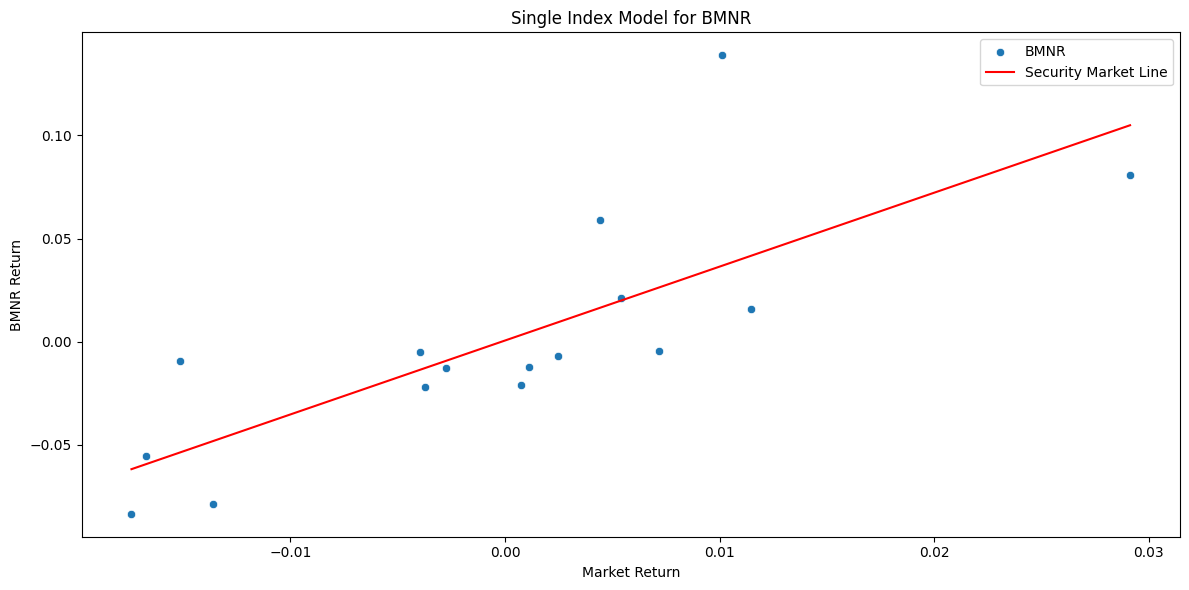

                            OLS Regression Results                            
Dep. Variable:                   PATH   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                 -0.039
Method:                 Least Squares   F-statistic:                    0.4406
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.518
Time:                        11:29:48   Log-Likelihood:                 34.077
No. Observations:                  16   AIC:                            -64.15
Df Residuals:                      14   BIC:                            -62.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0030      0.008     -0.393      0.7

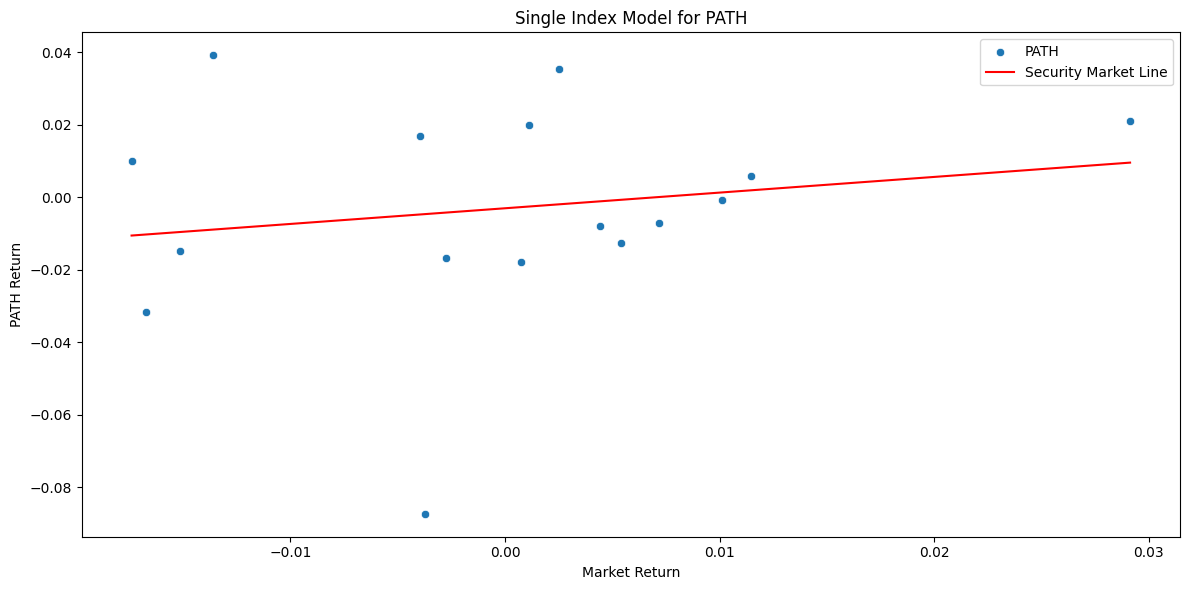

                            OLS Regression Results                            
Dep. Variable:                    RKT   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     25.58
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000175
Time:                        11:29:49   Log-Likelihood:                 39.822
No. Observations:                  16   AIC:                            -75.64
Df Residuals:                      14   BIC:                            -74.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.005      0.440      0.6

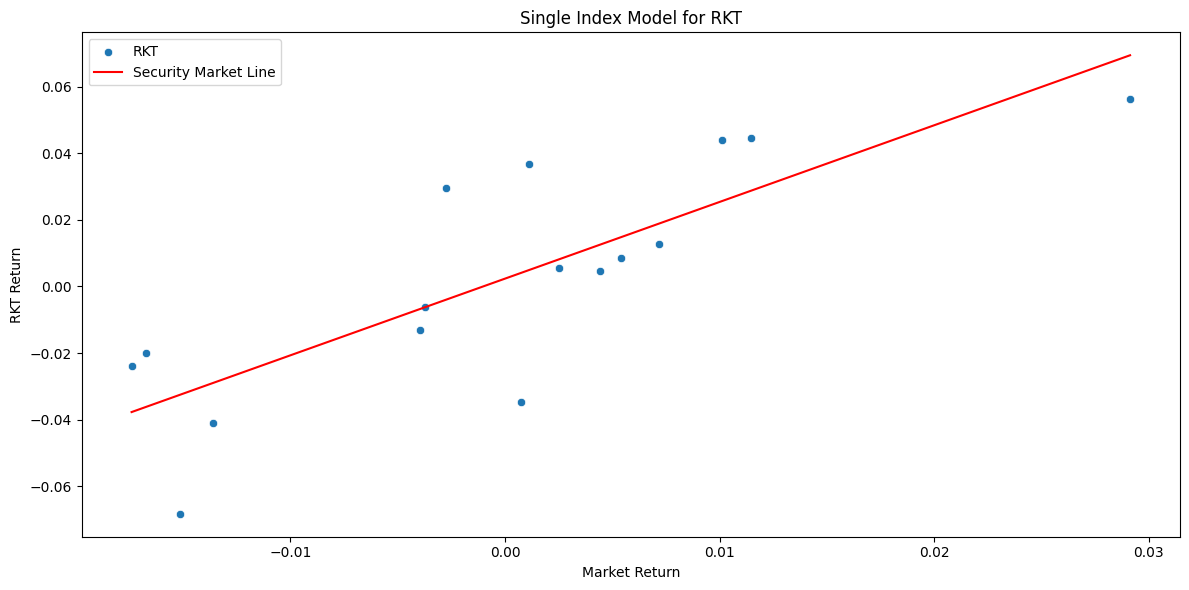

                            OLS Regression Results                            
Dep. Variable:                   NFLX   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     2.155
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.164
Time:                        11:29:49   Log-Likelihood:                 43.654
No. Observations:                  16   AIC:                            -83.31
Df Residuals:                      14   BIC:                            -81.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.004      0.579      0.5

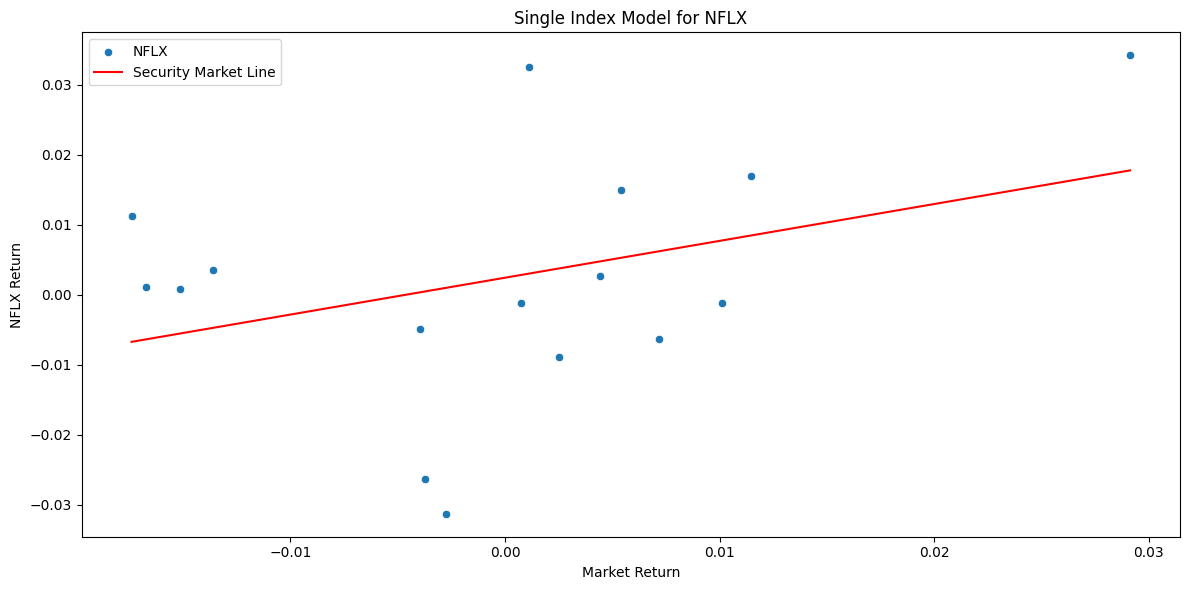

                            OLS Regression Results                            
Dep. Variable:                   OPEN   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     10.84
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00534
Time:                        11:29:49   Log-Likelihood:                 32.004
No. Observations:                  16   AIC:                            -60.01
Df Residuals:                      14   BIC:                            -58.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0041      0.009     -0.471      0.6

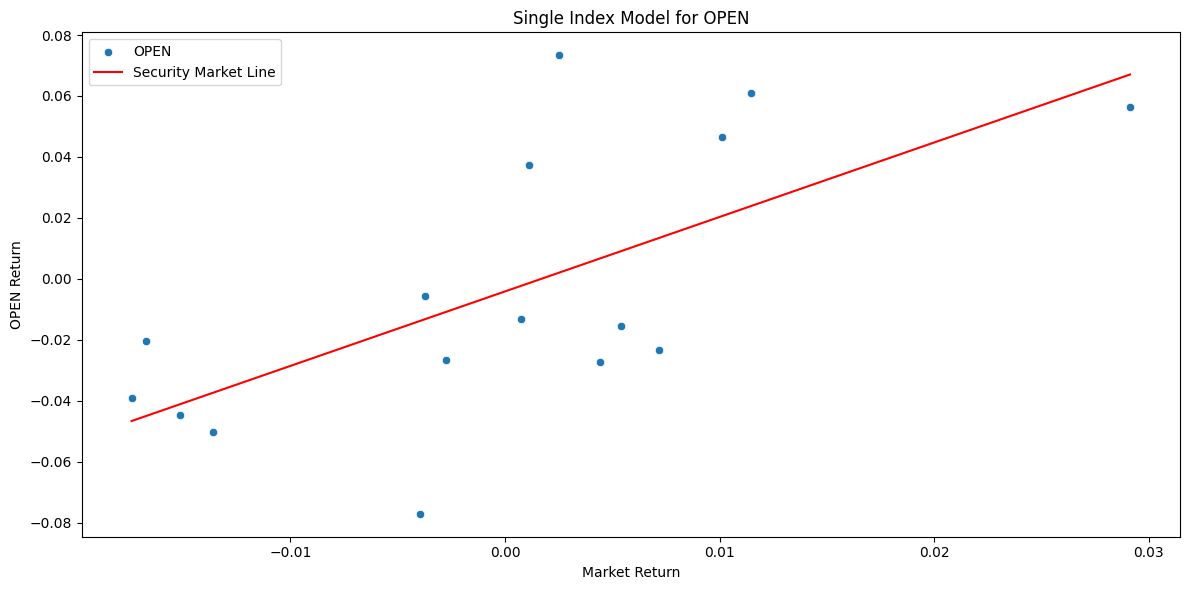

                            OLS Regression Results                            
Dep. Variable:                    PBR   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                   0.01073
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.919
Time:                        11:29:49   Log-Likelihood:                 38.660
No. Observations:                  16   AIC:                            -73.32
Df Residuals:                      14   BIC:                            -71.77
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0071      0.006      1.227      0.2

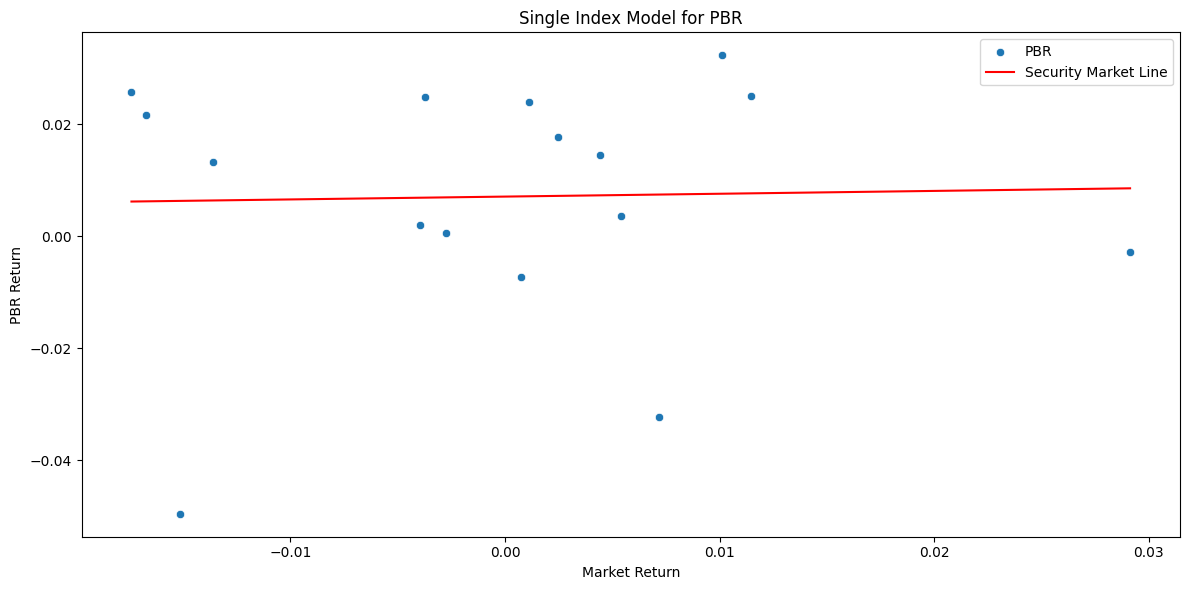

                            OLS Regression Results                            
Dep. Variable:                   SMCI   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     7.751
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0146
Time:                        11:29:49   Log-Likelihood:                 18.729
No. Observations:                  16   AIC:                            -33.46
Df Residuals:                      14   BIC:                            -31.91
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0132      0.020     -0.658      0.5

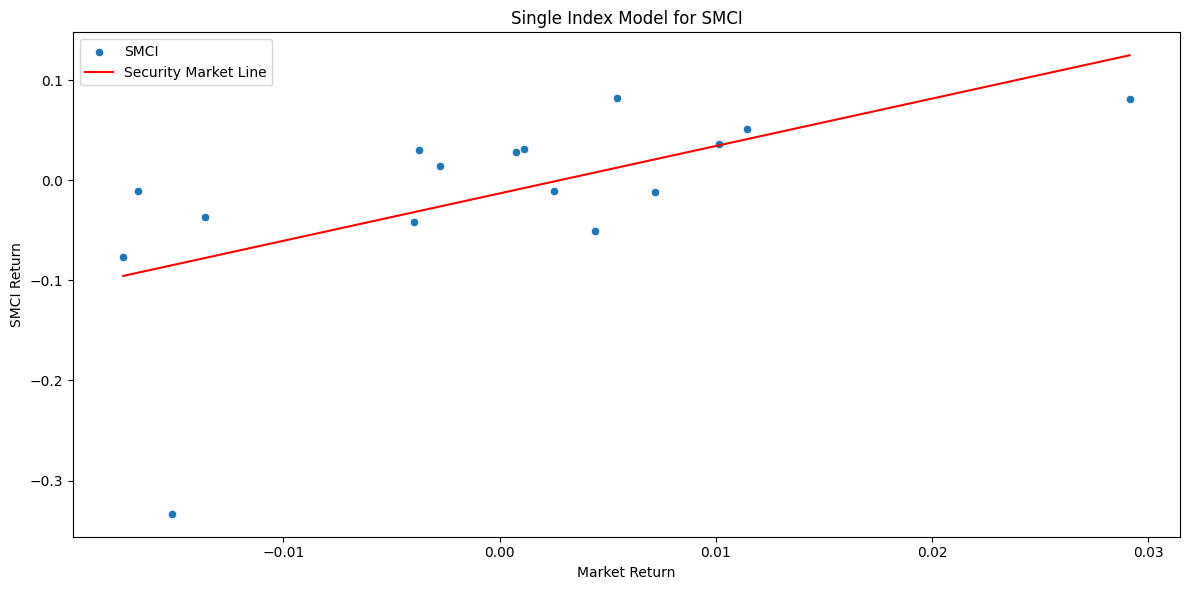

                            OLS Regression Results                            
Dep. Variable:                   CIFR   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     15.82
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00137
Time:                        11:29:49   Log-Likelihood:                 28.970
No. Observations:                  16   AIC:                            -53.94
Df Residuals:                      14   BIC:                            -52.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.011      0.158      0.8

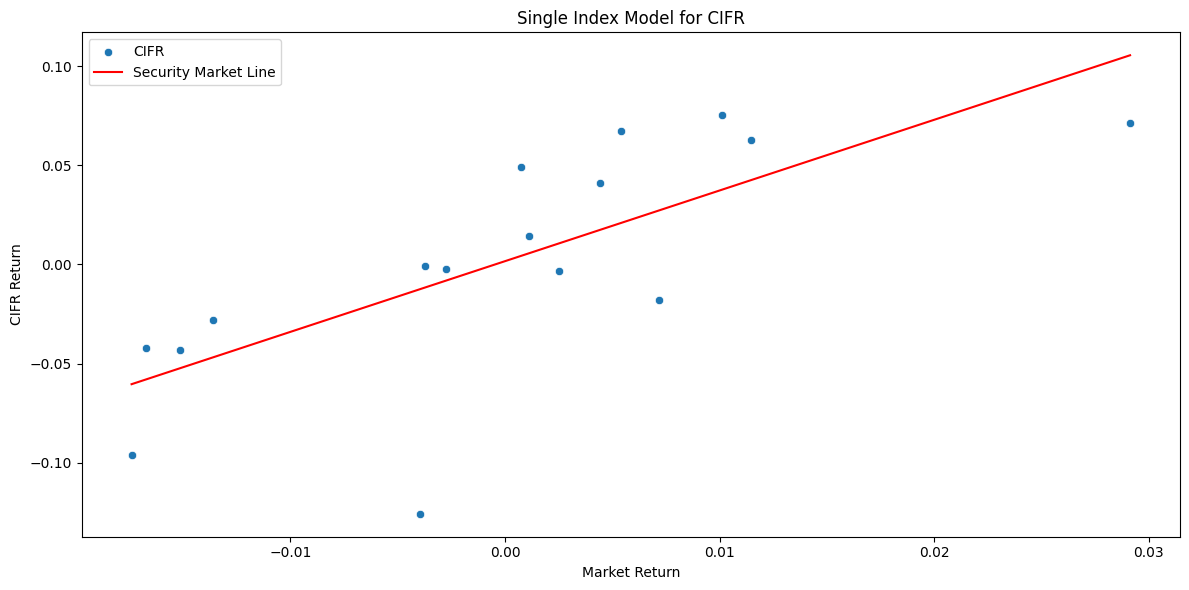

                            OLS Regression Results                            
Dep. Variable:                   MRVL   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     22.73
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000300
Time:                        11:29:49   Log-Likelihood:                 33.951
No. Observations:                  16   AIC:                            -63.90
Df Residuals:                      14   BIC:                            -62.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0151      0.008      1.948      0.0

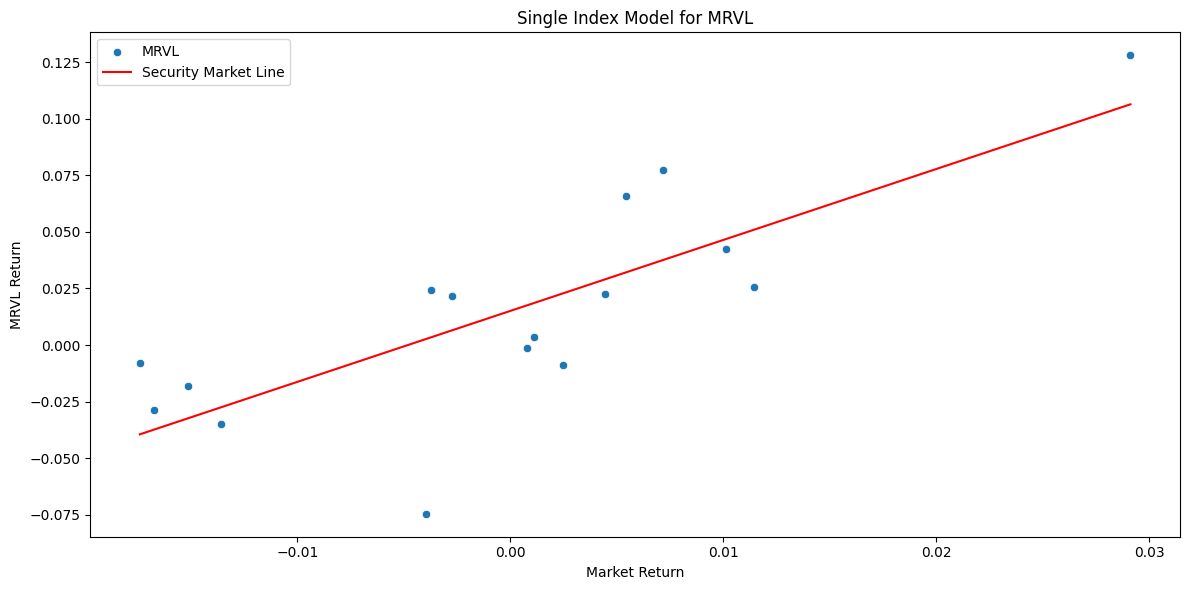

                            OLS Regression Results                            
Dep. Variable:                      F   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     17.58
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000903
Time:                        11:29:50   Log-Likelihood:                 51.817
No. Observations:                  16   AIC:                            -99.63
Df Residuals:                      14   BIC:                            -98.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.003     -0.252      0.8

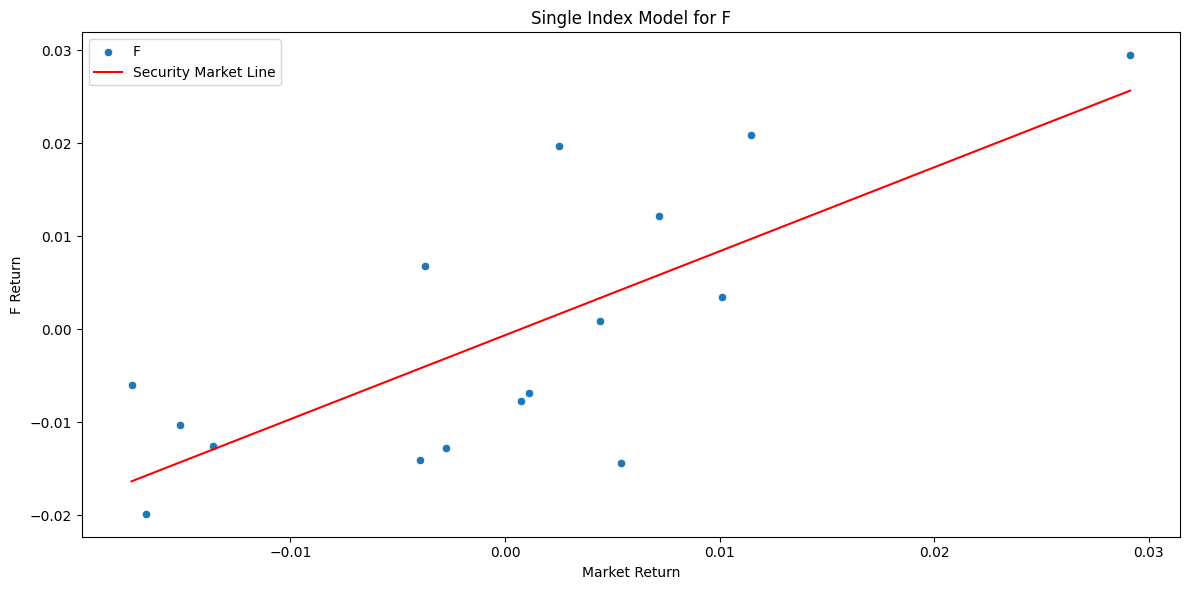

                            OLS Regression Results                            
Dep. Variable:                   ORCL   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     19.90
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000538
Time:                        11:29:50   Log-Likelihood:                 43.451
No. Observations:                  16   AIC:                            -82.90
Df Residuals:                      14   BIC:                            -81.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0046      0.004     -1.067      0.3

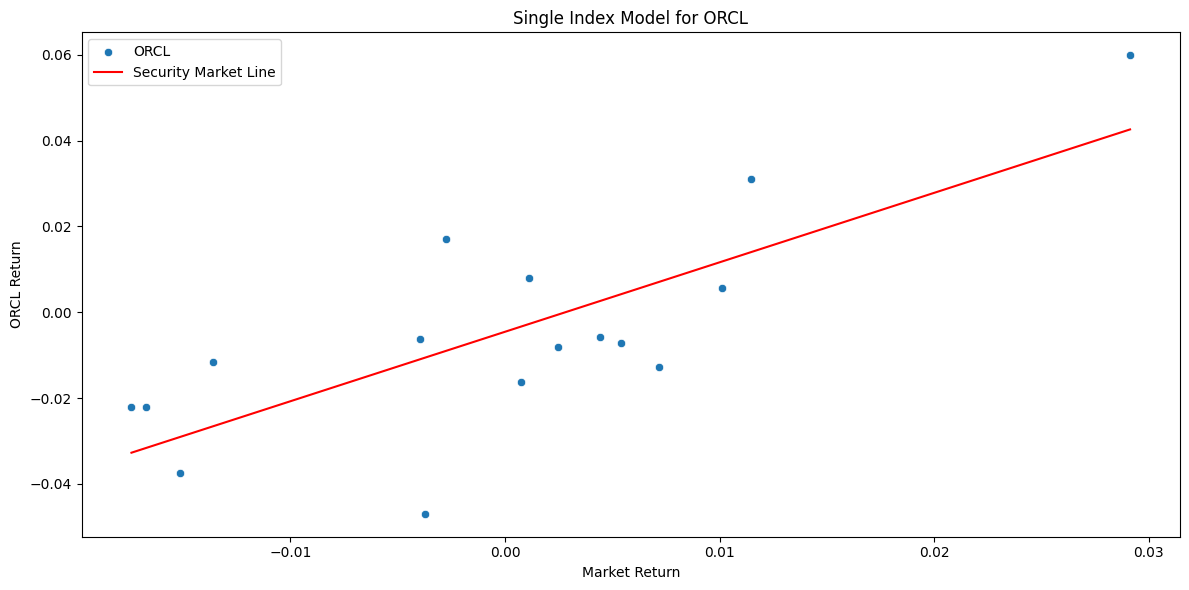

                            OLS Regression Results                            
Dep. Variable:                    GGB   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     23.73
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000247
Time:                        11:29:50   Log-Likelihood:                 47.373
No. Observations:                  16   AIC:                            -90.75
Df Residuals:                      14   BIC:                            -89.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0090      0.003      2.688      0.0

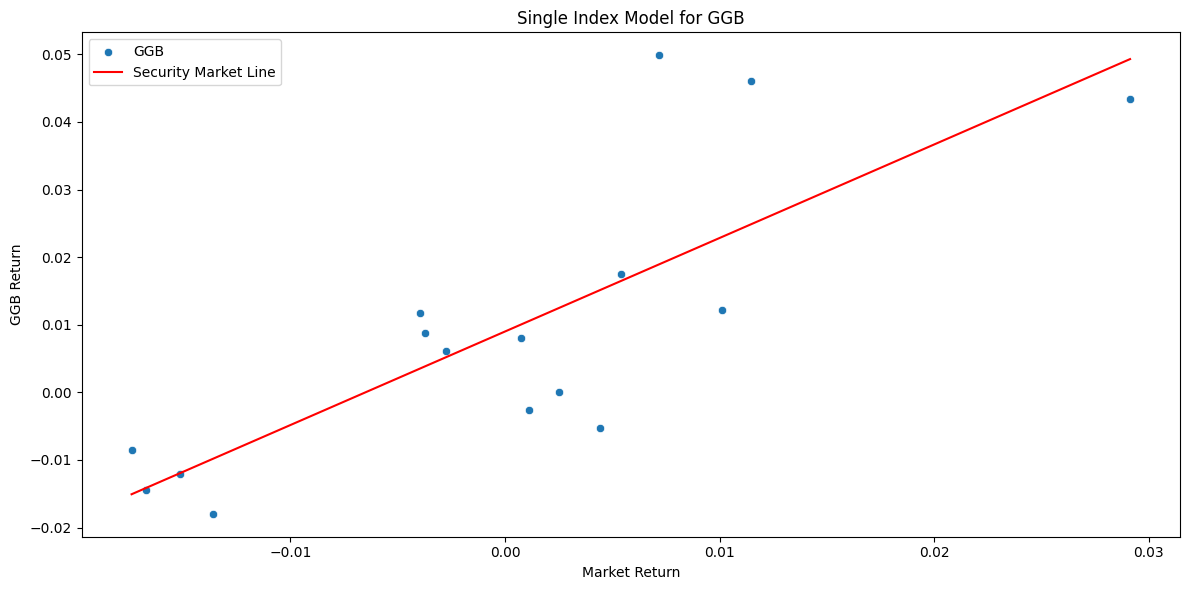

                            OLS Regression Results                            
Dep. Variable:                    AMD   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     7.632
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0153
Time:                        11:29:50   Log-Likelihood:                 35.841
No. Observations:                  16   AIC:                            -67.68
Df Residuals:                      14   BIC:                            -66.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0092      0.007      1.331      0.2

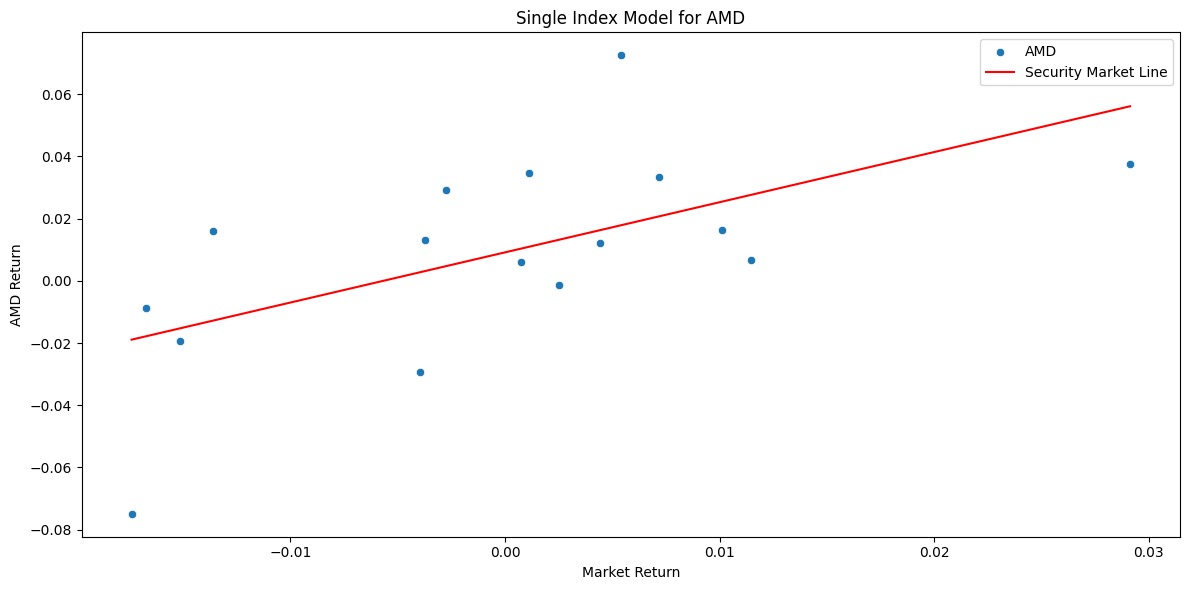

                            OLS Regression Results                            
Dep. Variable:                   STLA   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     25.33
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000183
Time:                        11:29:50   Log-Likelihood:                 45.100
No. Observations:                  16   AIC:                            -86.20
Df Residuals:                      14   BIC:                            -84.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.004      2.260      0.0

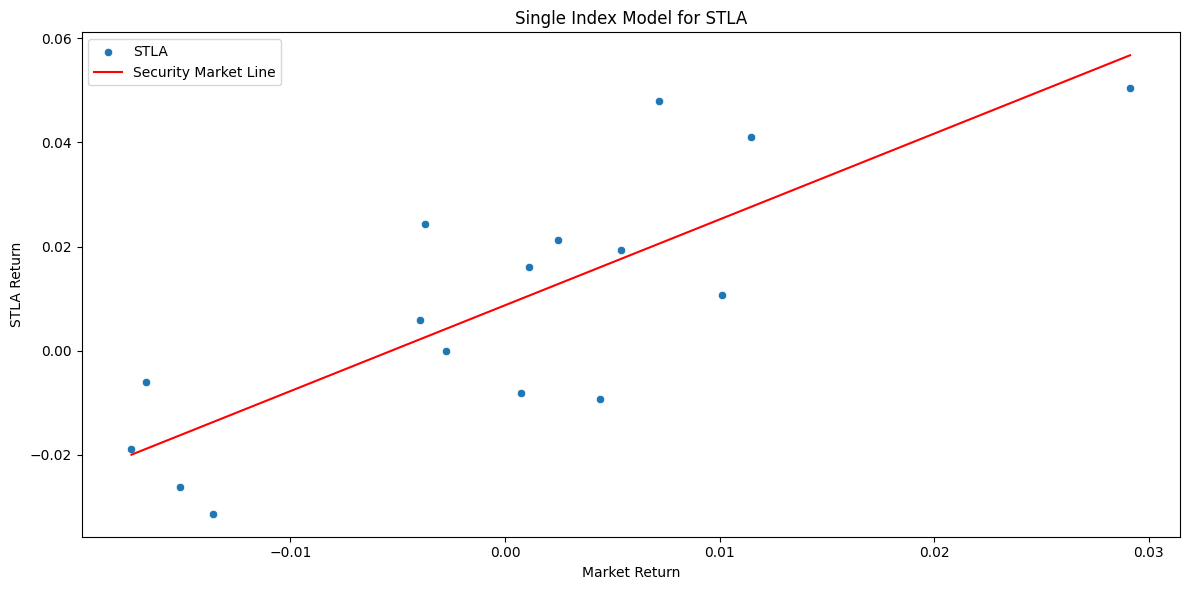

                            OLS Regression Results                            
Dep. Variable:                   IREN   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     18.21
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000782
Time:                        11:29:50   Log-Likelihood:                 31.901
No. Observations:                  16   AIC:                            -59.80
Df Residuals:                      14   BIC:                            -58.26
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0079      0.009     -0.898      0.3

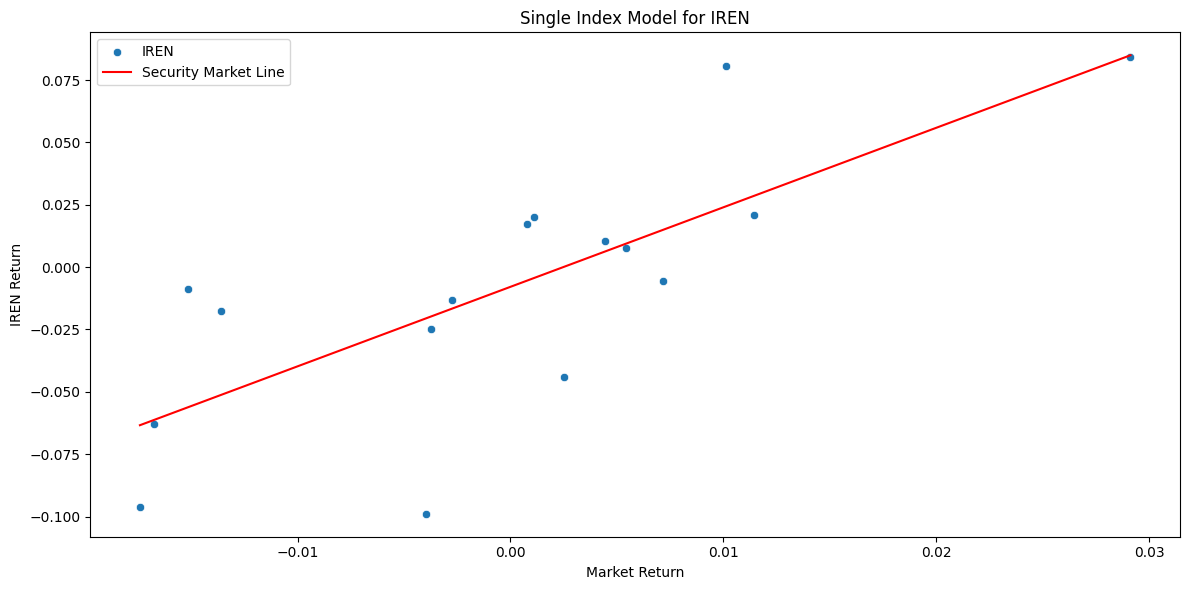

                            OLS Regression Results                            
Dep. Variable:                   MSFT   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     33.89
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           4.43e-05
Time:                        11:29:51   Log-Likelihood:                 54.854
No. Observations:                  16   AIC:                            -105.7
Df Residuals:                      14   BIC:                            -104.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0036      0.002     -1.715      0.1

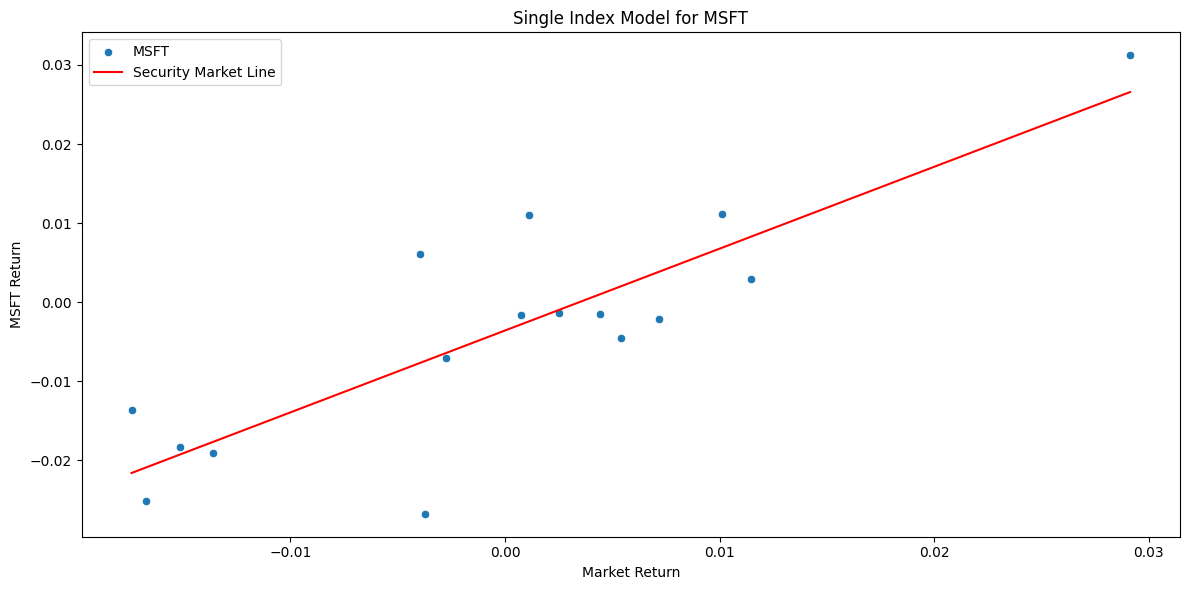

                            OLS Regression Results                            
Dep. Variable:                     VZ   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.064
Method:                 Least Squares   F-statistic:                   0.09654
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.761
Time:                        11:29:51   Log-Likelihood:                 53.118
No. Observations:                  16   AIC:                            -102.2
Df Residuals:                      14   BIC:                            -100.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0034      0.002     -1.459      0.1

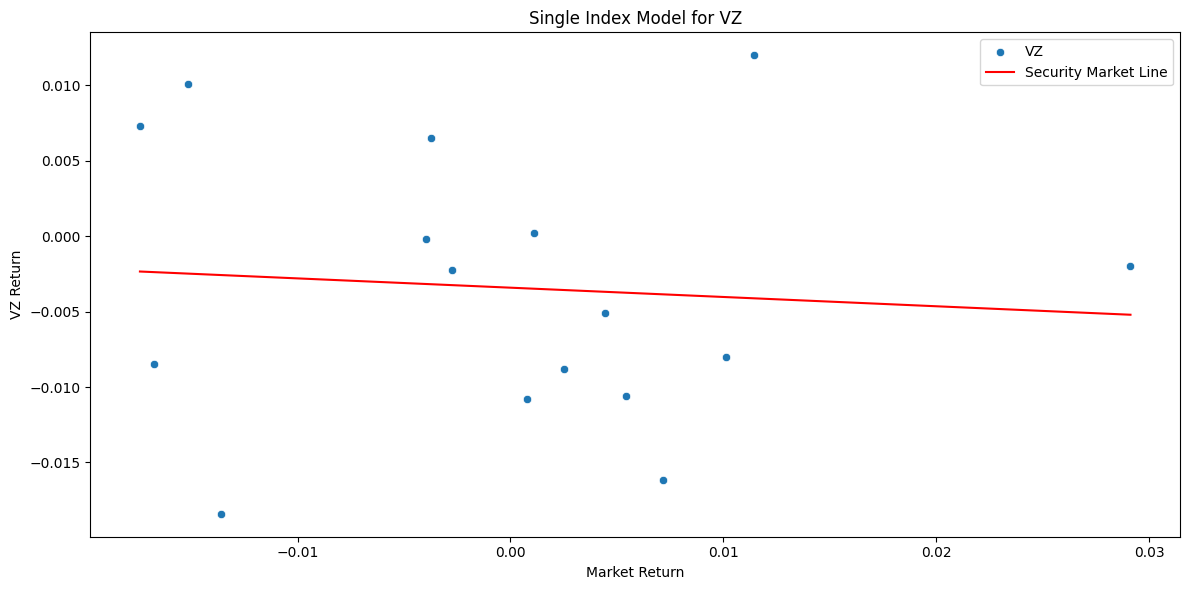

                            OLS Regression Results                            
Dep. Variable:                   FSLY   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     4.681
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0483
Time:                        11:29:51   Log-Likelihood:                 21.334
No. Observations:                  16   AIC:                            -38.67
Df Residuals:                      14   BIC:                            -37.12
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0187      0.017      1.096      0.2

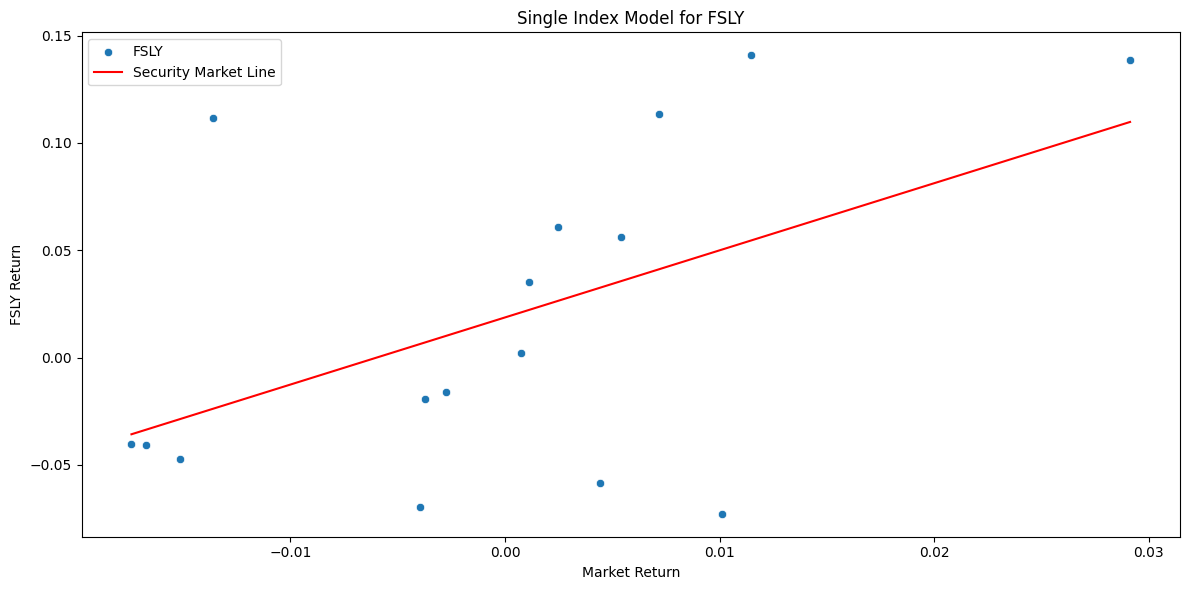

                            OLS Regression Results                            
Dep. Variable:                  GOOGL   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     30.78
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           7.18e-05
Time:                        11:29:51   Log-Likelihood:                 46.888
No. Observations:                  16   AIC:                            -89.78
Df Residuals:                      14   BIC:                            -88.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.003      0.302      0.7

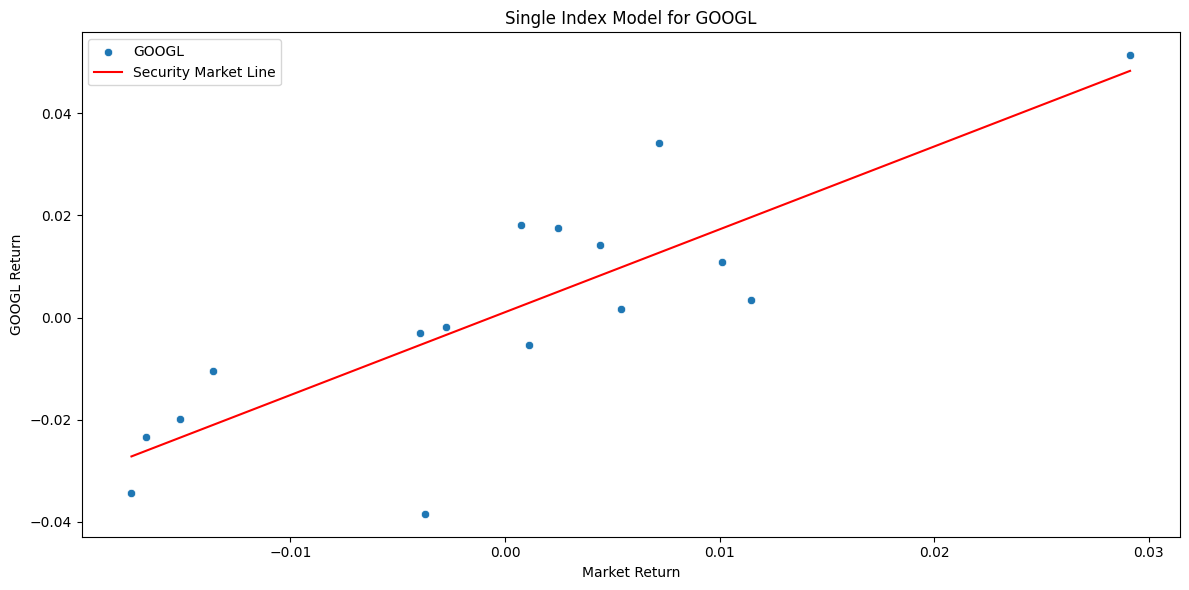

                            OLS Regression Results                            
Dep. Variable:                    CCL   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     34.92
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.81e-05
Time:                        11:29:51   Log-Likelihood:                 41.075
No. Observations:                  16   AIC:                            -78.15
Df Residuals:                      14   BIC:                            -76.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0039      0.005      0.778      0.4

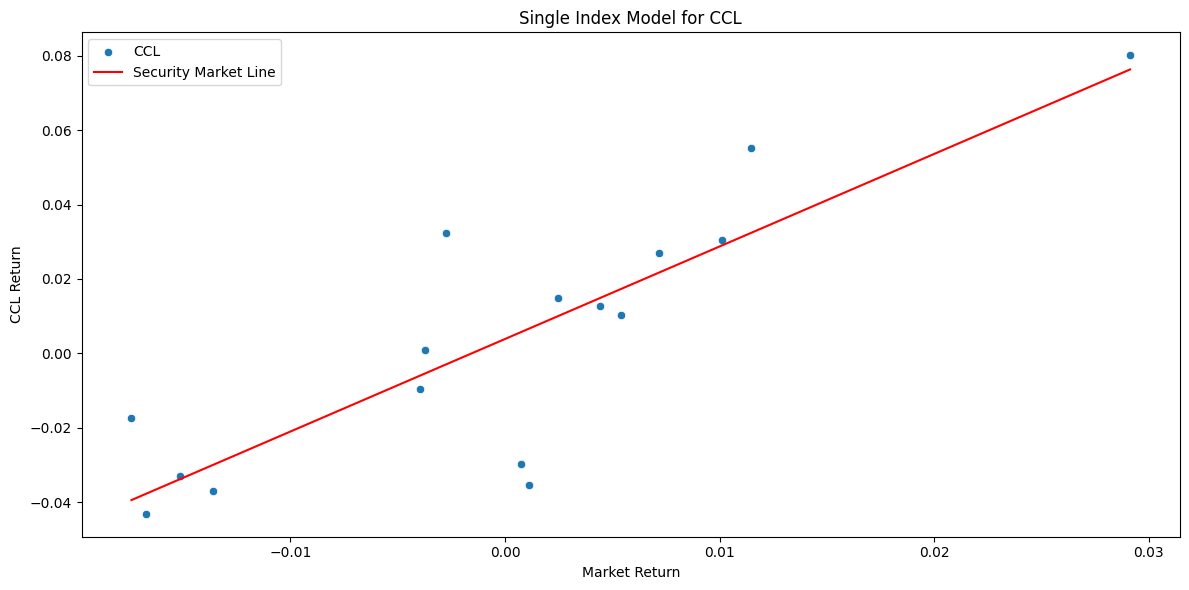

                            OLS Regression Results                            
Dep. Variable:                   HOOD   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     48.28
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           6.78e-06
Time:                        11:29:51   Log-Likelihood:                 43.088
No. Observations:                  16   AIC:                            -82.18
Df Residuals:                      14   BIC:                            -80.63
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0025      0.004     -0.565      0.5

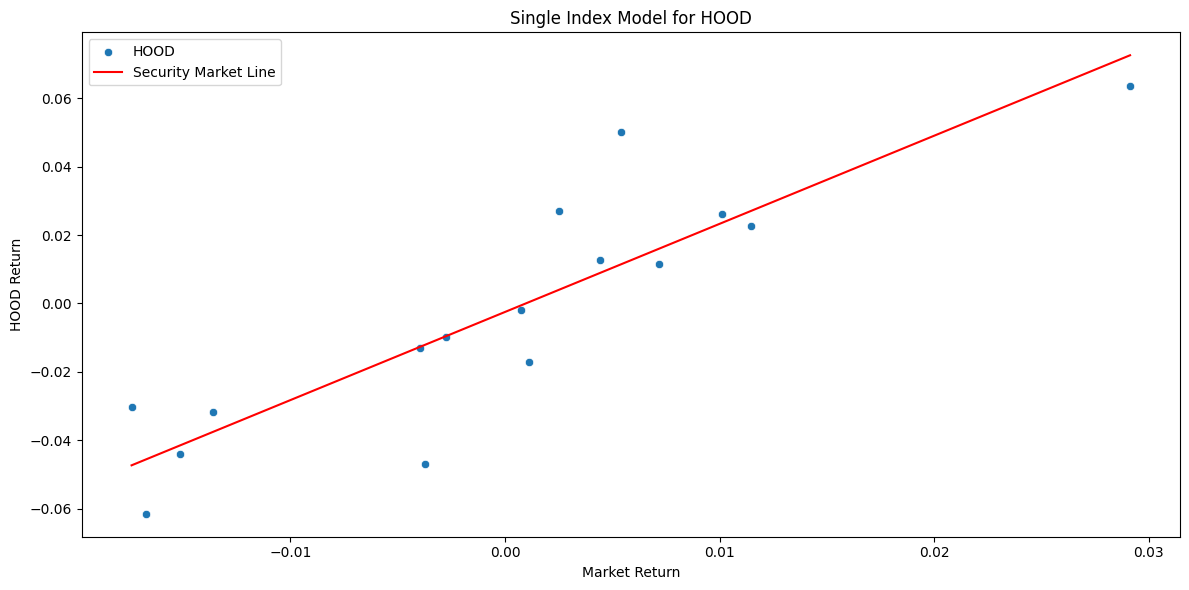

                            OLS Regression Results                            
Dep. Variable:                     BB   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     12.43
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00336
Time:                        11:29:52   Log-Likelihood:                 43.312
No. Observations:                  16   AIC:                            -82.62
Df Residuals:                      14   BIC:                            -81.08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0029      0.004      0.675      0.5

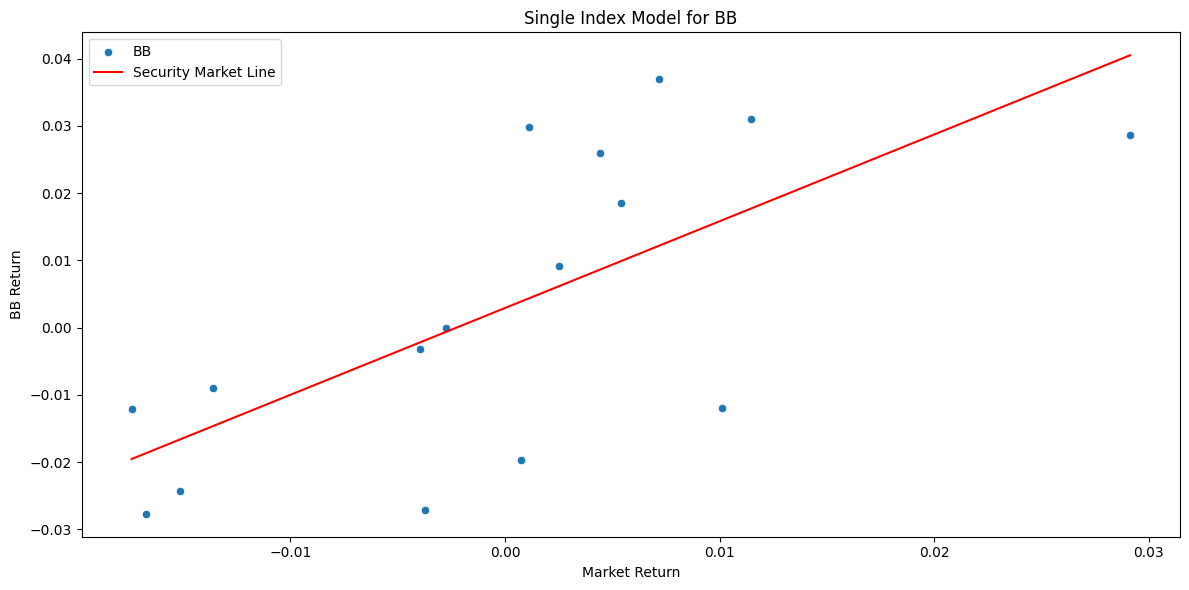

                            OLS Regression Results                            
Dep. Variable:                    NKE   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.049
Method:                 Least Squares   F-statistic:                    0.3061
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.589
Time:                        11:29:52   Log-Likelihood:                 29.027
No. Observations:                  16   AIC:                            -54.05
Df Residuals:                      14   BIC:                            -52.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0137      0.011     -1.295      0.2

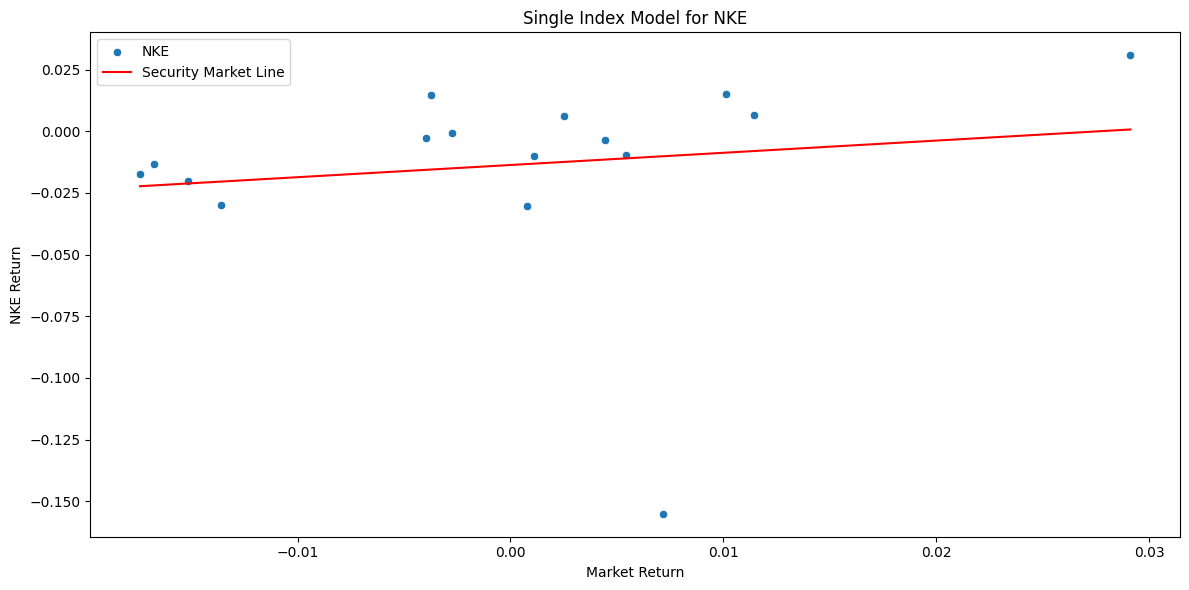

                            OLS Regression Results                            
Dep. Variable:                     ET   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     7.089
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0186
Time:                        11:29:52   Log-Likelihood:                 55.886
No. Observations:                  16   AIC:                            -107.8
Df Residuals:                      14   BIC:                            -106.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.002      0.625      0.5

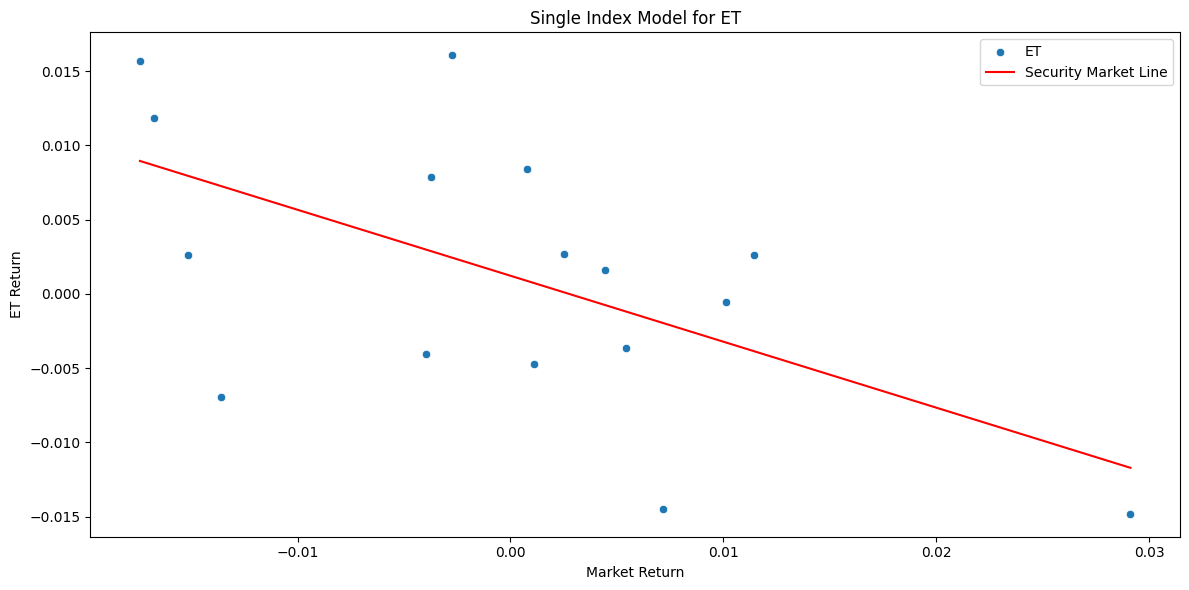

                            OLS Regression Results                            
Dep. Variable:                   META   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     43.43
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.21e-05
Time:                        11:29:52   Log-Likelihood:                 44.435
No. Observations:                  16   AIC:                            -84.87
Df Residuals:                      14   BIC:                            -83.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0034      0.004     -0.837      0.4

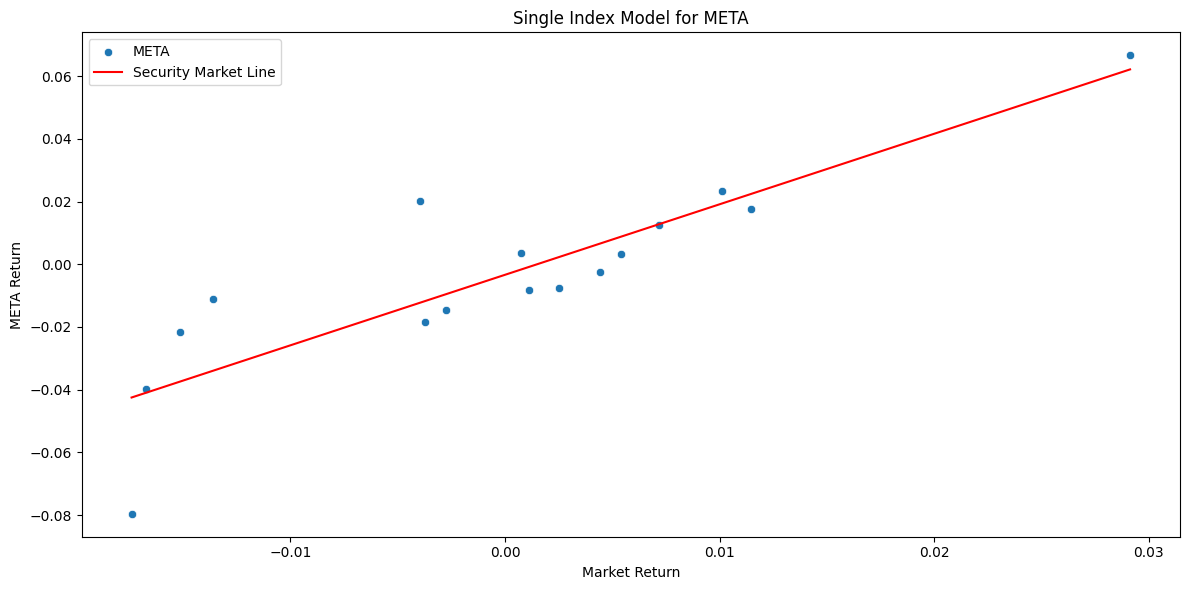

                            OLS Regression Results                            
Dep. Variable:                    MCD   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     4.216
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0592
Time:                        11:29:52   Log-Likelihood:                 51.027
No. Observations:                  16   AIC:                            -98.05
Df Residuals:                      14   BIC:                            -96.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0042      0.003     -1.565      0.1

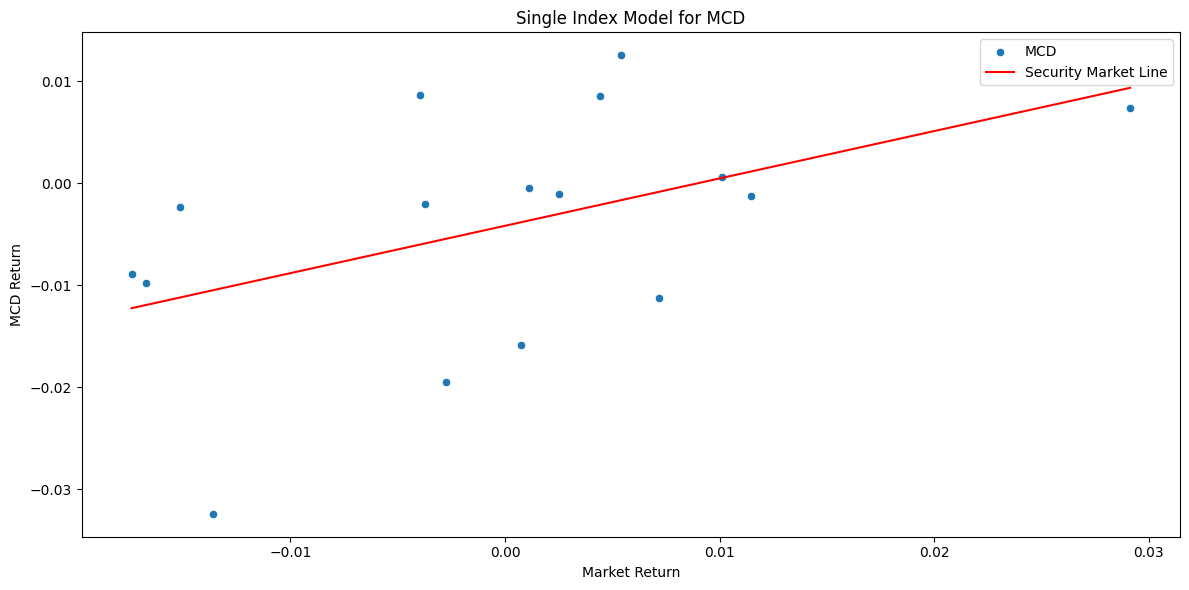

                            OLS Regression Results                            
Dep. Variable:                    TGT   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.089
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.314
Time:                        11:29:53   Log-Likelihood:                 48.026
No. Observations:                  16   AIC:                            -92.05
Df Residuals:                      14   BIC:                            -90.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.003      0.389      0.7

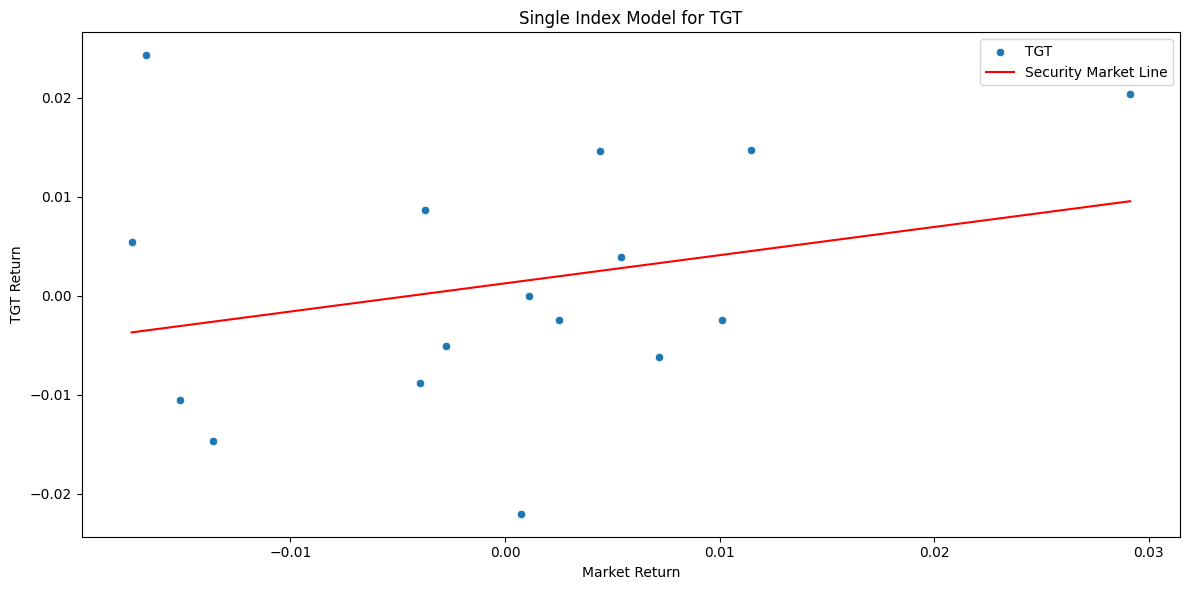

                            OLS Regression Results                            
Dep. Variable:                    WMT   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     2.286
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.153
Time:                        11:29:53   Log-Likelihood:                 47.846
No. Observations:                  16   AIC:                            -91.69
Df Residuals:                      14   BIC:                            -90.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0018      0.003     -0.546      0.5

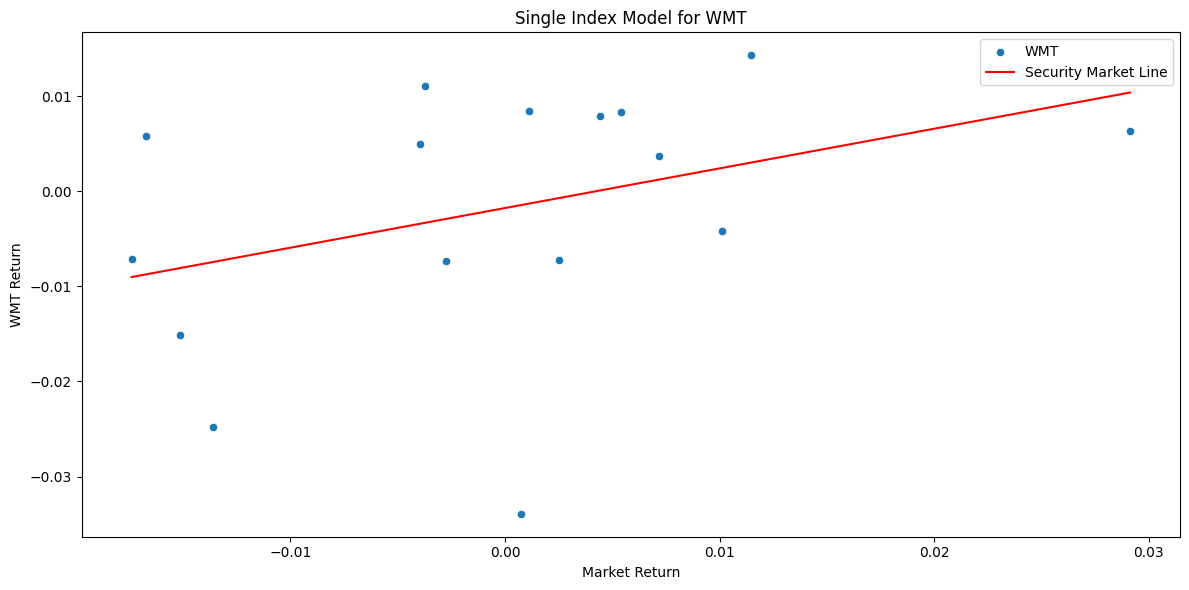

                            OLS Regression Results                            
Dep. Variable:                   ZCSH   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     22.02
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000346
Time:                        11:29:53   Log-Likelihood:                 24.937
No. Observations:                  16   AIC:                            -45.87
Df Residuals:                      14   BIC:                            -44.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0202      0.014      1.484      0.1

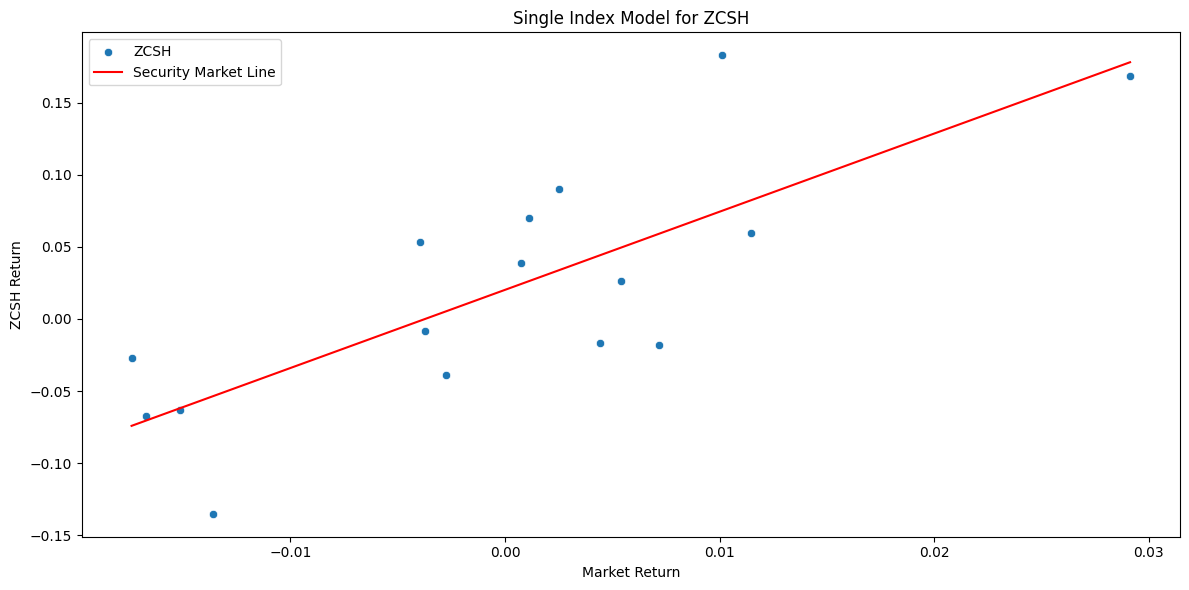

                            OLS Regression Results                            
Dep. Variable:                    BEG   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     8.348
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0119
Time:                        11:29:53   Log-Likelihood:                 14.481
No. Observations:                  16   AIC:                            -24.96
Df Residuals:                      14   BIC:                            -23.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0122      0.026     -0.468      0.6

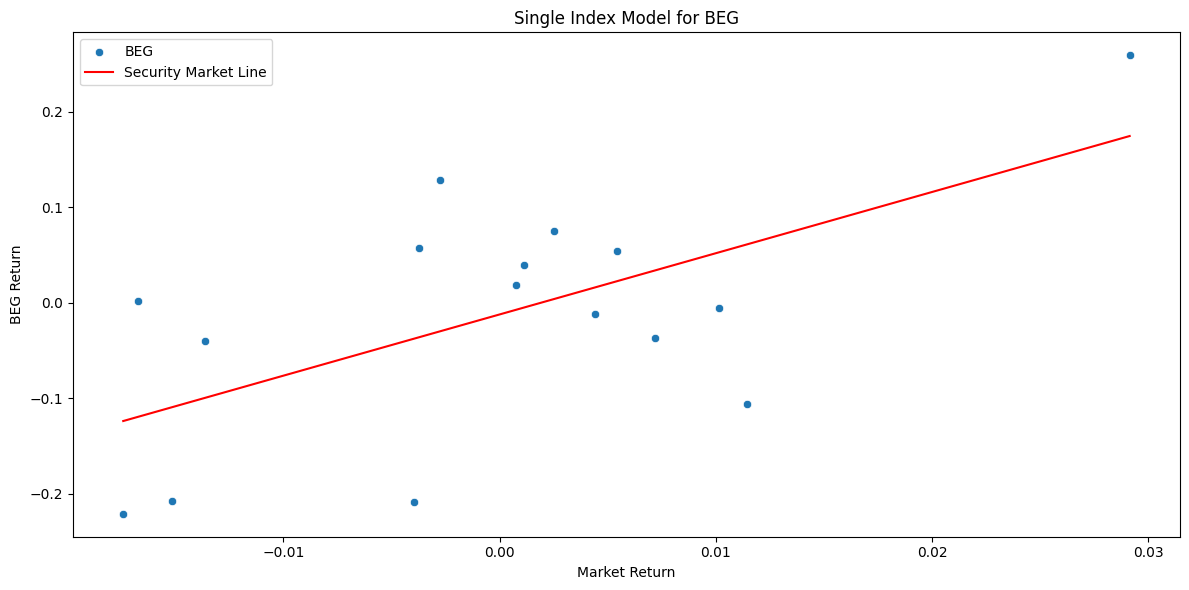

                            OLS Regression Results                            
Dep. Variable:                   LABX   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     10.39
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00612
Time:                        11:29:53   Log-Likelihood:                 16.716
No. Observations:                  16   AIC:                            -29.43
Df Residuals:                      14   BIC:                            -27.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.023      0.059      0.9

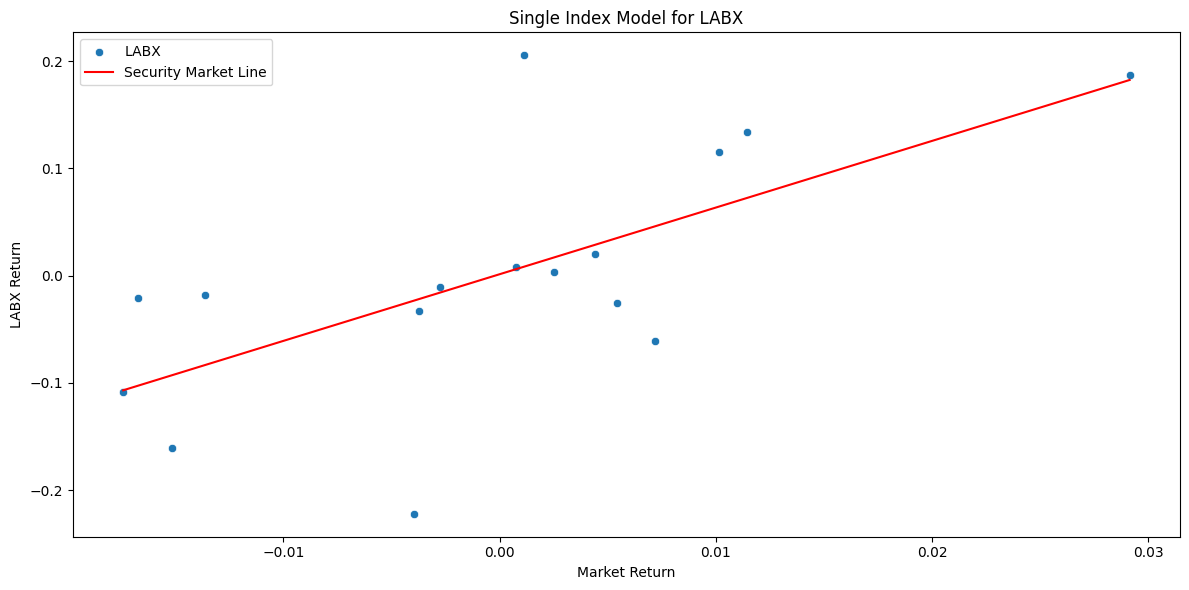

                            OLS Regression Results                            
Dep. Variable:                   GTAO   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     6.016
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0279
Time:                        11:29:53   Log-Likelihood:                 16.999
No. Observations:                  16   AIC:                            -30.00
Df Residuals:                      14   BIC:                            -28.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0294      0.022      1.315      0.2

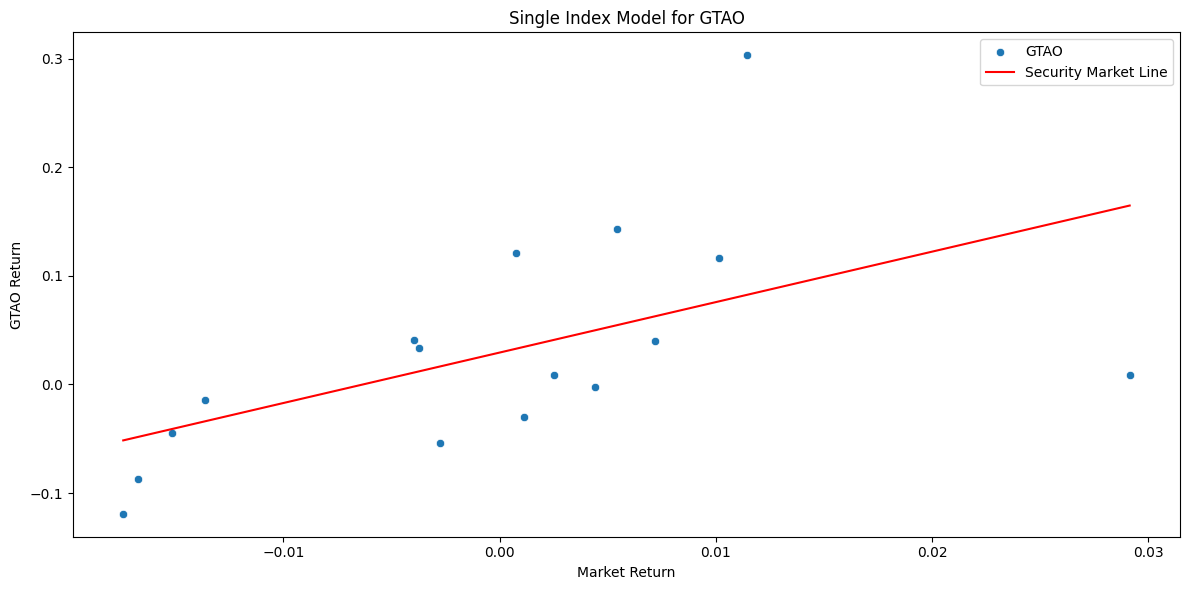

                            OLS Regression Results                            
Dep. Variable:                   CRMU   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     57.13
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.64e-06
Time:                        11:29:53   Log-Likelihood:                 23.274
No. Observations:                  16   AIC:                            -42.55
Df Residuals:                      14   BIC:                            -41.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0149      0.015     -0.989      0.3

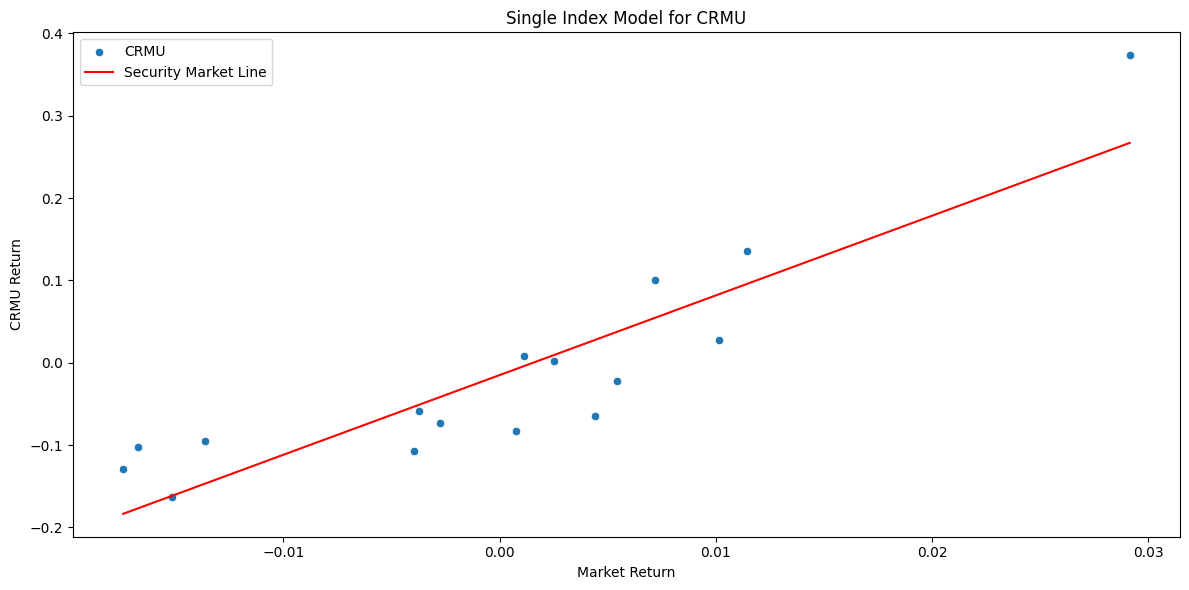

                            OLS Regression Results                            
Dep. Variable:                   CIFU   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     14.61
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00187
Time:                        11:29:54   Log-Likelihood:                 17.922
No. Observations:                  16   AIC:                            -31.84
Df Residuals:                      14   BIC:                            -30.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.021      0.102      0.9

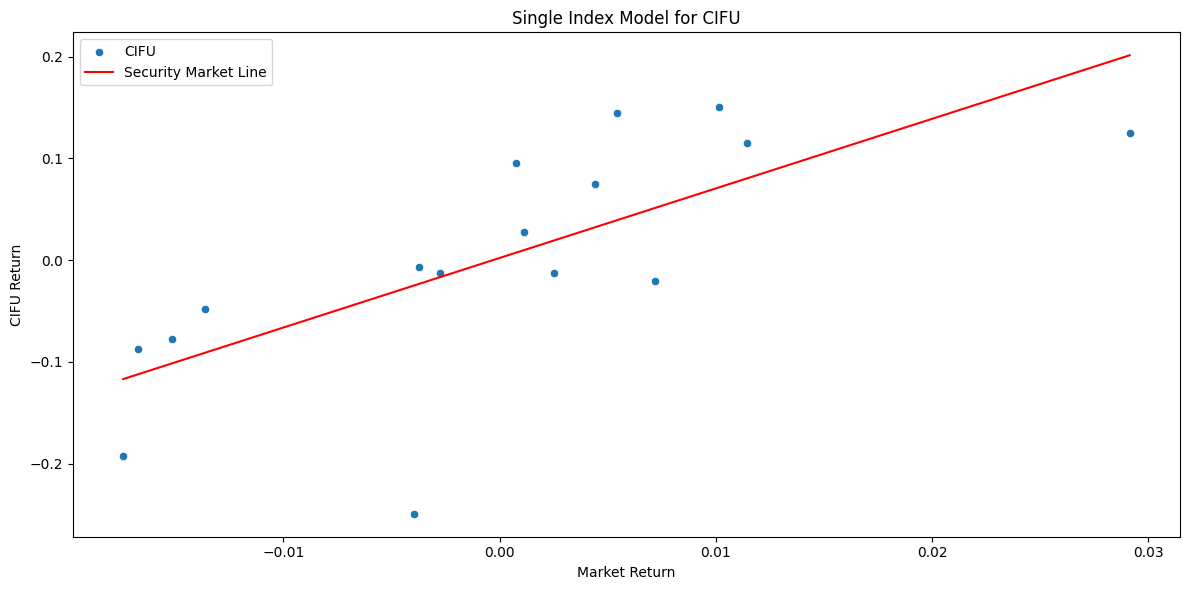

                            OLS Regression Results                            
Dep. Variable:                   EOSU   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     11.50
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00438
Time:                        11:29:54   Log-Likelihood:                 19.085
No. Observations:                  16   AIC:                            -34.17
Df Residuals:                      14   BIC:                            -32.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0293      0.020     -1.491      0.1

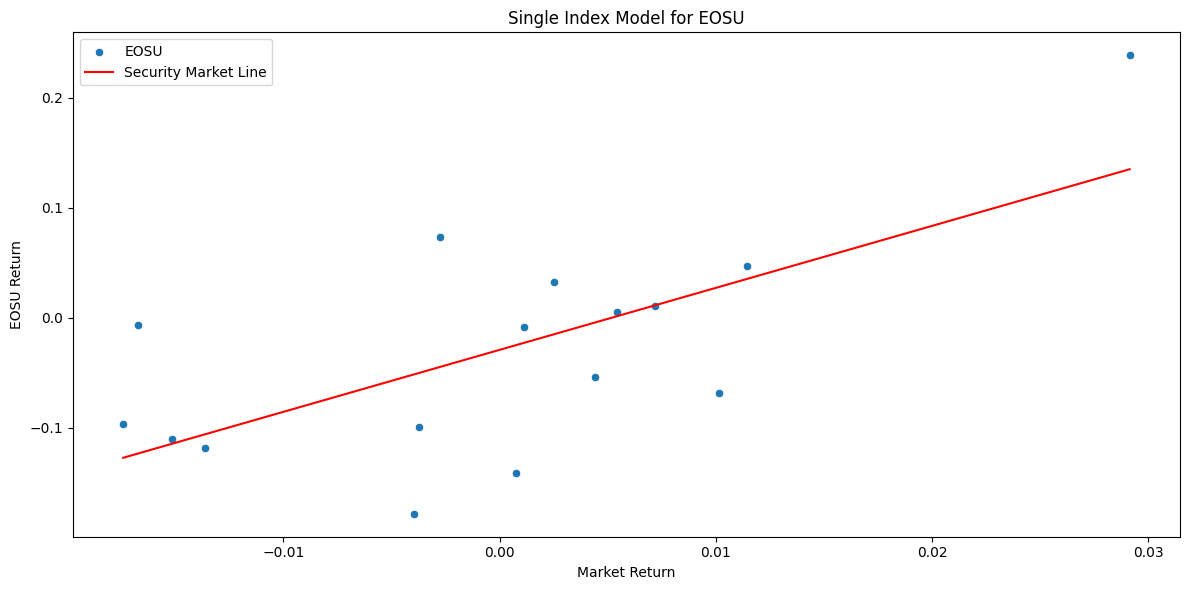

                            OLS Regression Results                            
Dep. Variable:                   MVLL   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     22.22
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000332
Time:                        11:29:54   Log-Likelihood:                 22.705
No. Observations:                  16   AIC:                            -41.41
Df Residuals:                      14   BIC:                            -39.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0295      0.016      1.889      0.0

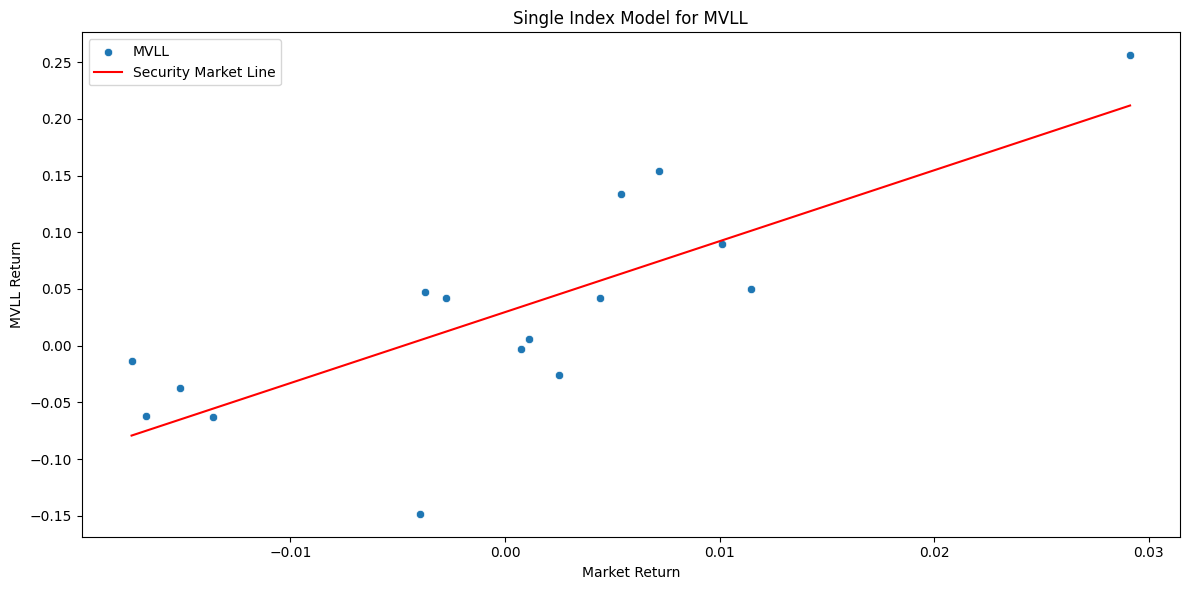

                            OLS Regression Results                            
Dep. Variable:                   CRMX   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     53.79
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.71e-06
Time:                        11:29:54   Log-Likelihood:                 22.962
No. Observations:                  16   AIC:                            -41.92
Df Residuals:                      14   BIC:                            -40.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0148      0.015     -0.962      0.3

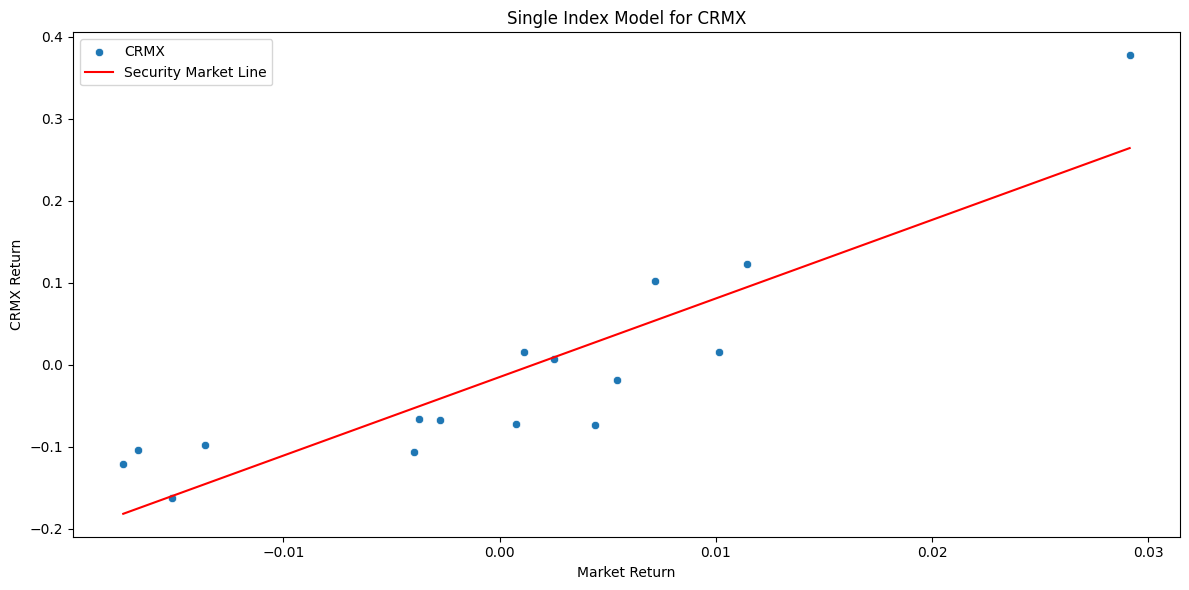

                            OLS Regression Results                            
Dep. Variable:                  VFPAF   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     1.700
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.213
Time:                        11:29:54   Log-Likelihood:                 41.781
No. Observations:                  16   AIC:                            -79.56
Df Residuals:                      14   BIC:                            -78.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0026      0.005     -0.555      0.5

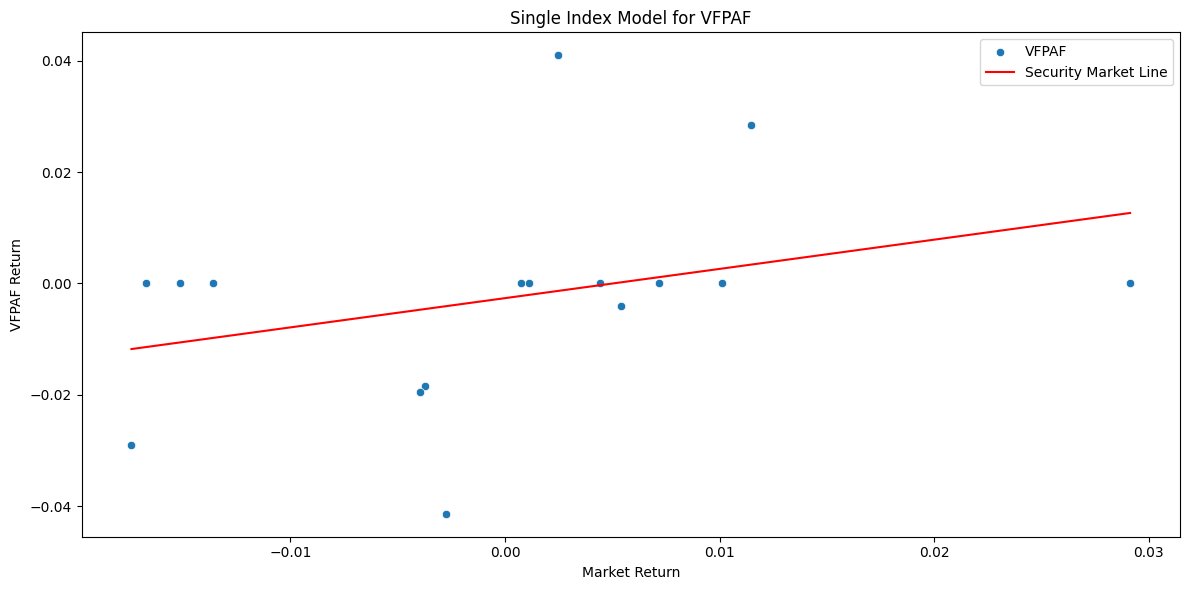

                            OLS Regression Results                            
Dep. Variable:                   VOYX   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     11.29
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00466
Time:                        11:29:54   Log-Likelihood:                 15.897
No. Observations:                  16   AIC:                            -27.79
Df Residuals:                      14   BIC:                            -26.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.024      0.216      0.8

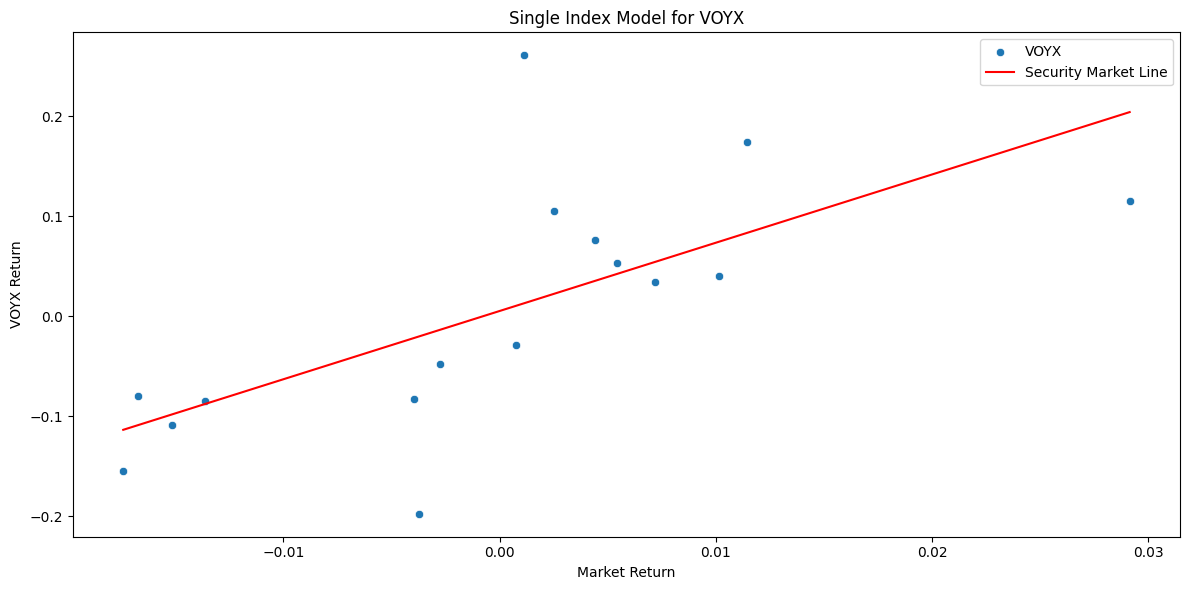

                            OLS Regression Results                            
Dep. Variable:                   MRVU   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     23.06
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000281
Time:                        11:29:55   Log-Likelihood:                 22.986
No. Observations:                  16   AIC:                            -41.97
Df Residuals:                      14   BIC:                            -40.43
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0299      0.015      1.944      0.0

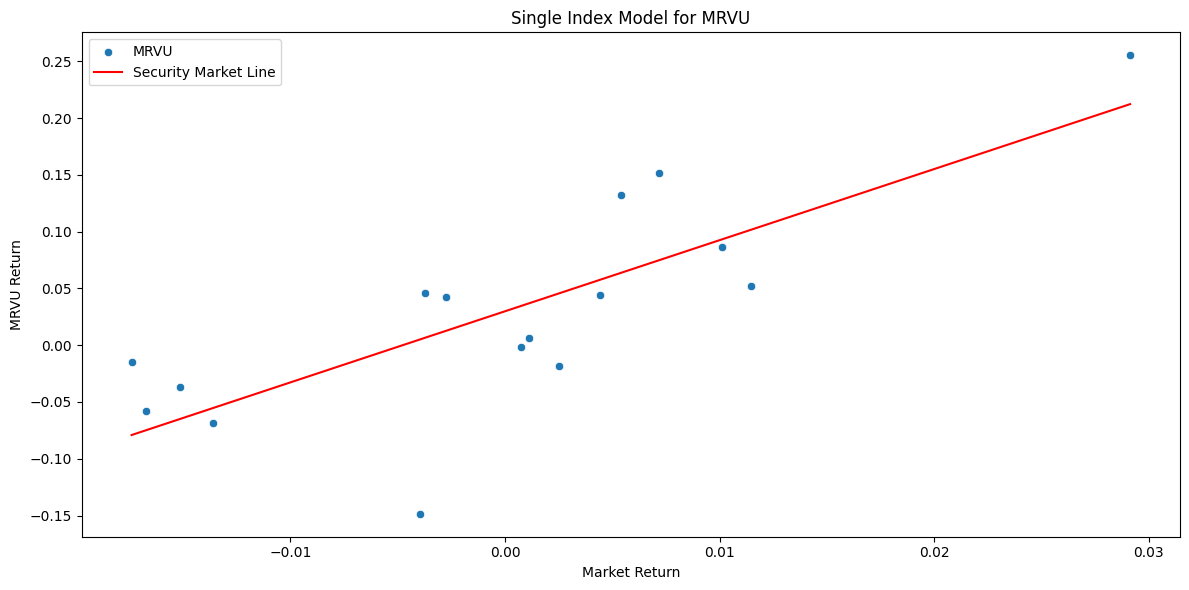

                            OLS Regression Results                            
Dep. Variable:                   LUNL   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     12.65
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00316
Time:                        11:29:55   Log-Likelihood:                 9.7852
No. Observations:                  16   AIC:                            -15.57
Df Residuals:                      14   BIC:                            -14.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0390      0.035      1.111      0.2

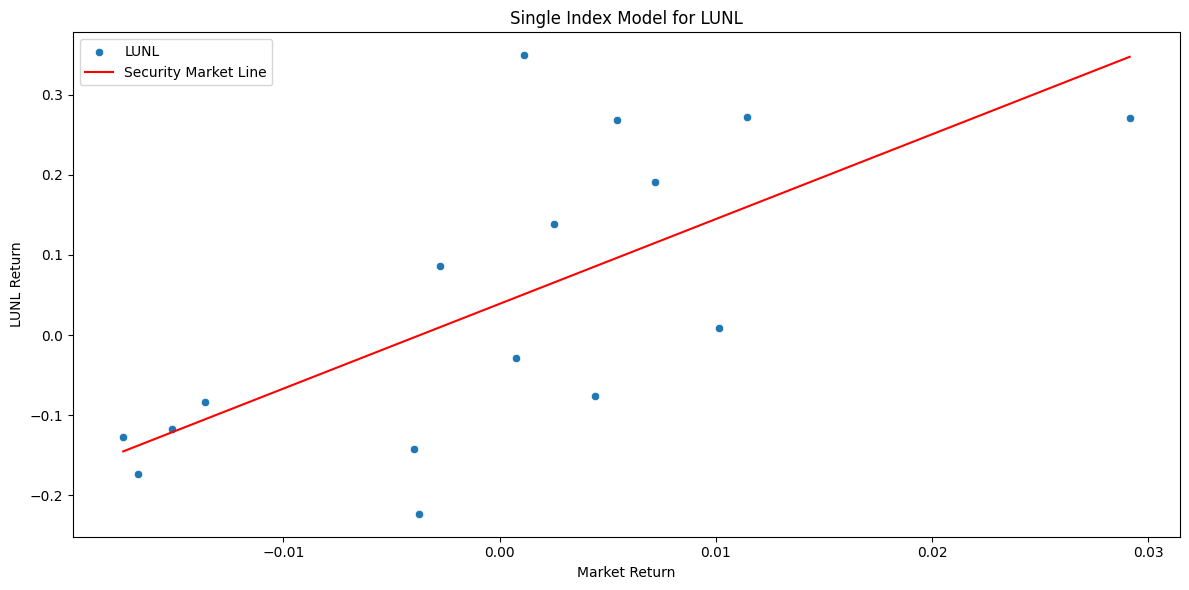

                            OLS Regression Results                            
Dep. Variable:                   ARMG   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     7.347
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0169
Time:                        11:29:55   Log-Likelihood:                 15.580
No. Observations:                  16   AIC:                            -27.16
Df Residuals:                      14   BIC:                            -25.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0306      0.024      1.252      0.2

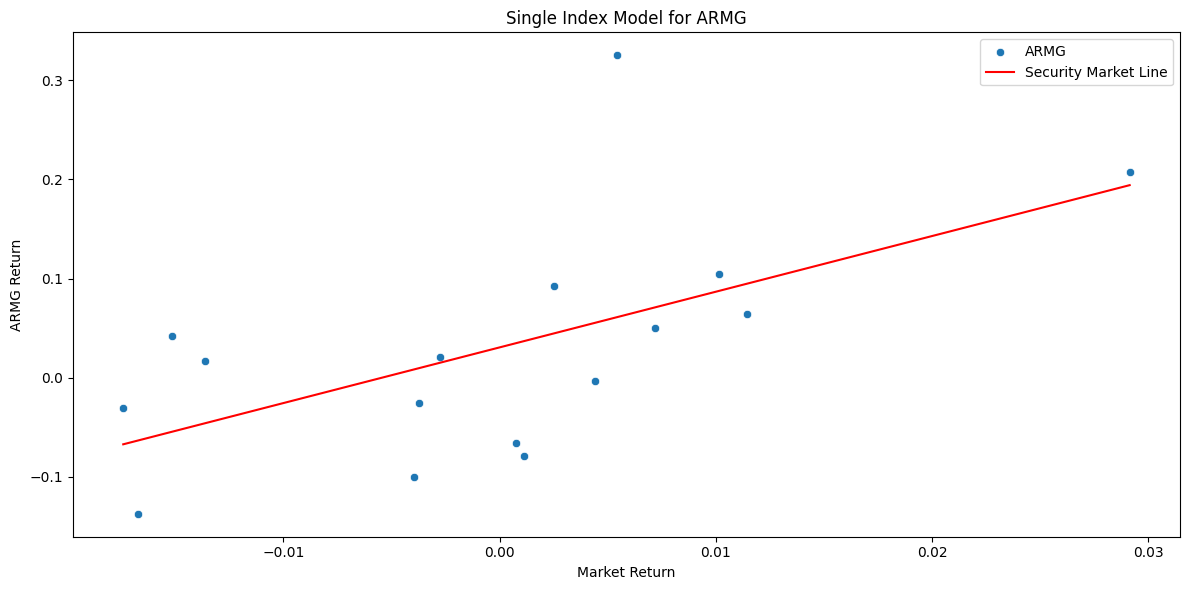

                            OLS Regression Results                            
Dep. Variable:                   CSEX   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     12.41
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00338
Time:                        11:29:55   Log-Likelihood:                 19.260
No. Observations:                  16   AIC:                            -34.52
Df Residuals:                      14   BIC:                            -32.97
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0183      0.019      0.945      0.3

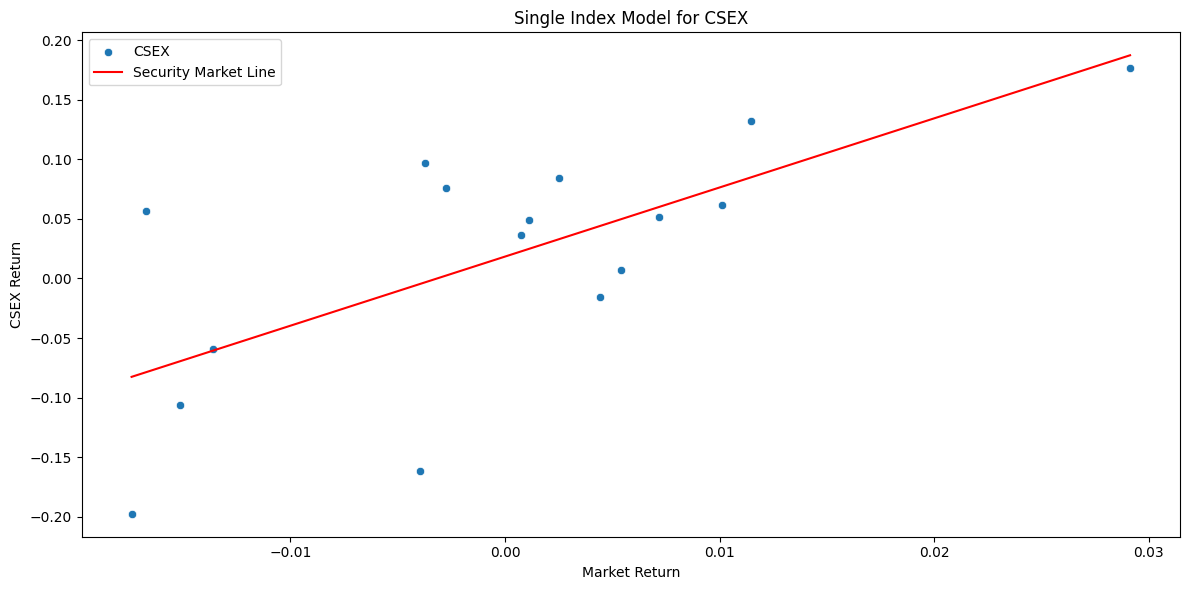

                            OLS Regression Results                            
Dep. Variable:                   ODOT   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.9579
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.344
Time:                        11:29:55   Log-Likelihood:                 31.547
No. Observations:                  16   AIC:                            -59.09
Df Residuals:                      14   BIC:                            -57.55
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0157      0.009     -1.749      0.1

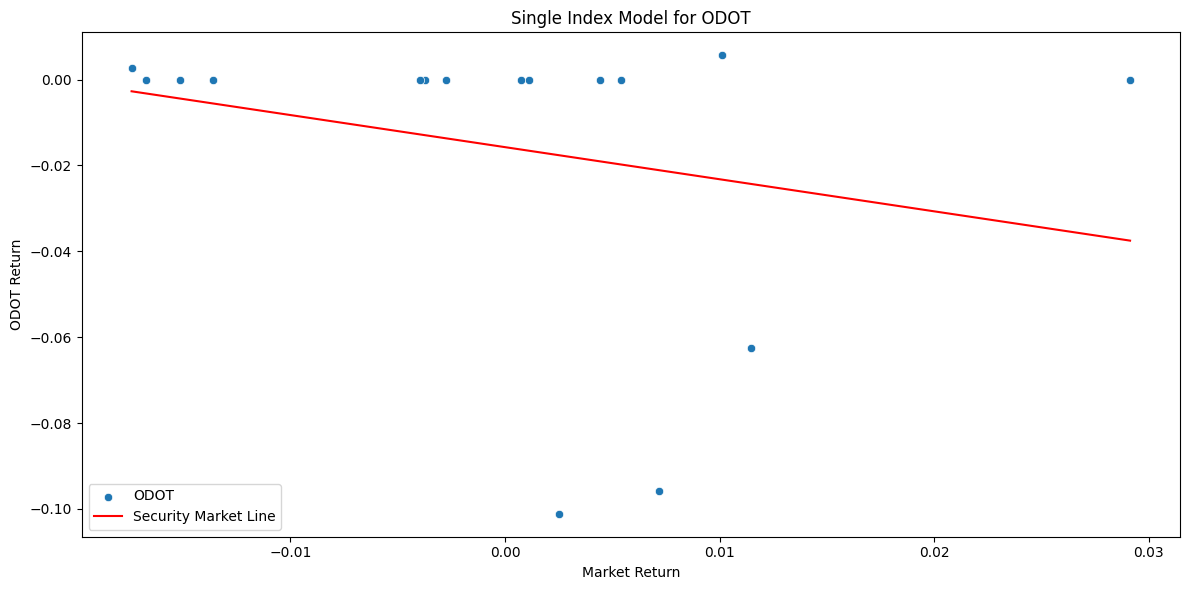

                            OLS Regression Results                            
Dep. Variable:                   USGG   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     12.74
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00308
Time:                        11:29:55   Log-Likelihood:                 19.958
No. Observations:                  16   AIC:                            -35.92
Df Residuals:                      14   BIC:                            -34.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0333      0.019     -1.790      0.0

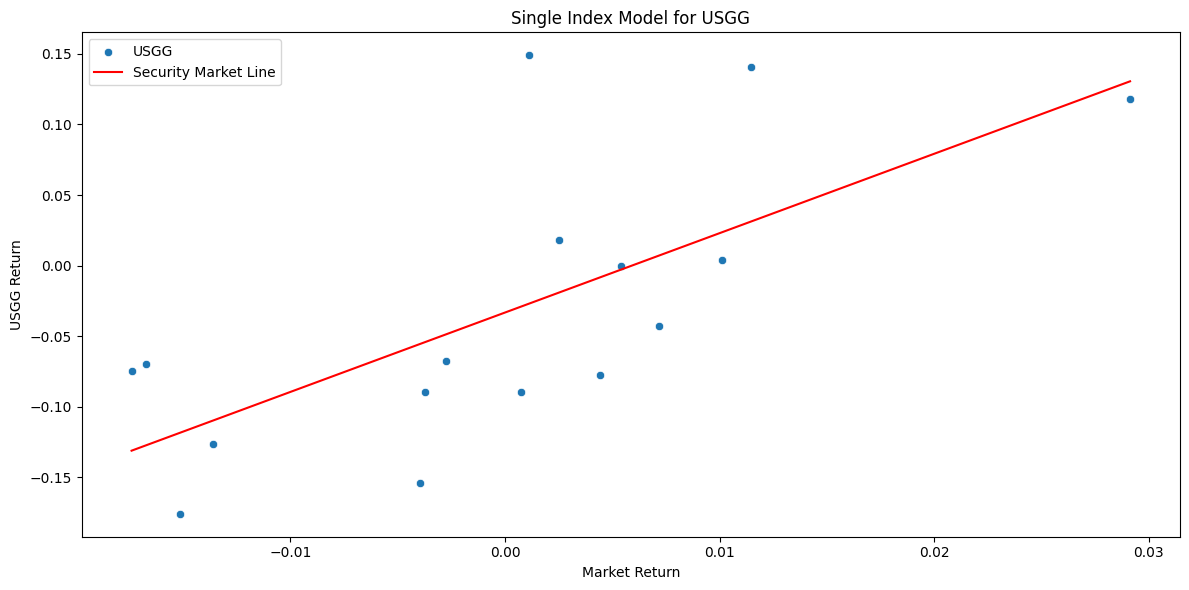

                            OLS Regression Results                            
Dep. Variable:                    PLU   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.061
Method:                 Least Squares   F-statistic:                    0.1377
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.716
Time:                        11:29:56   Log-Likelihood:                 3.4133
No. Observations:                  16   AIC:                            -2.827
Df Residuals:                      14   BIC:                            -1.281
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0525      0.052      1.005      0.3

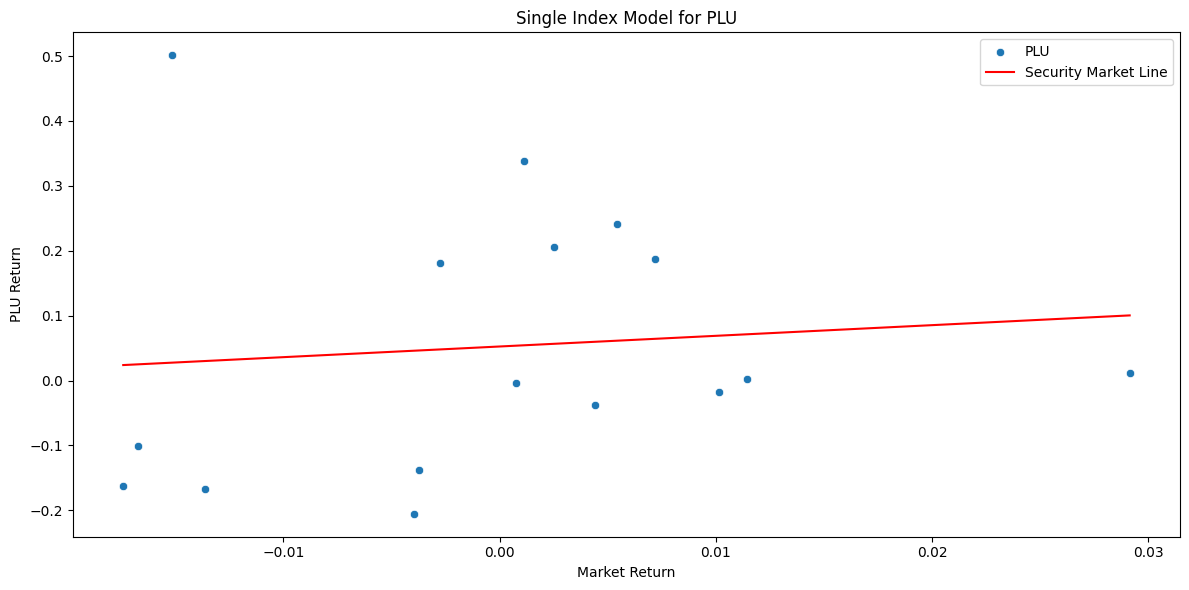

                            OLS Regression Results                            
Dep. Variable:                   AVGX   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     20.15
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000510
Time:                        11:29:56   Log-Likelihood:                 30.645
No. Observations:                  16   AIC:                            -57.29
Df Residuals:                      14   BIC:                            -55.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.010      0.542      0.5

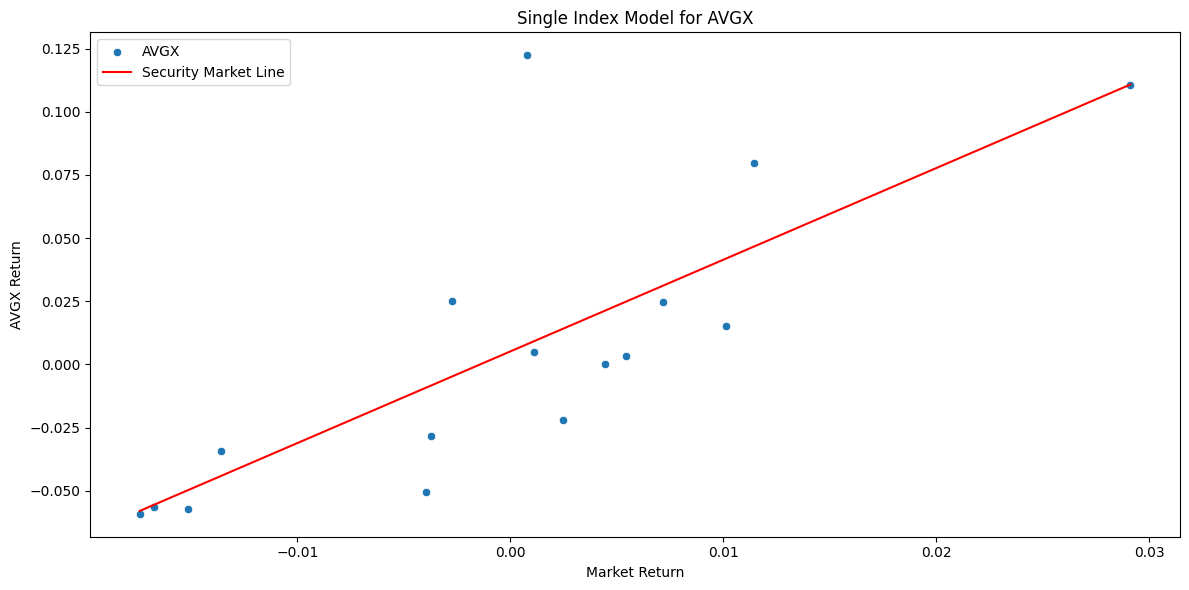

                            OLS Regression Results                            
Dep. Variable:                   APLX   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     36.01
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.25e-05
Time:                        11:29:56   Log-Likelihood:                 20.184
No. Observations:                  16   AIC:                            -36.37
Df Residuals:                      14   BIC:                            -34.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0050      0.018     -0.273      0.7

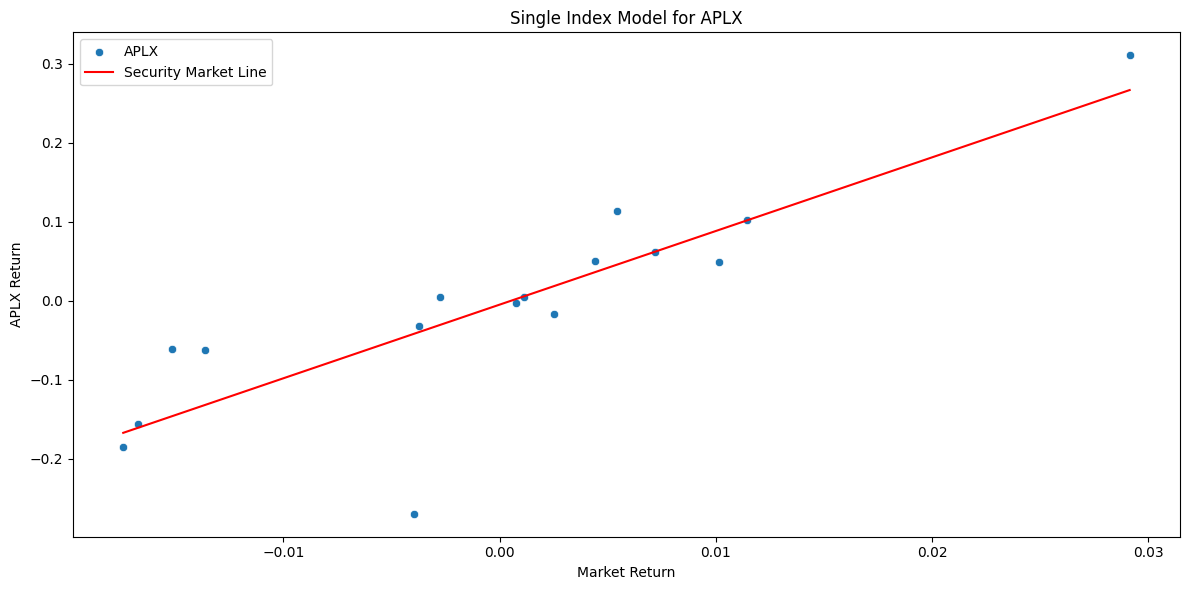

                            OLS Regression Results                            
Dep. Variable:                   CWVX   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     13.13
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00277
Time:                        11:29:56   Log-Likelihood:                 18.308
No. Observations:                  16   AIC:                            -32.62
Df Residuals:                      14   BIC:                            -31.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0091      0.021      0.442      0.6

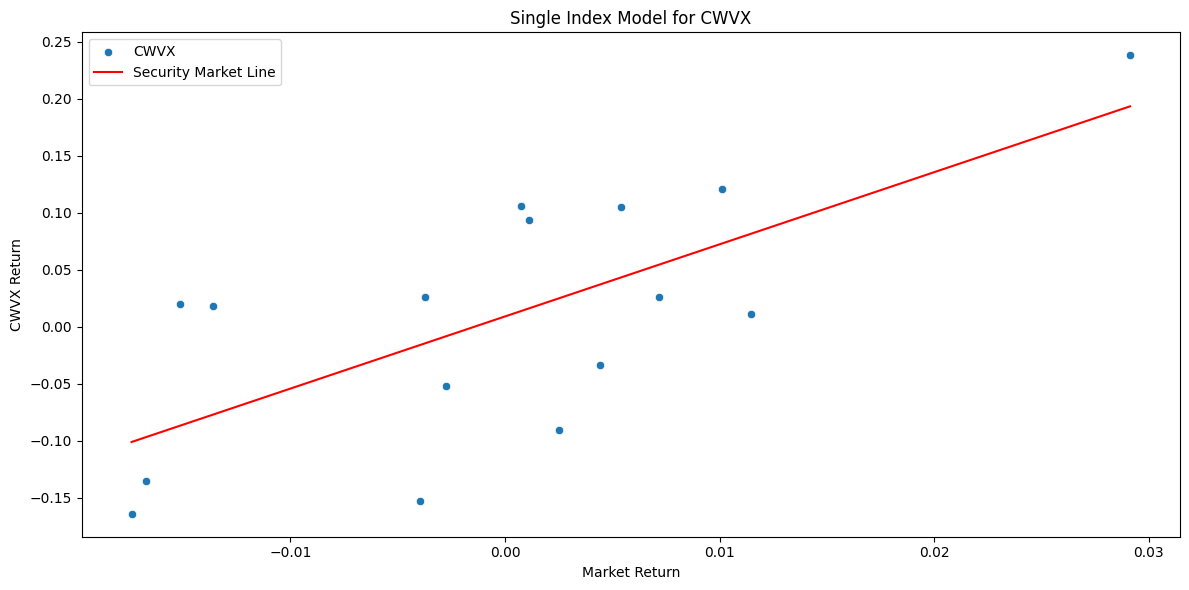

                            OLS Regression Results                            
Dep. Variable:                   WULX   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     13.99
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00220
Time:                        11:29:56   Log-Likelihood:                 17.812
No. Observations:                  16   AIC:                            -31.62
Df Residuals:                      14   BIC:                            -30.08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0182      0.021      0.855      0.4

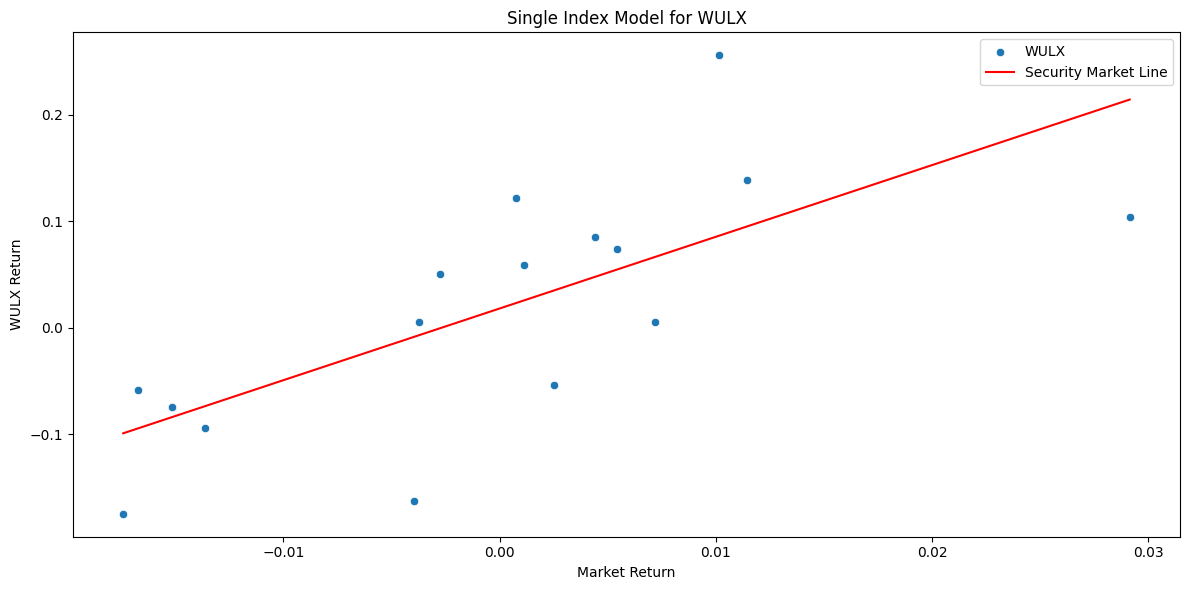

                            OLS Regression Results                            
Dep. Variable:                   USAX   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     12.57
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00323
Time:                        11:29:56   Log-Likelihood:                 19.616
No. Observations:                  16   AIC:                            -35.23
Df Residuals:                      14   BIC:                            -33.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0332      0.019     -1.749      0.1

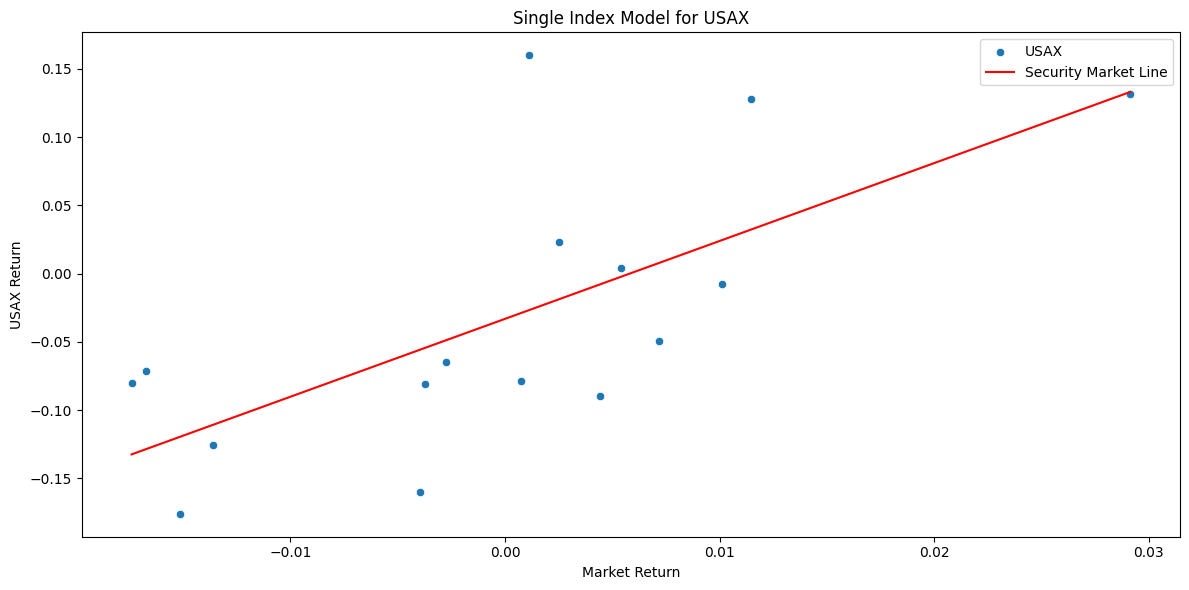

                            OLS Regression Results                            
Dep. Variable:                   AVGG   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     19.96
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000531
Time:                        11:29:57   Log-Likelihood:                 30.819
No. Observations:                  16   AIC:                            -57.64
Df Residuals:                      14   BIC:                            -56.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0051      0.009      0.541      0.5

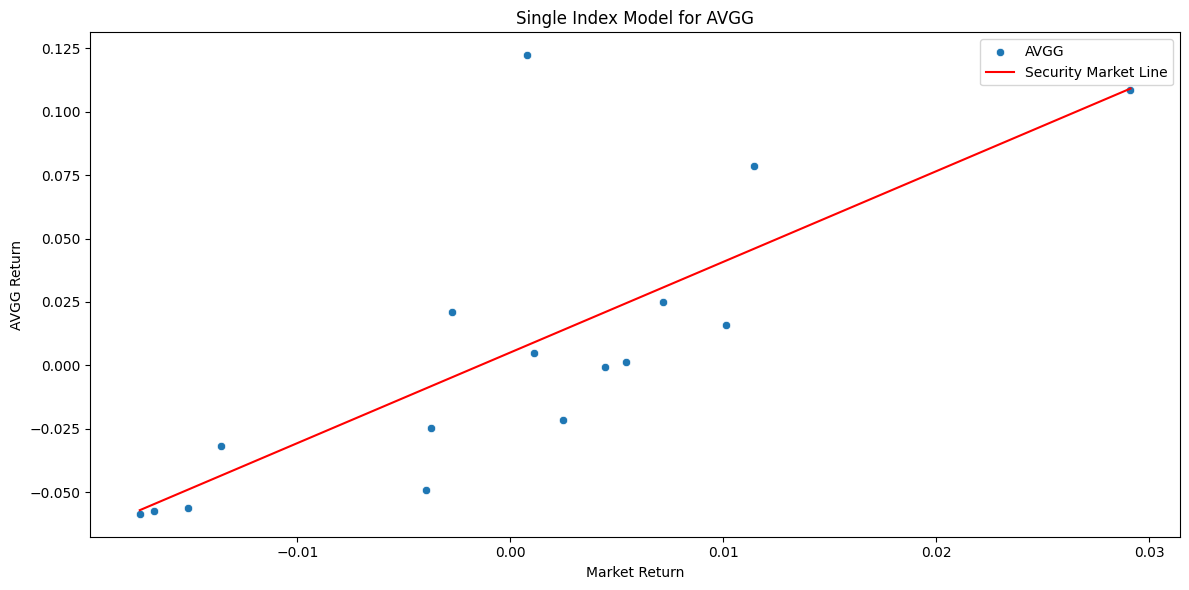

                            OLS Regression Results                            
Dep. Variable:                   PBRG   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                  0.006398
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.937
Time:                        11:29:57   Log-Likelihood:                 28.066
No. Observations:                  16   AIC:                            -52.13
Df Residuals:                      14   BIC:                            -50.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0133      0.011      1.186      0.2

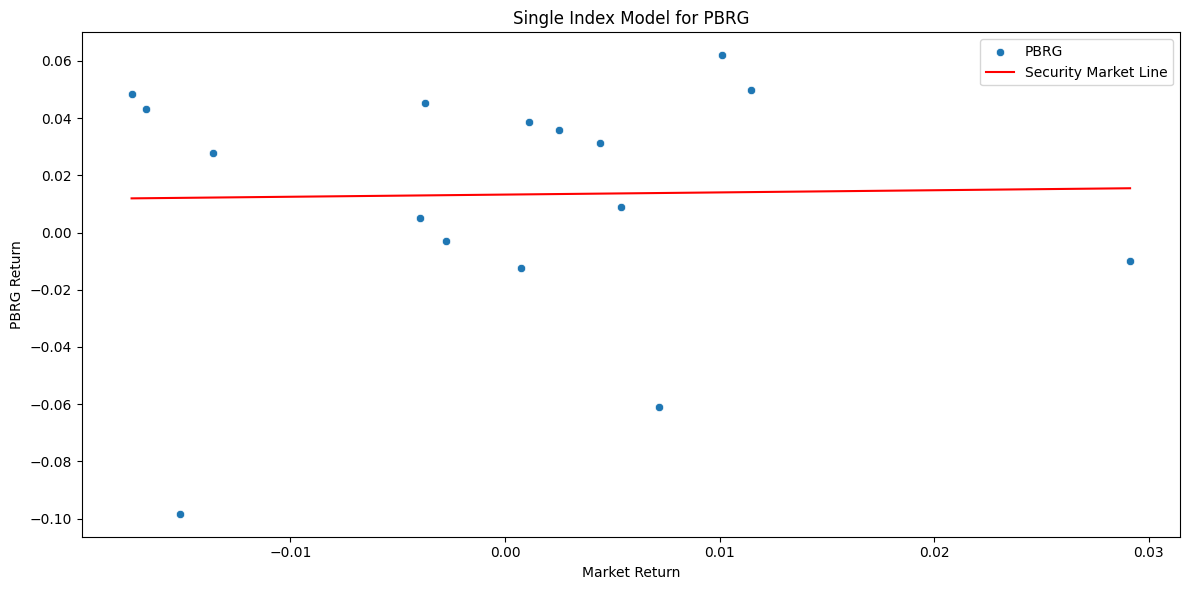

                            OLS Regression Results                            
Dep. Variable:                    AVL   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     20.37
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000487
Time:                        11:29:57   Log-Likelihood:                 30.856
No. Observations:                  16   AIC:                            -57.71
Df Residuals:                      14   BIC:                            -56.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0053      0.009      0.559      0.5

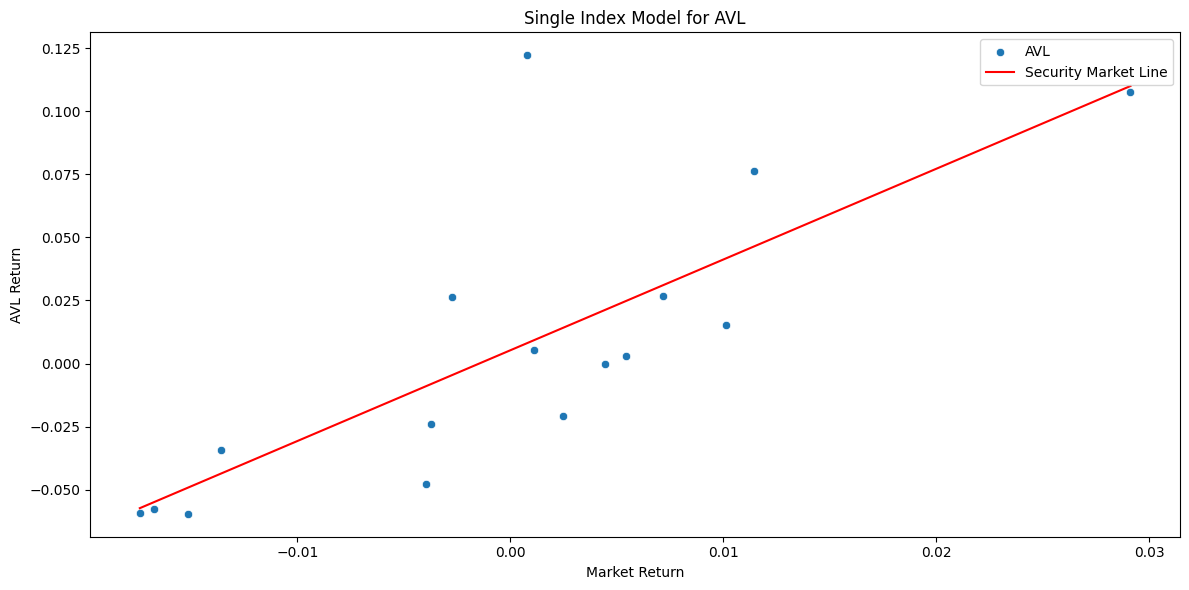

                            OLS Regression Results                            
Dep. Variable:                   AVGU   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     19.66
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000567
Time:                        11:29:57   Log-Likelihood:                 30.368
No. Observations:                  16   AIC:                            -56.74
Df Residuals:                      14   BIC:                            -55.19
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0051      0.010      0.530      0.6

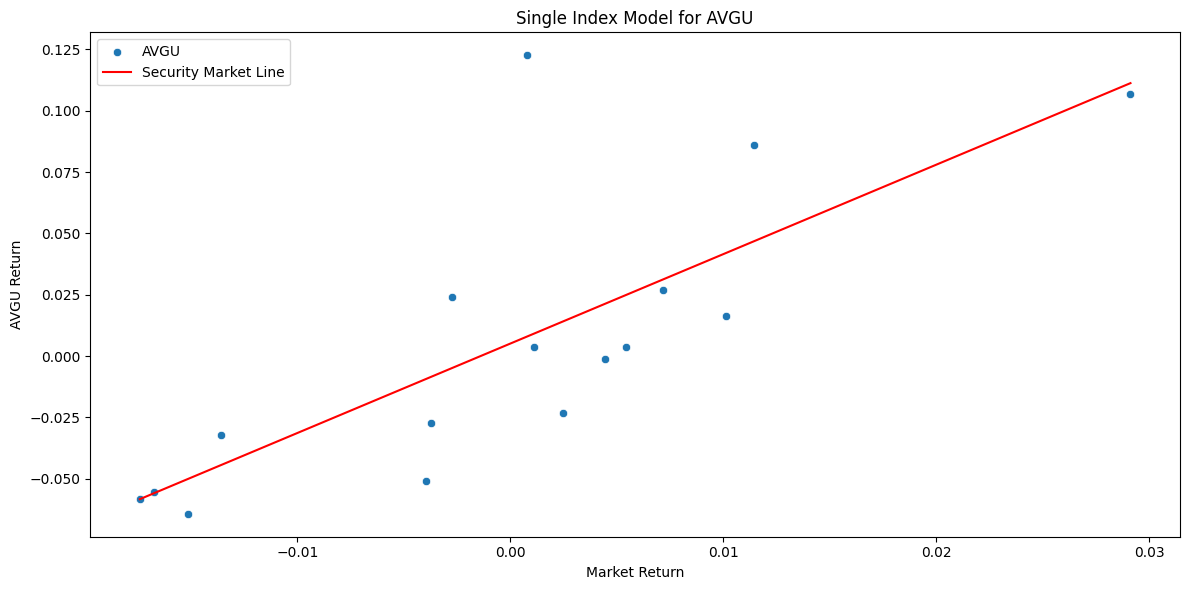

                            OLS Regression Results                            
Dep. Variable:                   SMCL   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     8.214
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0124
Time:                        11:29:57   Log-Likelihood:                 7.7686
No. Observations:                  16   AIC:                            -11.54
Df Residuals:                      14   BIC:                            -9.992
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0272      0.040     -0.685      0.5

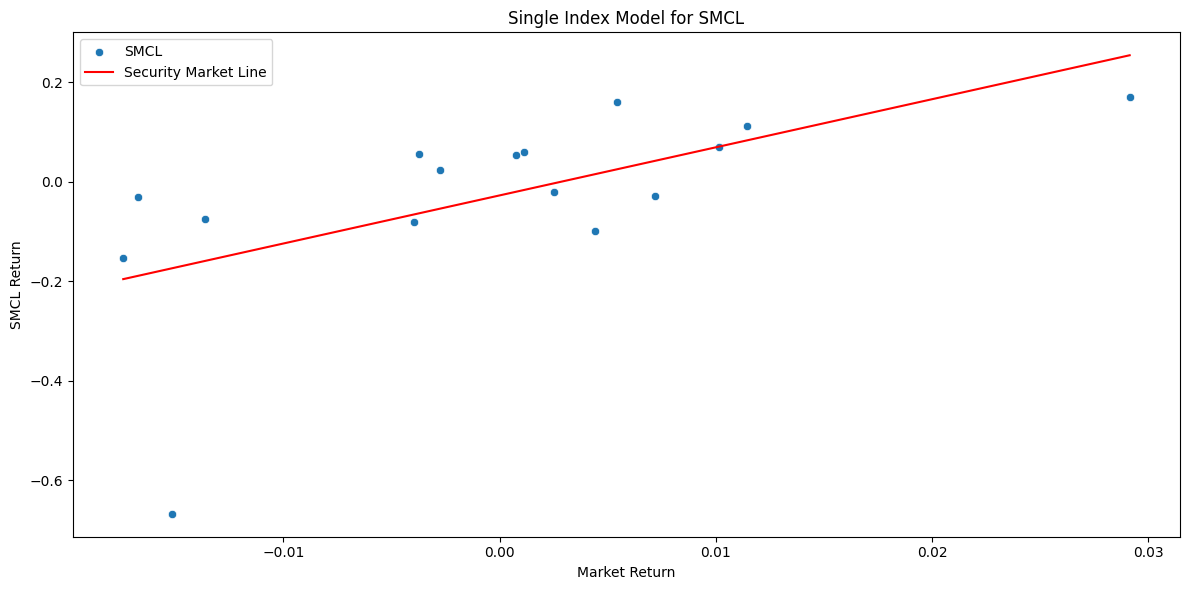

                            OLS Regression Results                            
Dep. Variable:                   IREX   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     17.32
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000959
Time:                        11:29:57   Log-Likelihood:                 20.718
No. Observations:                  16   AIC:                            -37.44
Df Residuals:                      14   BIC:                            -35.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0167      0.018     -0.943      0.3

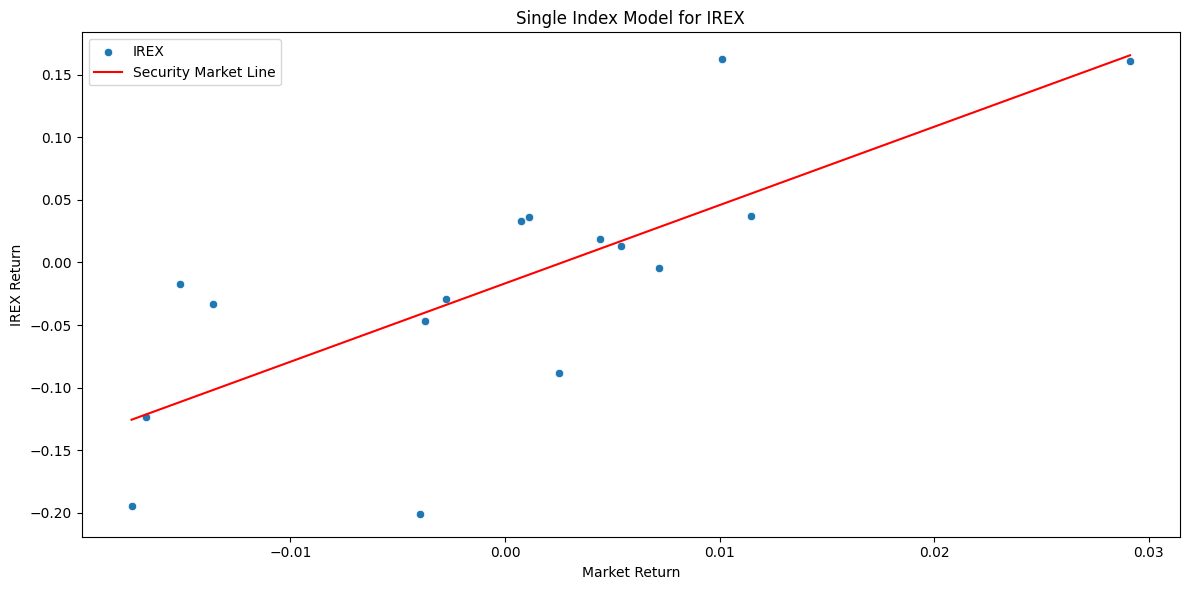

                            OLS Regression Results                            
Dep. Variable:                   AMUU   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     7.712
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0148
Time:                        11:29:58   Log-Likelihood:                 24.783
No. Observations:                  16   AIC:                            -45.57
Df Residuals:                      14   BIC:                            -44.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0179      0.014      1.303      0.2

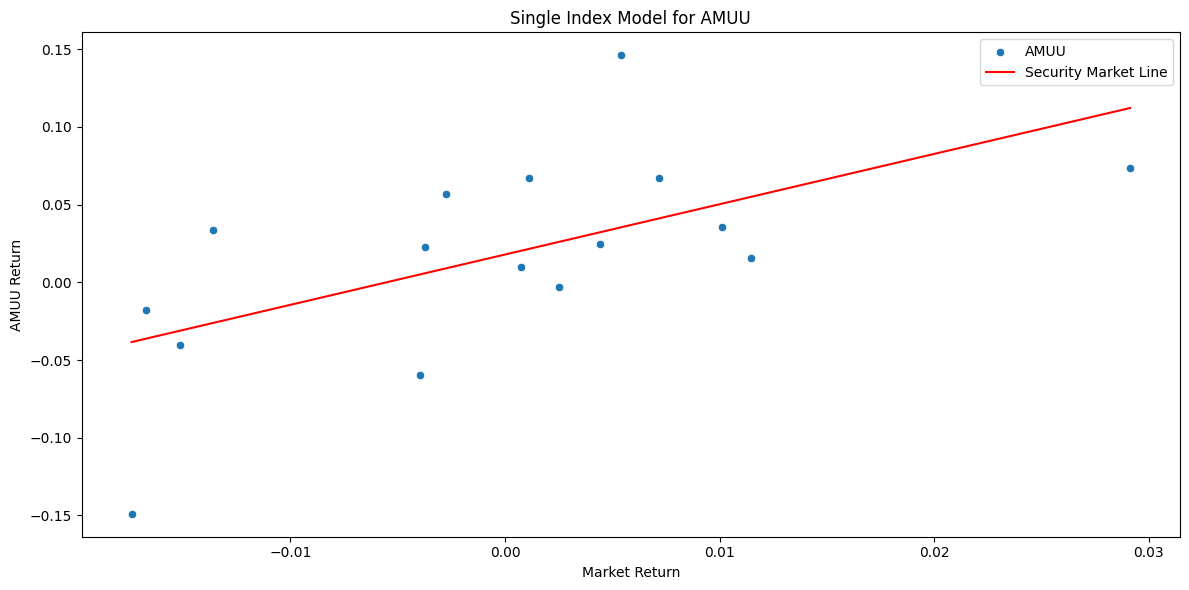

                            OLS Regression Results                            
Dep. Variable:                    IRE   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     17.78
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000862
Time:                        11:29:58   Log-Likelihood:                 20.891
No. Observations:                  16   AIC:                            -37.78
Df Residuals:                      14   BIC:                            -36.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0175      0.018     -0.998      0.3

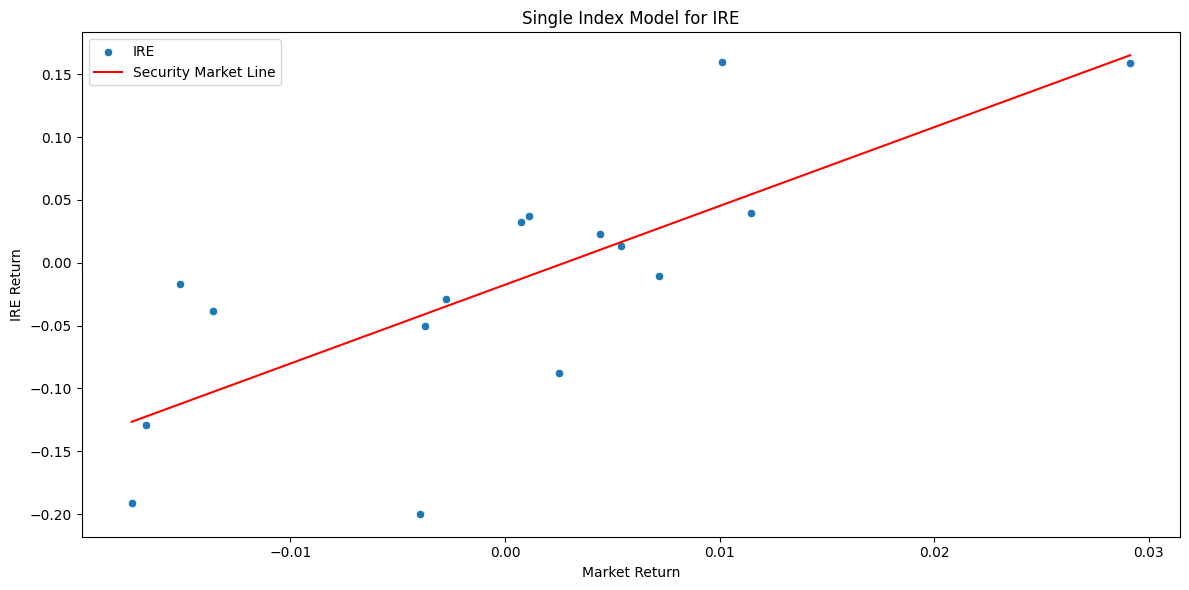

                            OLS Regression Results                            
Dep. Variable:                   AMDL   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     7.674
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0150
Time:                        11:29:58   Log-Likelihood:                 24.930
No. Observations:                  16   AIC:                            -45.86
Df Residuals:                      14   BIC:                            -44.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0179      0.014      1.312      0.2

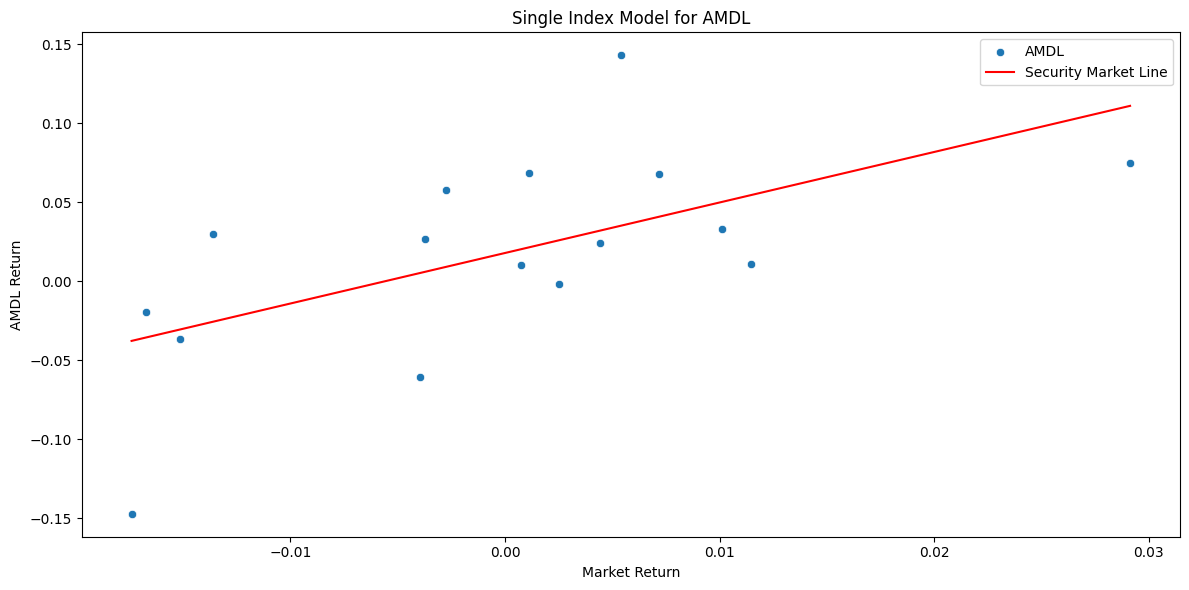

                            OLS Regression Results                            
Dep. Variable:                   COZX   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     19.45
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000592
Time:                        11:29:58   Log-Likelihood:                 22.835
No. Observations:                  16   AIC:                            -41.67
Df Residuals:                      14   BIC:                            -40.12
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0043      0.016      0.275      0.7

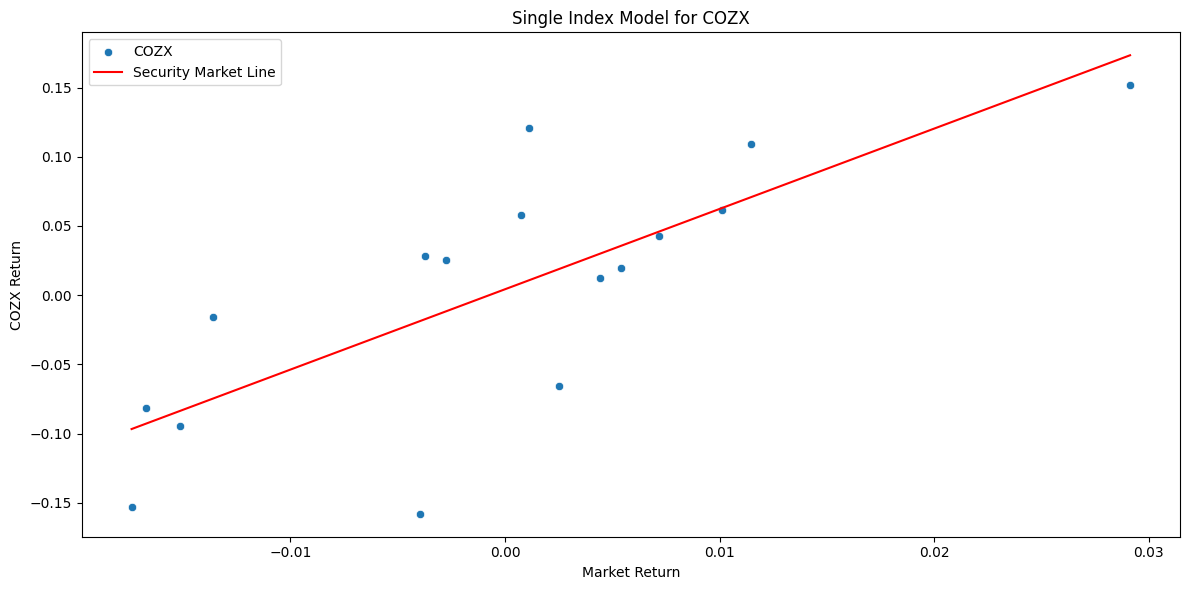

                            OLS Regression Results                            
Dep. Variable:                   QUBX   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     24.23
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000225
Time:                        11:29:58   Log-Likelihood:                 27.237
No. Observations:                  16   AIC:                            -50.47
Df Residuals:                      14   BIC:                            -48.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0092      0.012     -0.779      0.4

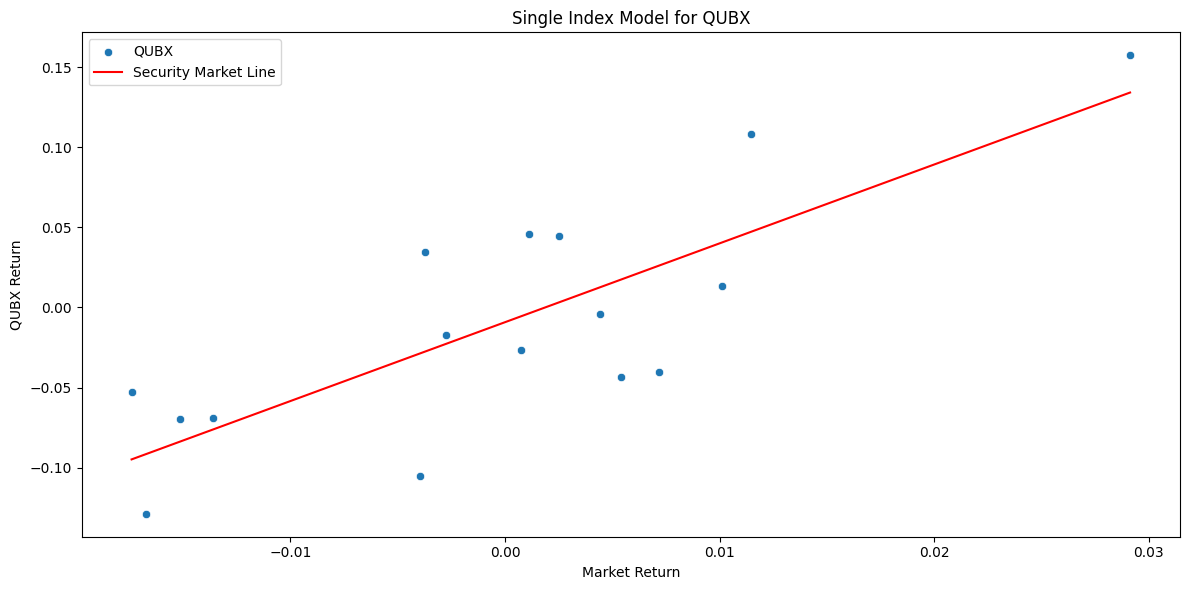

                            OLS Regression Results                            
Dep. Variable:                   TEMT   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     37.53
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.62e-05
Time:                        11:29:59   Log-Likelihood:                 30.969
No. Observations:                  16   AIC:                            -57.94
Df Residuals:                      14   BIC:                            -56.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0075      0.009     -0.805      0.4

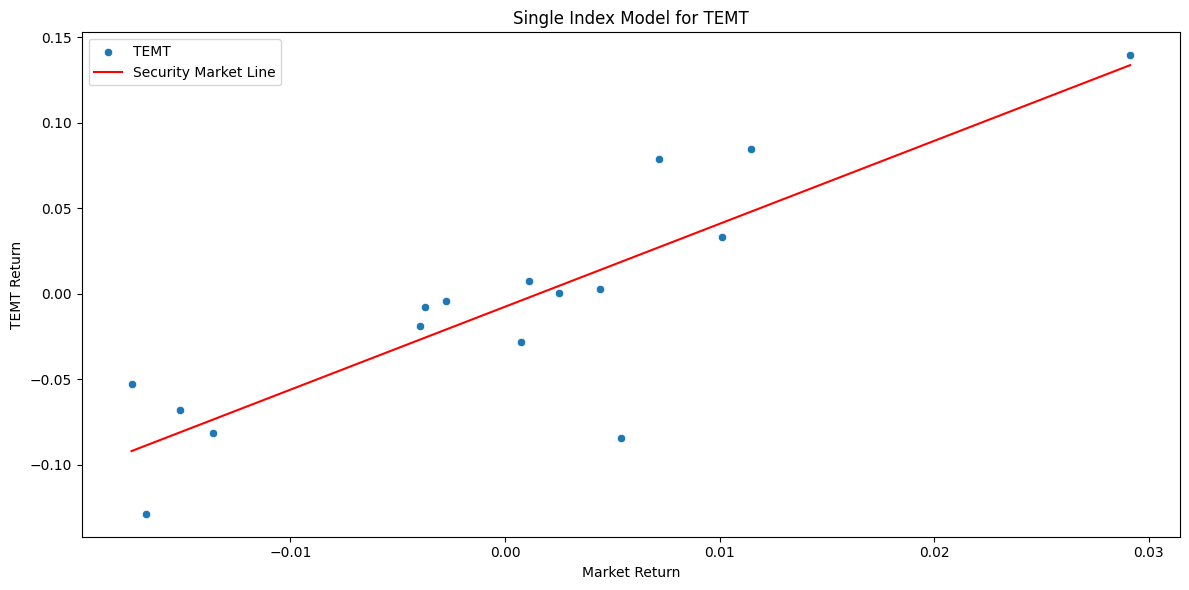

                            OLS Regression Results                            
Dep. Variable:                    QQQ   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     835.4
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           6.97e-14
Time:                        11:29:59   Log-Likelihood:                 78.127
No. Observations:                  16   AIC:                            -152.3
Df Residuals:                      14   BIC:                            -150.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.000     -0.554      0.5

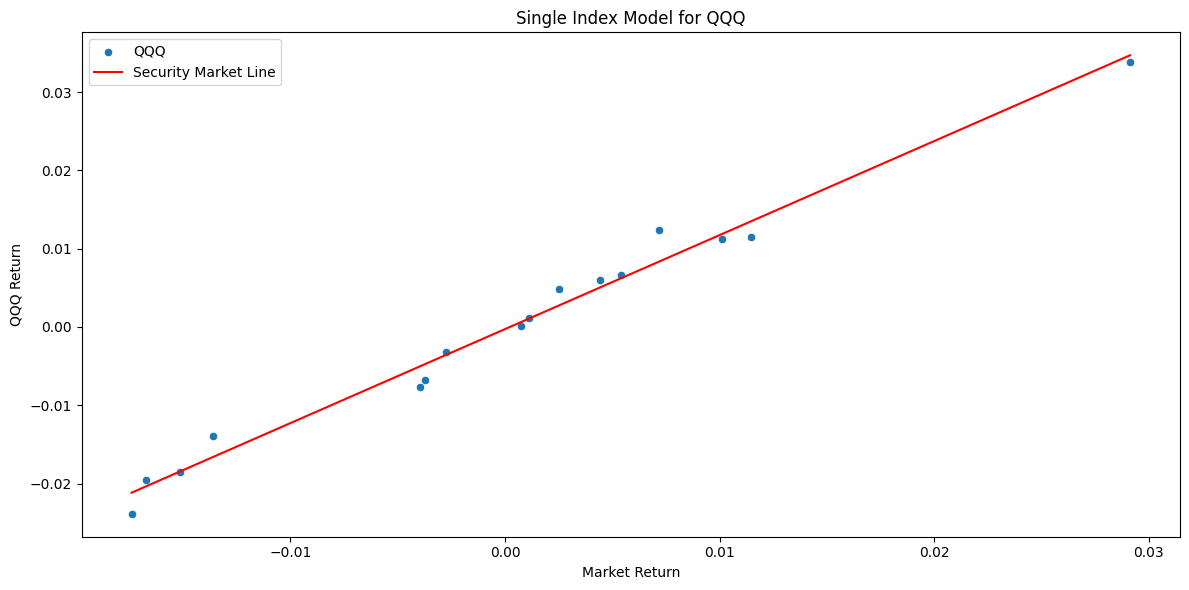

                            OLS Regression Results                            
Dep. Variable:                   ^IRX   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.053
Method:                 Least Squares   F-statistic:                    0.2490
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.626
Time:                        11:29:59   Log-Likelihood:                 77.595
No. Observations:                  16   AIC:                            -151.2
Df Residuals:                      14   BIC:                            -149.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.001      0.417      0.6

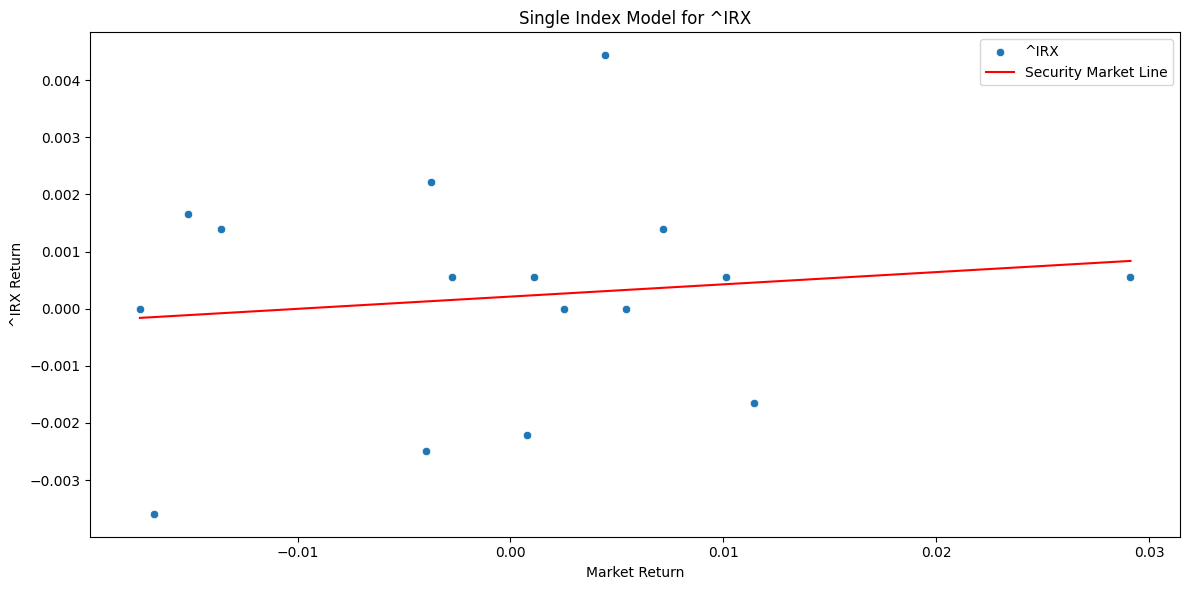

                            OLS Regression Results                            
Dep. Variable:                   ^FVX   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     7.295
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0172
Time:                        11:29:59   Log-Likelihood:                 46.917
No. Observations:                  16   AIC:                            -89.83
Df Residuals:                      14   BIC:                            -88.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.003      0.491      0.6

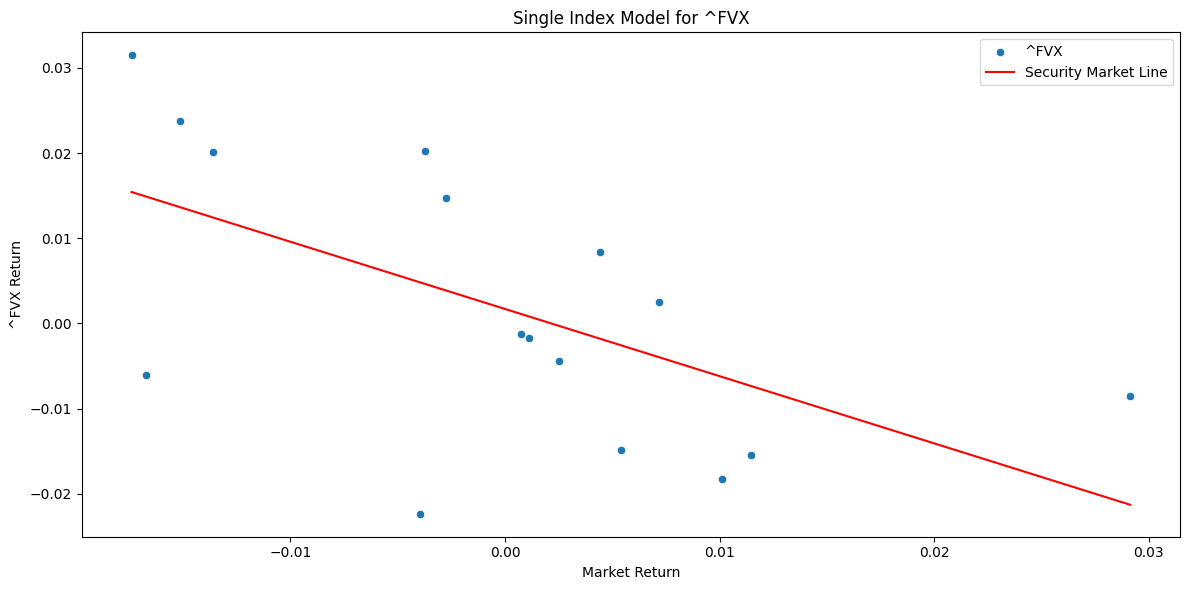

                            OLS Regression Results                            
Dep. Variable:                   ^TNX   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     9.618
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00781
Time:                        11:29:59   Log-Likelihood:                 51.033
No. Observations:                  16   AIC:                            -98.07
Df Residuals:                      14   BIC:                            -96.52
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.003      0.327      0.7

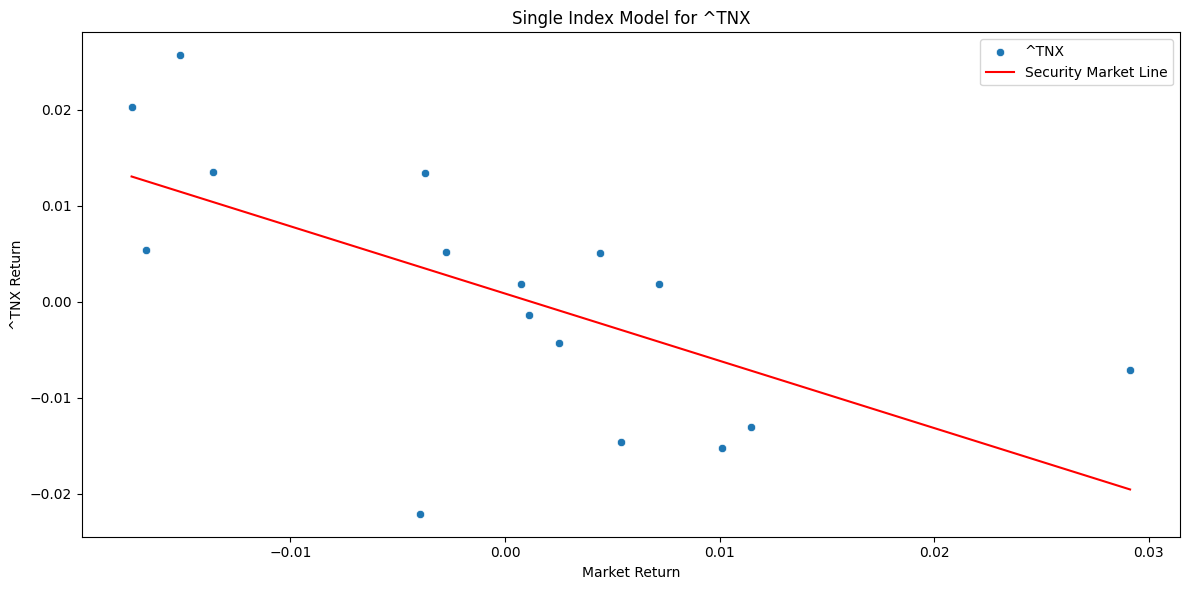

                            OLS Regression Results                            
Dep. Variable:                   ^TYX   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     6.983
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0193
Time:                        11:29:59   Log-Likelihood:                 55.769
No. Observations:                  16   AIC:                            -107.5
Df Residuals:                      14   BIC:                            -106.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.002      0.087      0.9

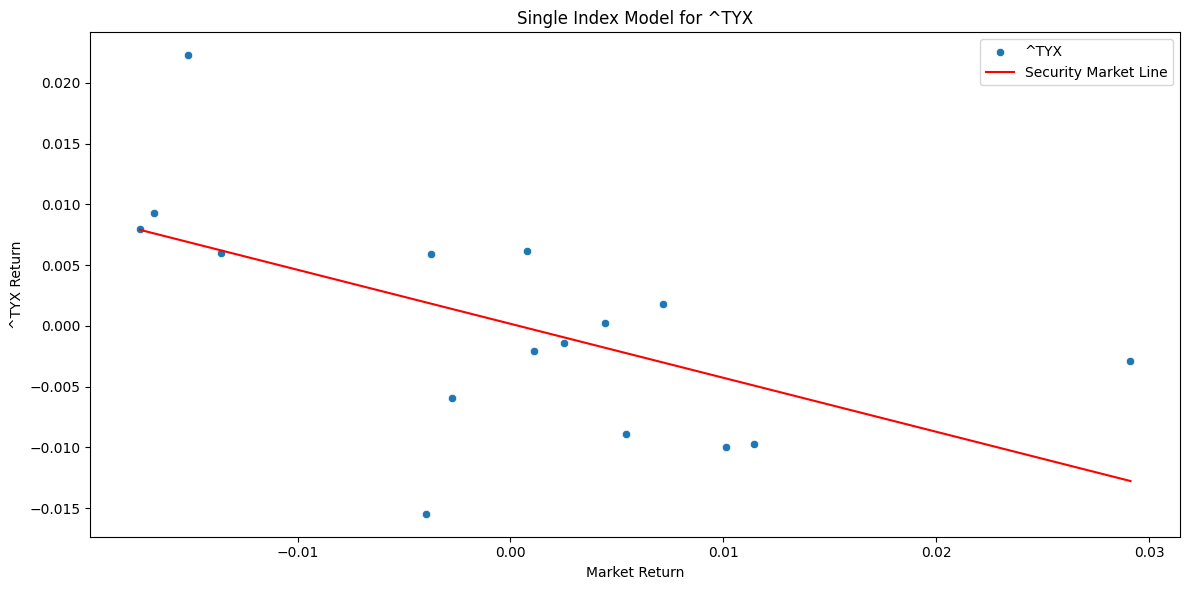

                            OLS Regression Results                            
Dep. Variable:               USDT-USD   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.6416
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.437
Time:                        11:30:00   Log-Likelihood:                 110.93
No. Observations:                  16   AIC:                            -217.9
Df Residuals:                      14   BIC:                            -216.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -3.14e-05    6.3e-05     -0.498      0.6

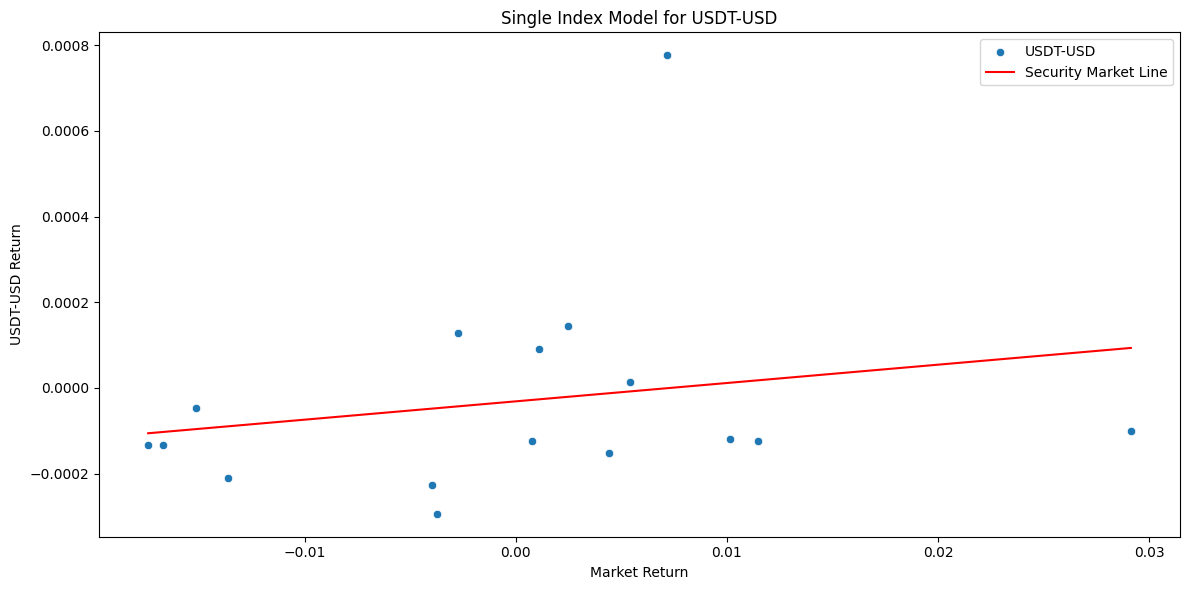

                            OLS Regression Results                            
Dep. Variable:          MPRO31258-USD   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     3.013
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.105
Time:                        11:30:00   Log-Likelihood:                 18.881
No. Observations:                  16   AIC:                            -33.76
Df Residuals:                      14   BIC:                            -32.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0145      0.020     -0.732      0.4

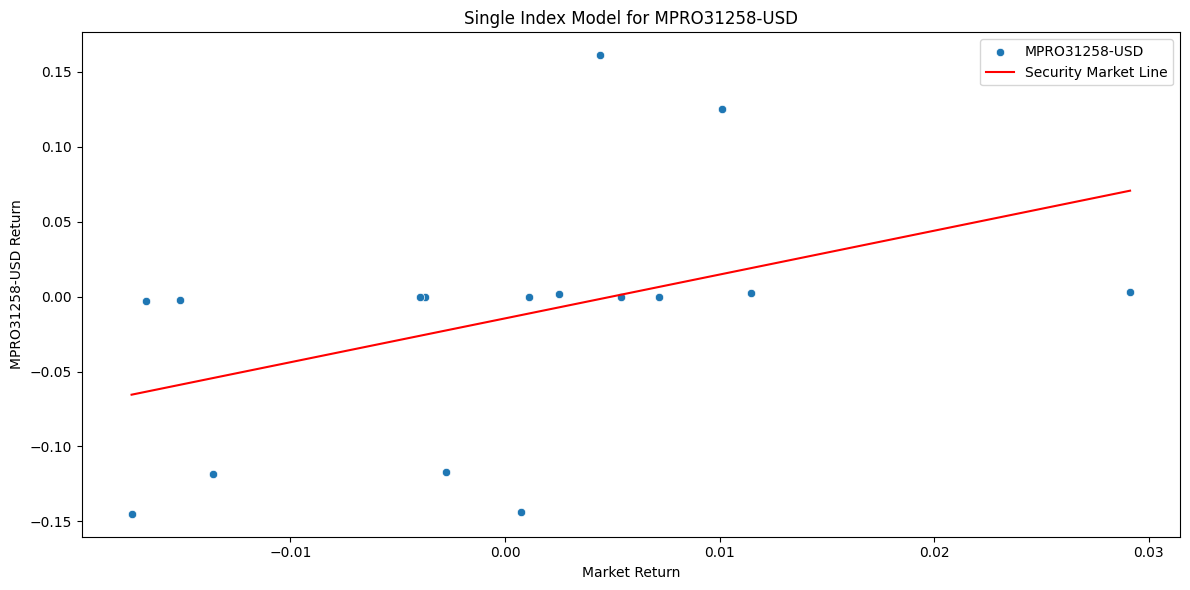

                            OLS Regression Results                            
Dep. Variable:                BTC-USD   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     8.408
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0116
Time:                        11:30:00   Log-Likelihood:                 39.082
No. Observations:                  16   AIC:                            -74.16
Df Residuals:                      14   BIC:                            -72.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.006      0.232      0.8

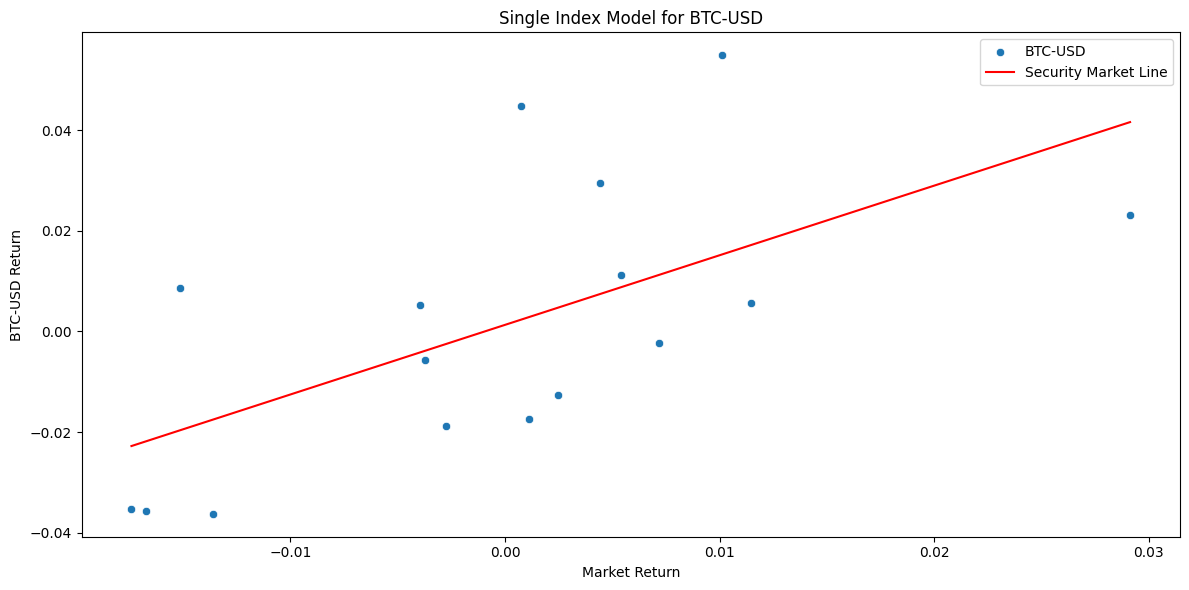

                            OLS Regression Results                            
Dep. Variable:                ETH-USD   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     6.953
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0195
Time:                        11:30:00   Log-Likelihood:                 30.679
No. Observations:                  16   AIC:                            -57.36
Df Residuals:                      14   BIC:                            -55.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0054      0.010      0.567      0.5

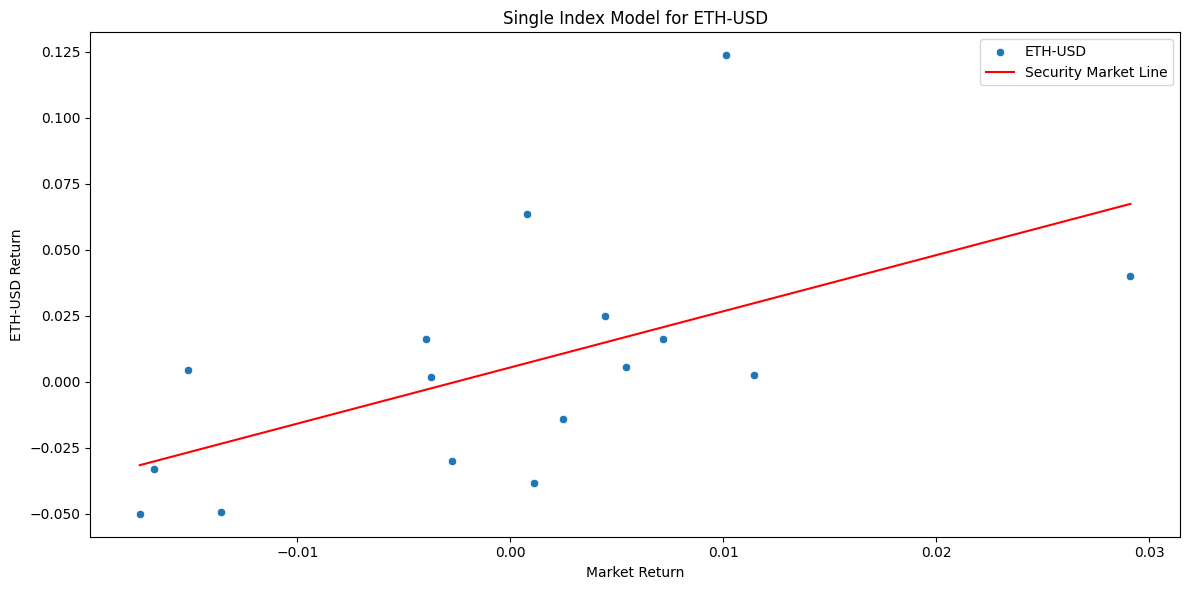

                            OLS Regression Results                            
Dep. Variable:               USDC-USD   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                 -0.044
Method:                 Least Squares   F-statistic:                    0.3738
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.551
Time:                        11:30:00   Log-Likelihood:                 114.89
No. Observations:                  16   AIC:                            -225.8
Df Residuals:                      14   BIC:                            -224.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.499e-05   4.92e-05     -0.305      0.7

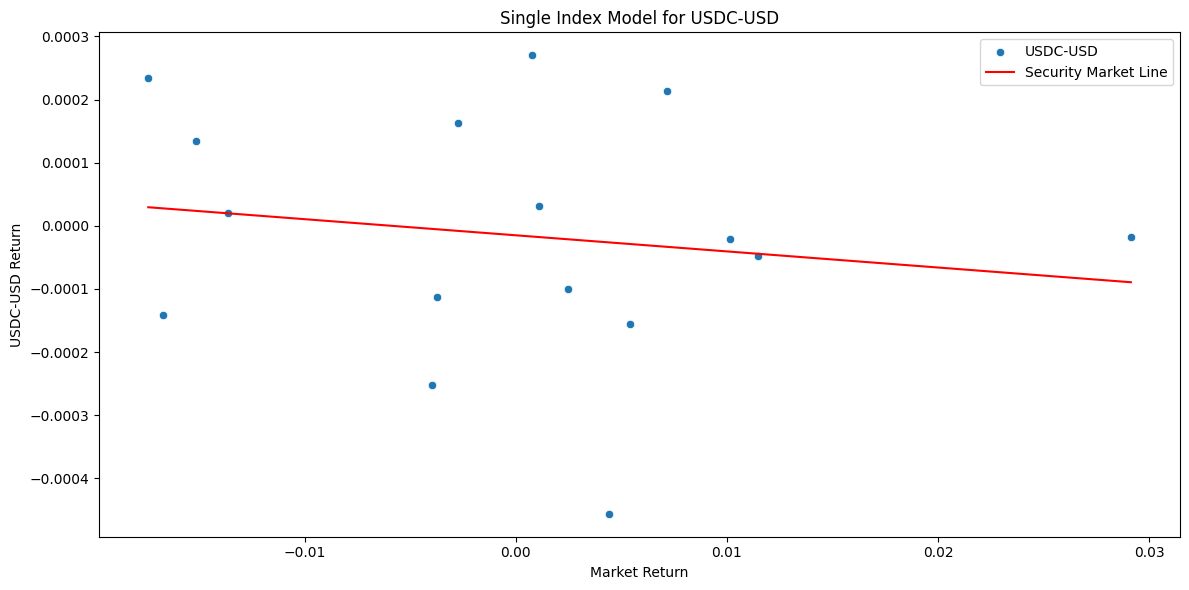

                            OLS Regression Results                            
Dep. Variable:                SOL-USD   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     4.605
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0499
Time:                        11:30:01   Log-Likelihood:                 31.954
No. Observations:                  16   AIC:                            -59.91
Df Residuals:                      14   BIC:                            -58.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.009     -0.111      0.9

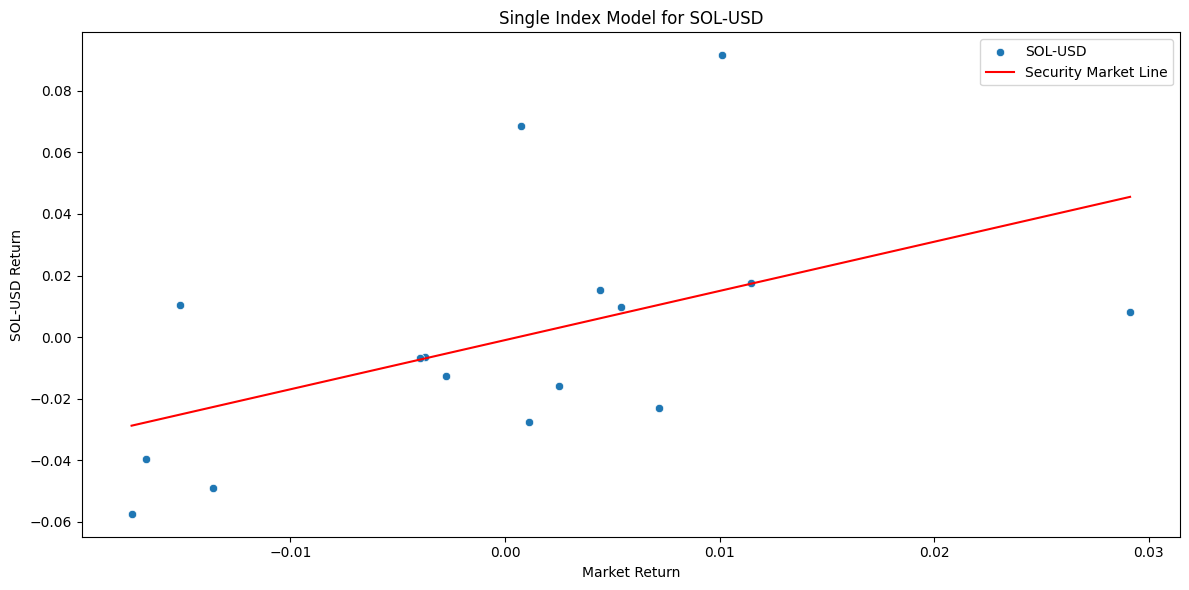

                            OLS Regression Results                            
Dep. Variable:                 JU-USD   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.241
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.284
Time:                        11:30:01   Log-Likelihood:                 35.240
No. Observations:                  16   AIC:                            -66.48
Df Residuals:                      14   BIC:                            -64.94
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0308      0.007      4.309      0.0

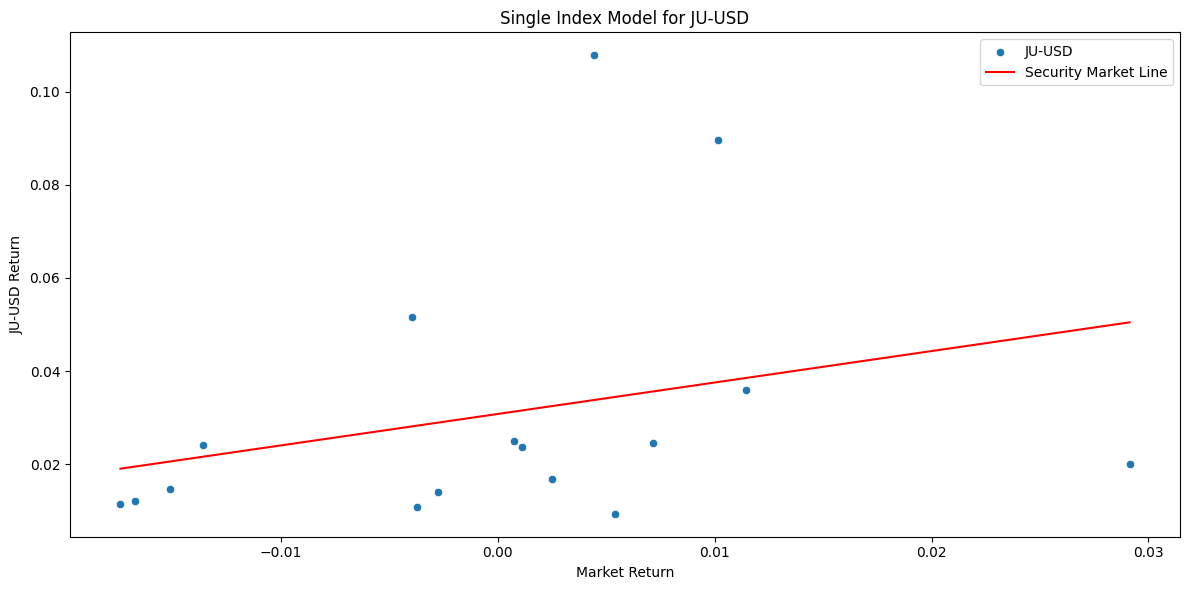

                            OLS Regression Results                            
Dep. Variable:                XRP-USD   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     4.327
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0564
Time:                        11:30:01   Log-Likelihood:                 33.999
No. Observations:                  16   AIC:                            -64.00
Df Residuals:                      14   BIC:                            -62.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.008     -0.020      0.9

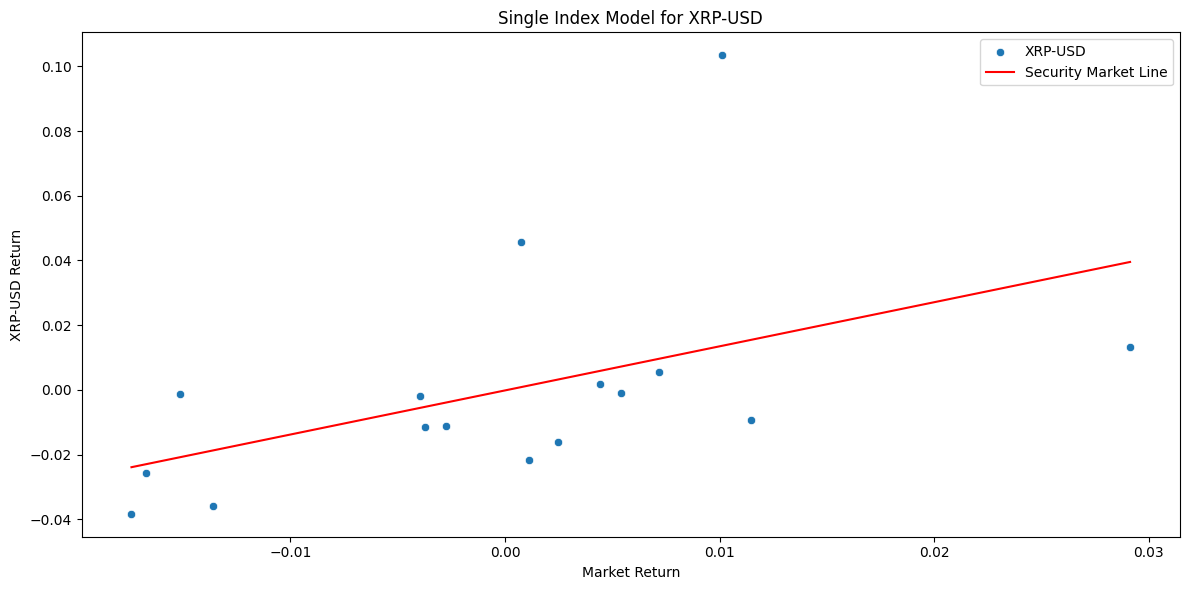

                            OLS Regression Results                            
Dep. Variable:           TAO22974-USD   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     2.144
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.165
Time:                        11:30:01   Log-Likelihood:                 21.889
No. Observations:                  16   AIC:                            -39.78
Df Residuals:                      14   BIC:                            -38.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0243      0.016      1.477      0.1

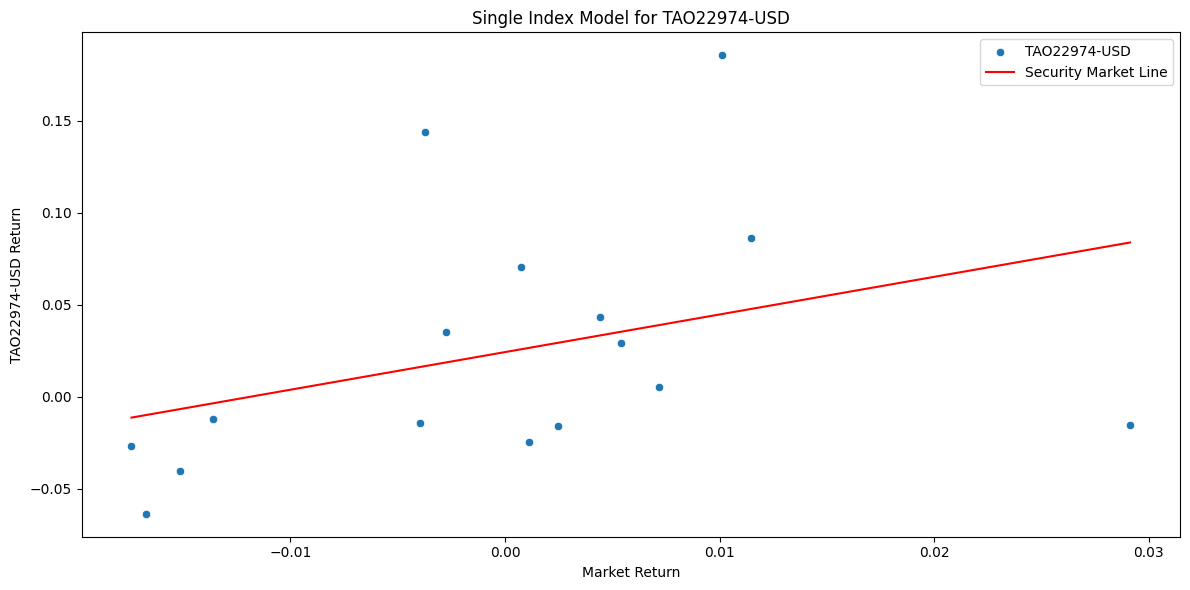

                            OLS Regression Results                            
Dep. Variable:                BNB-USD   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     3.949
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0668
Time:                        11:30:01   Log-Likelihood:                 39.620
No. Observations:                  16   AIC:                            -75.24
Df Residuals:                      14   BIC:                            -73.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0031      0.005     -0.568      0.5

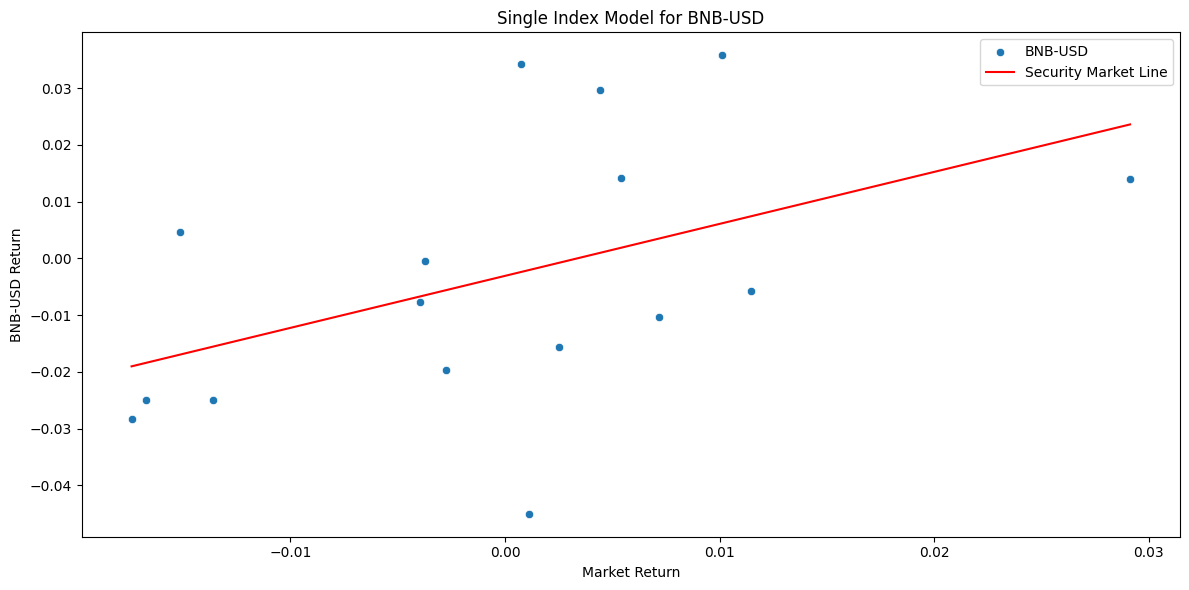

                            OLS Regression Results                            
Dep. Variable:               DOGE-USD   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     4.829
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0453
Time:                        11:30:02   Log-Likelihood:                 35.502
No. Observations:                  16   AIC:                            -67.00
Df Residuals:                      14   BIC:                            -65.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.614e-05      0.007     -0.005      0.9

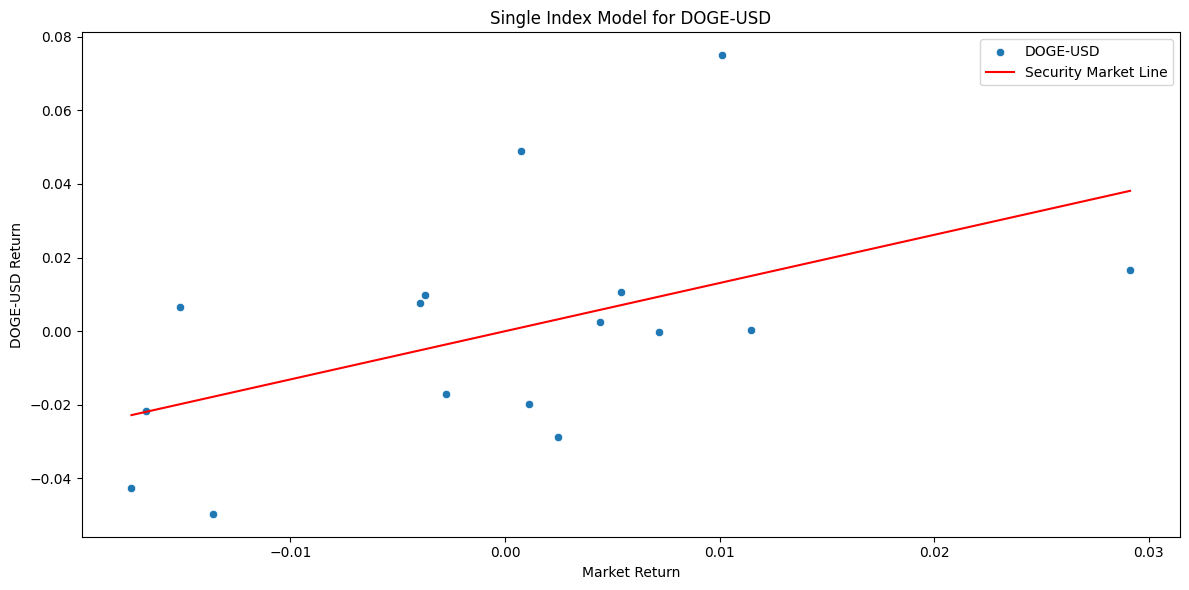

                            OLS Regression Results                            
Dep. Variable:          USD136148-USD   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.234
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.285
Time:                        11:30:02   Log-Likelihood:                 113.07
No. Observations:                  16   AIC:                            -222.1
Df Residuals:                      14   BIC:                            -220.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.575e-06   5.52e-05      0.119      0.9

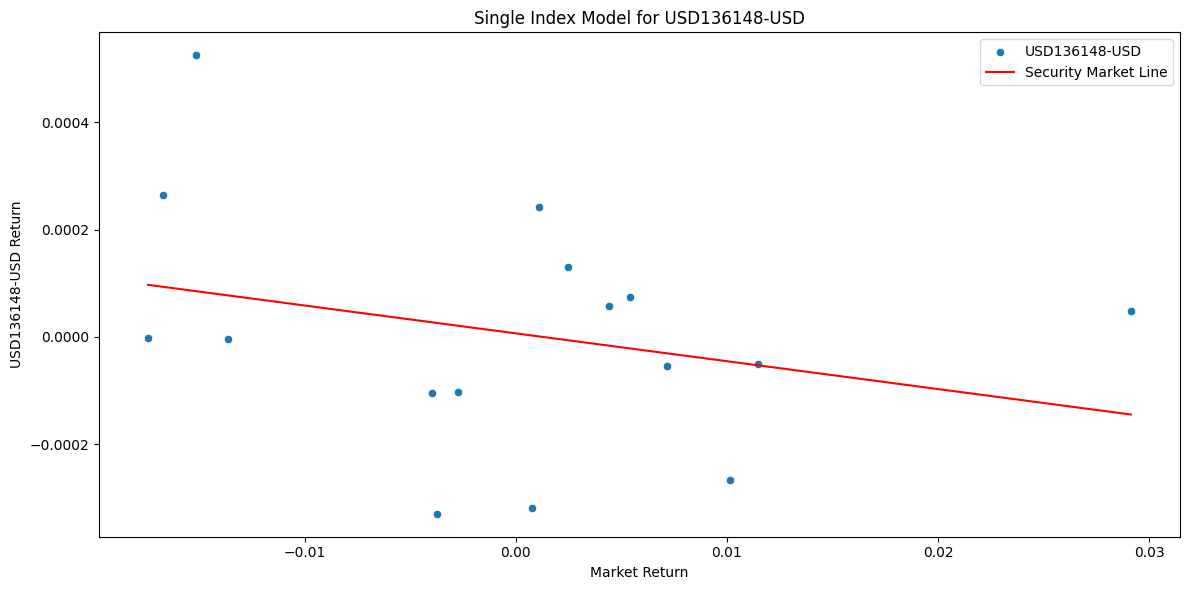

                            OLS Regression Results                            
Dep. Variable:               WETH-USD   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     6.888
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0200
Time:                        11:30:02   Log-Likelihood:                 30.507
No. Observations:                  16   AIC:                            -57.01
Df Residuals:                      14   BIC:                            -55.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0056      0.010      0.578      0.5

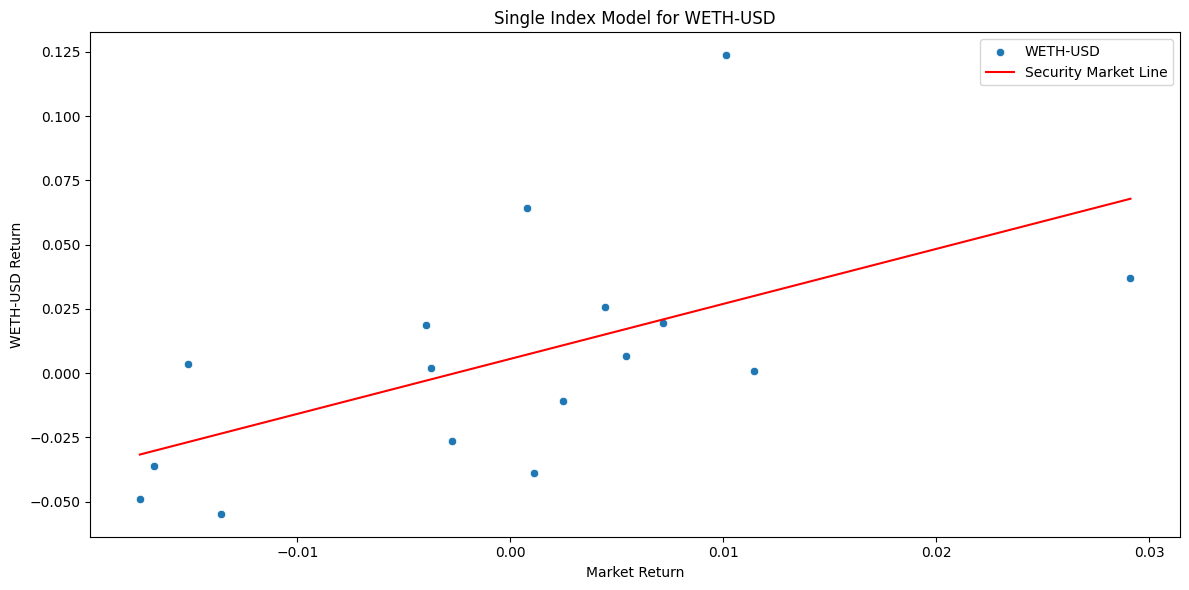

                            OLS Regression Results                            
Dep. Variable:                ZEC-USD   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     2.528
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.134
Time:                        11:30:02   Log-Likelihood:                 13.414
No. Observations:                  16   AIC:                            -22.83
Df Residuals:                      14   BIC:                            -21.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0331      0.028      1.185      0.2

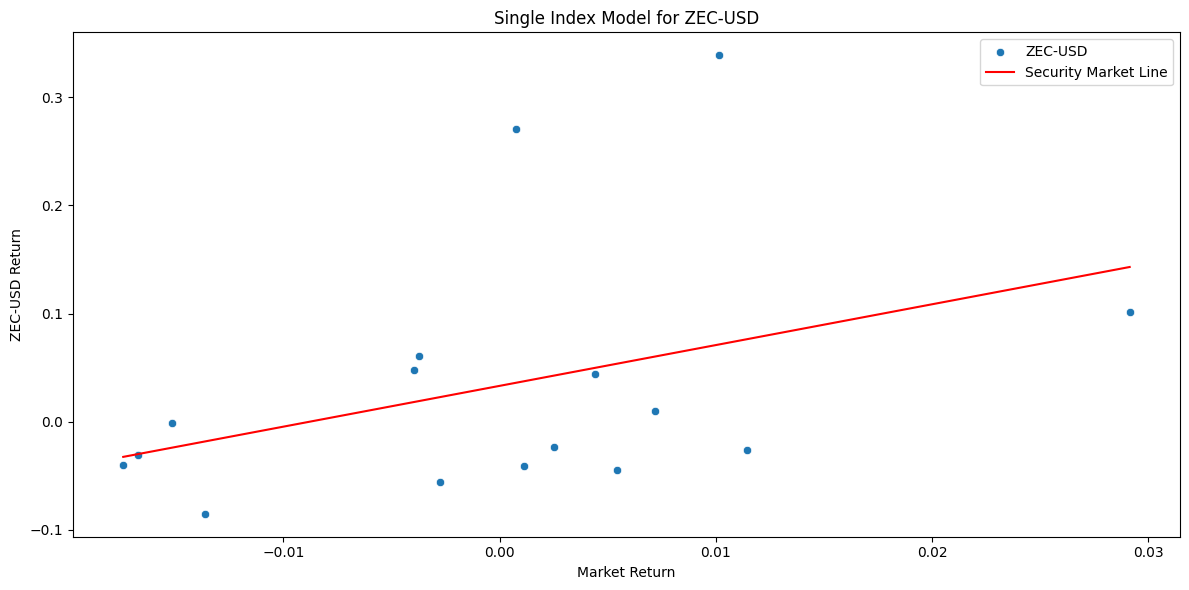

                            OLS Regression Results                            
Dep. Variable:            UP39665-USD   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.066
Method:                 Least Squares   F-statistic:                   0.06666
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.800
Time:                        11:30:02   Log-Likelihood:                 1.1844
No. Observations:                  16   AIC:                             1.631
Df Residuals:                      14   BIC:                             3.176
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1133      0.060      1.887      0.0

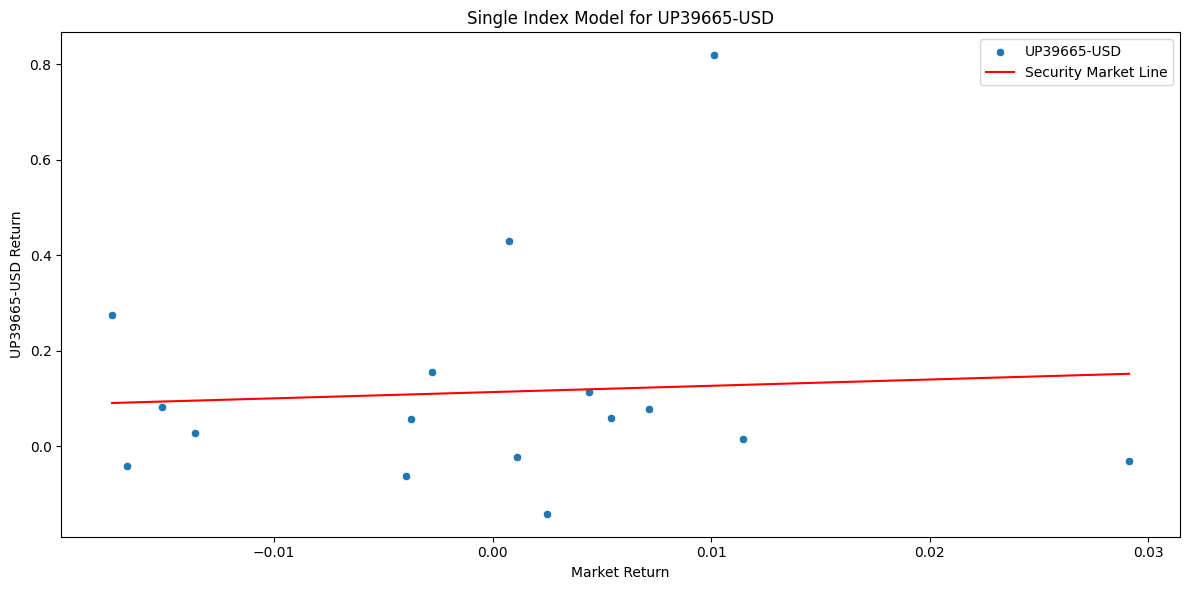

                            OLS Regression Results                            
Dep. Variable:               LINK-USD   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     6.291
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0251
Time:                        11:30:03   Log-Likelihood:                 32.874
No. Observations:                  16   AIC:                            -61.75
Df Residuals:                      14   BIC:                            -60.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.008      0.269      0.7

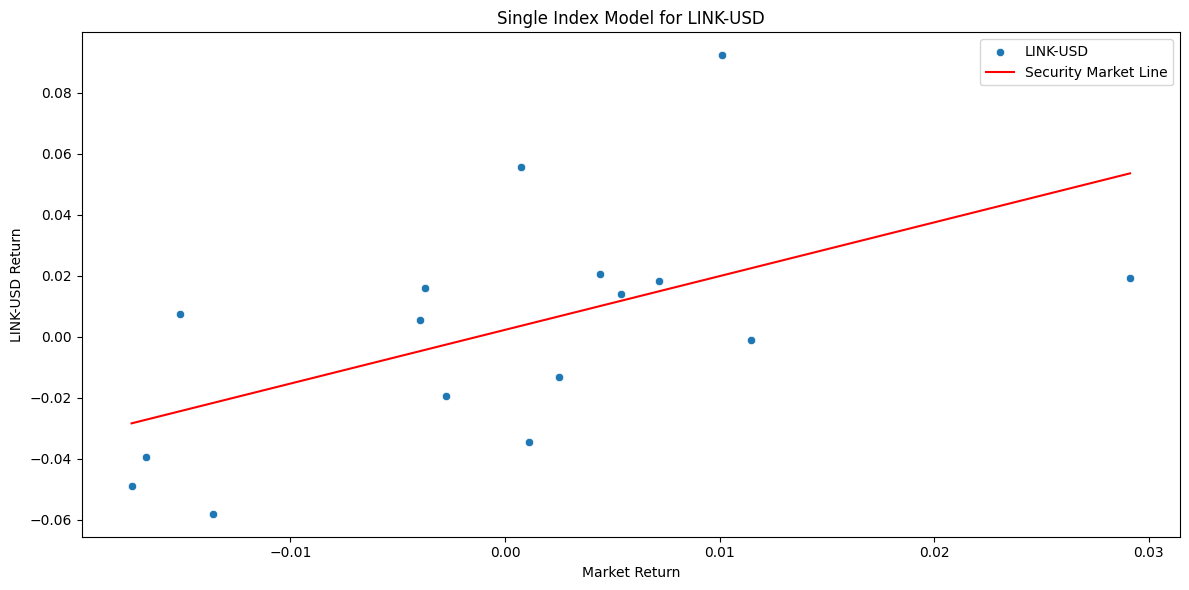

                            OLS Regression Results                            
Dep. Variable:                TRX-USD   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.057
Method:                 Least Squares   F-statistic:                    0.1942
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.666
Time:                        11:30:03   Log-Likelihood:                 44.115
No. Observations:                  16   AIC:                            -84.23
Df Residuals:                      14   BIC:                            -82.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.004      1.131      0.2

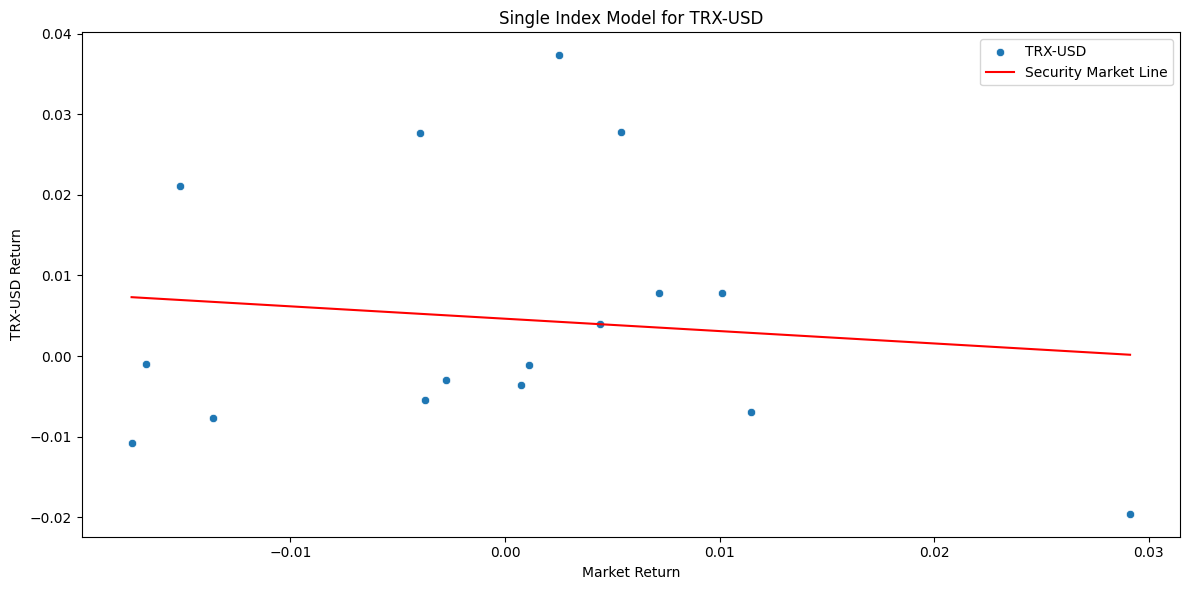

                            OLS Regression Results                            
Dep. Variable:           SOL16116-USD   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     4.422
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0540
Time:                        11:30:03   Log-Likelihood:                 31.779
No. Observations:                  16   AIC:                            -59.56
Df Residuals:                      14   BIC:                            -58.01
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0009      0.009     -0.101      0.9

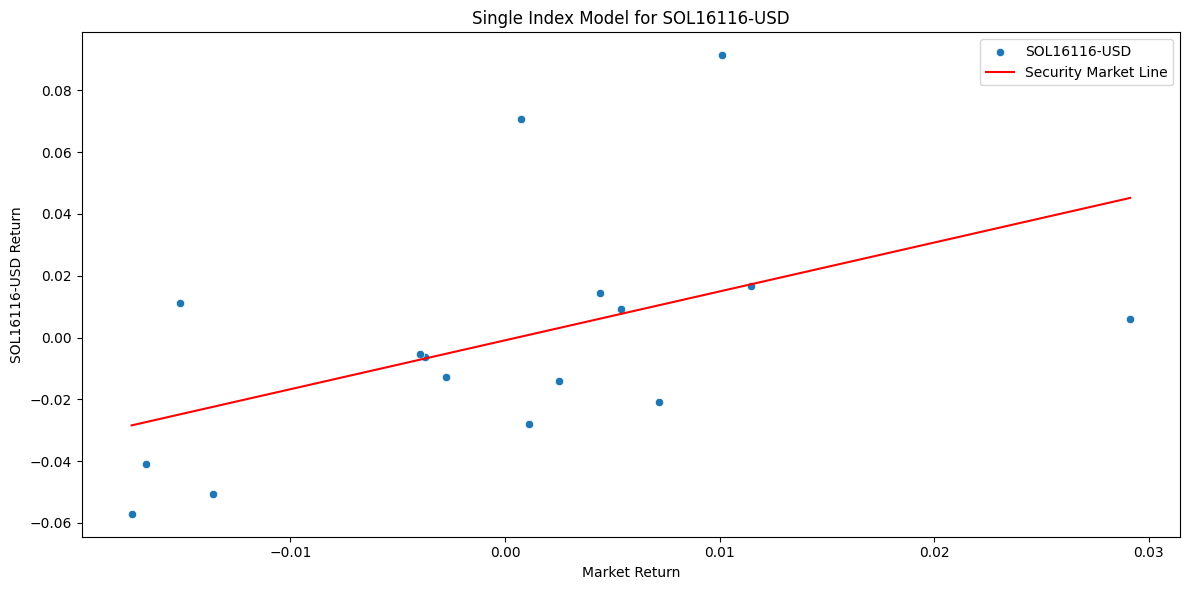

                            OLS Regression Results                            
Dep. Variable:                ADA-USD   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     3.477
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0833
Time:                        11:30:03   Log-Likelihood:                 30.651
No. Observations:                  16   AIC:                            -57.30
Df Residuals:                      14   BIC:                            -55.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.010      0.046      0.9

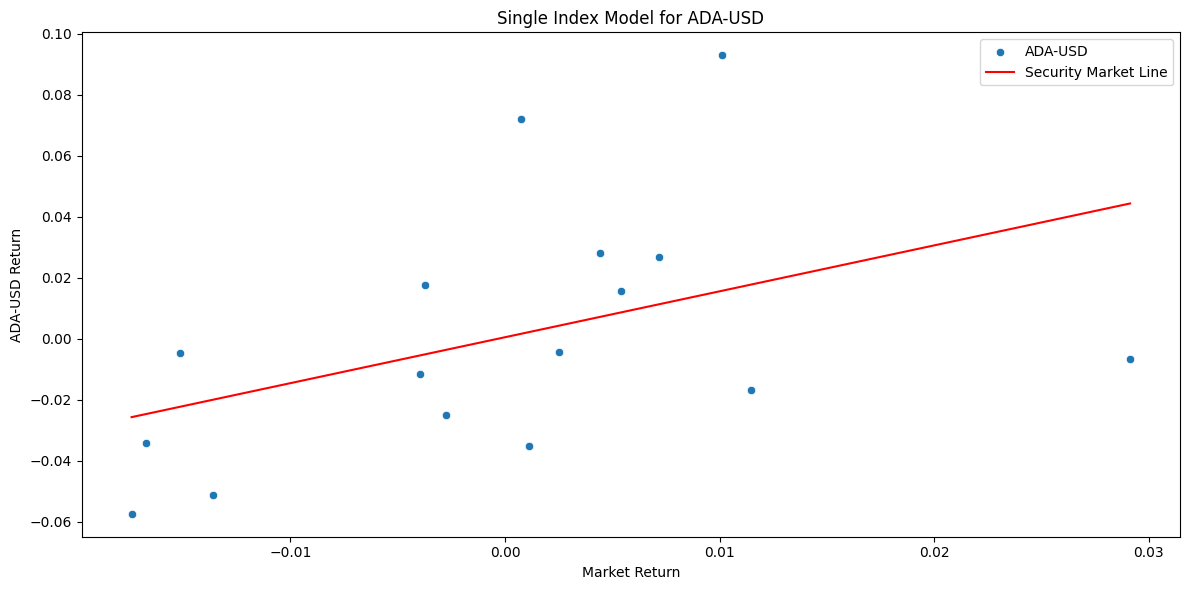

                            OLS Regression Results                            
Dep. Variable:         CBBTC32994-USD   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     8.247
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0123
Time:                        11:30:03   Log-Likelihood:                 38.797
No. Observations:                  16   AIC:                            -73.59
Df Residuals:                      14   BIC:                            -72.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.006      0.259      0.7

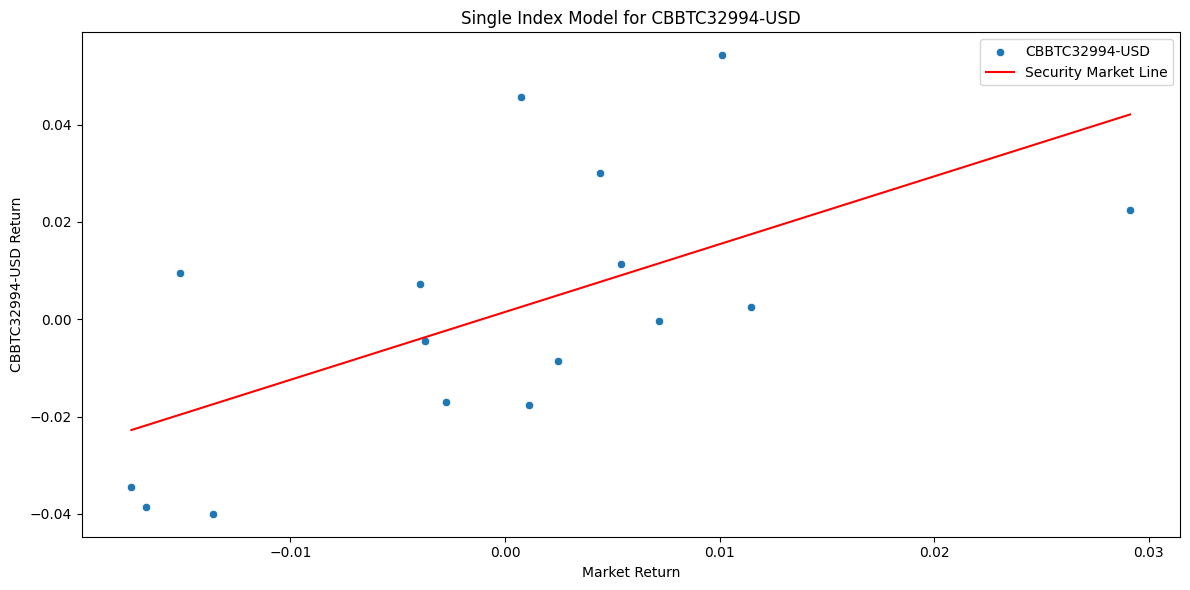

                            OLS Regression Results                            
Dep. Variable:                QUQ-USD   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                 0.0003605
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.985
Time:                        11:30:03   Log-Likelihood:                 27.506
No. Observations:                  16   AIC:                            -51.01
Df Residuals:                      14   BIC:                            -49.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0090      0.012      0.776      0.4

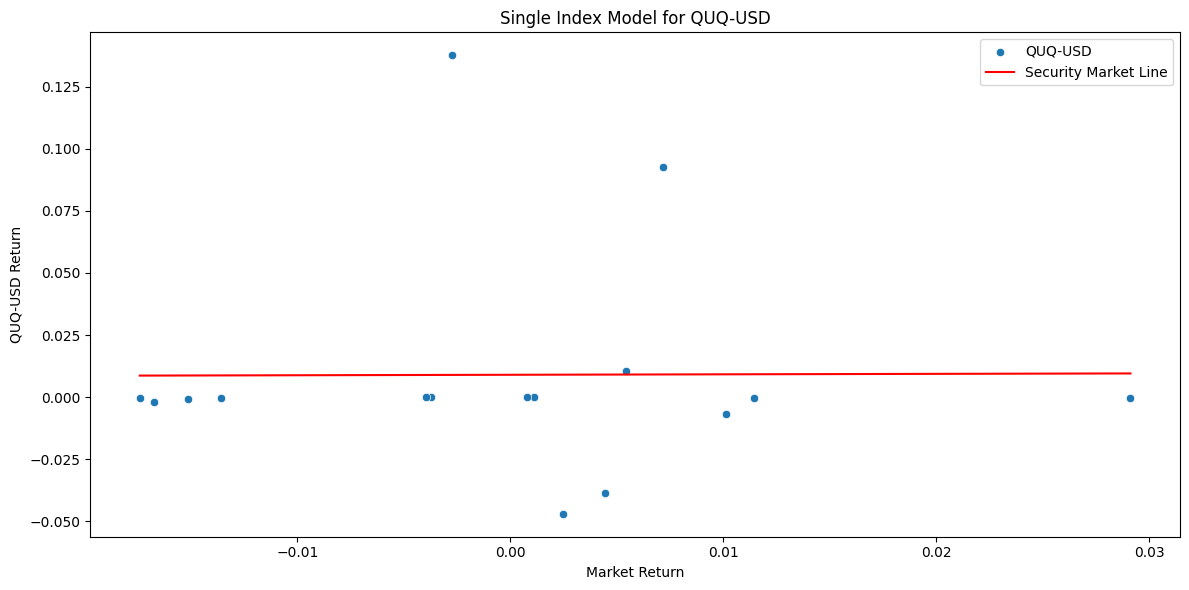

                            OLS Regression Results                            
Dep. Variable:           SUI20947-USD   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     3.430
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0852
Time:                        11:30:04   Log-Likelihood:                 30.130
No. Observations:                  16   AIC:                            -56.26
Df Residuals:                      14   BIC:                            -54.72
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.010     -0.137      0.8

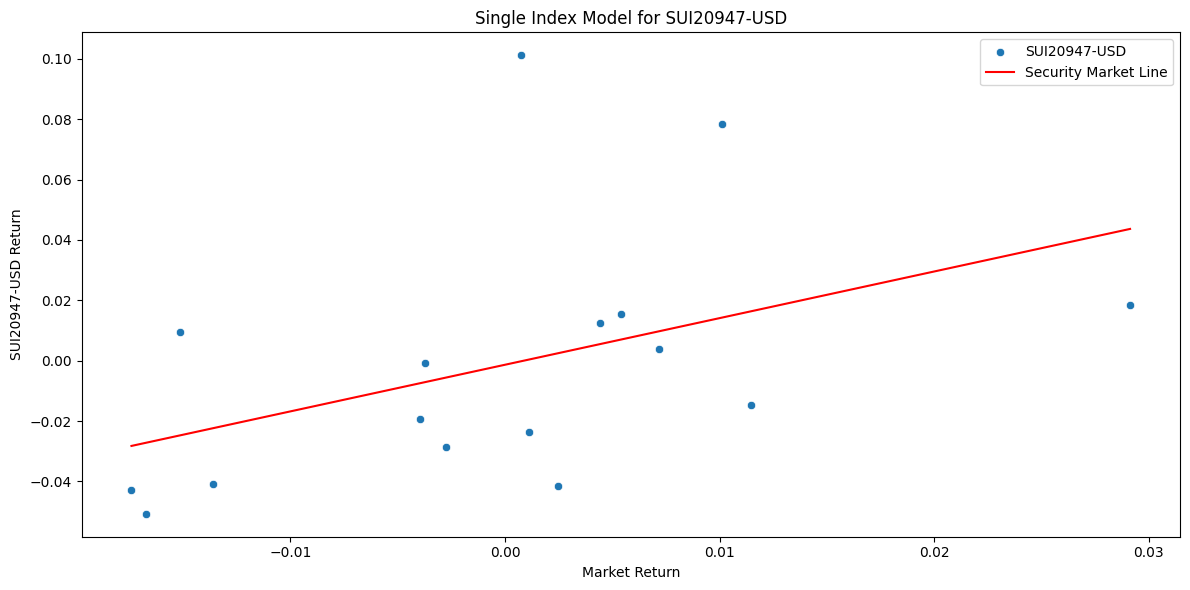

                            OLS Regression Results                            
Dep. Variable:          USDT39520-USD   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.062
Method:                 Least Squares   F-statistic:                    0.1193
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.735
Time:                        11:30:04   Log-Likelihood:                 89.903
No. Observations:                  16   AIC:                            -175.8
Df Residuals:                      14   BIC:                            -174.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.712e-06      0.000     -0.033      0.9

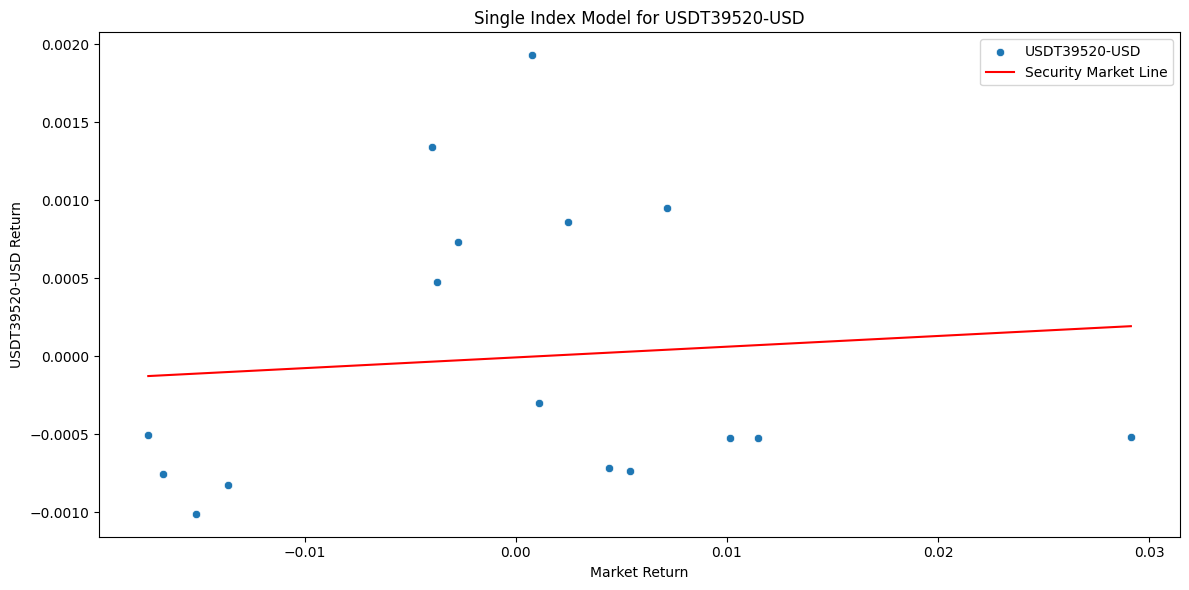

                            OLS Regression Results                            
Dep. Variable:          RAVE38967-USD   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.070
Method:                 Least Squares   F-statistic:                   0.01323
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.910
Time:                        11:30:04   Log-Likelihood:                 19.933
No. Observations:                  16   AIC:                            -35.87
Df Residuals:                      14   BIC:                            -34.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0083      0.019      0.445      0.6

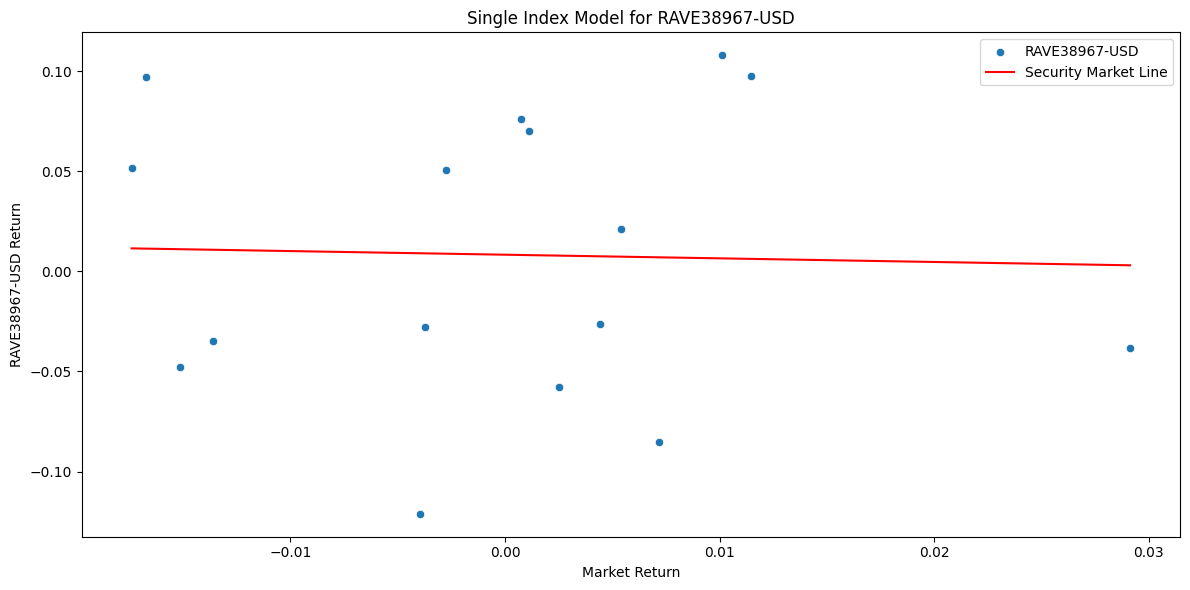

                            OLS Regression Results                            
Dep. Variable:          PEPE24478-USD   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.8382
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.375
Time:                        11:30:04   Log-Likelihood:                 6.4616
No. Observations:                  16   AIC:                            -8.923
Df Residuals:                      14   BIC:                            -7.378
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0315      0.043      0.730      0.4

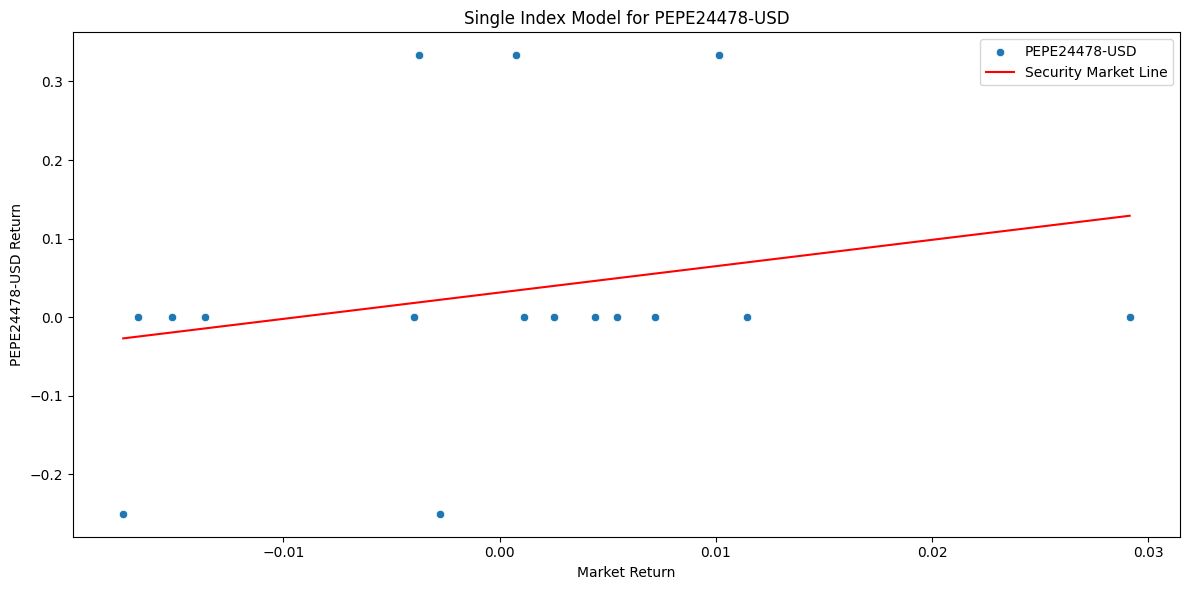

                            OLS Regression Results                            
Dep. Variable:          HYPE32196-USD   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.062
Method:                 Least Squares   F-statistic:                    0.1269
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.727
Time:                        11:30:04   Log-Likelihood:                 25.716
No. Observations:                  16   AIC:                            -47.43
Df Residuals:                      14   BIC:                            -45.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.013      0.371      0.7

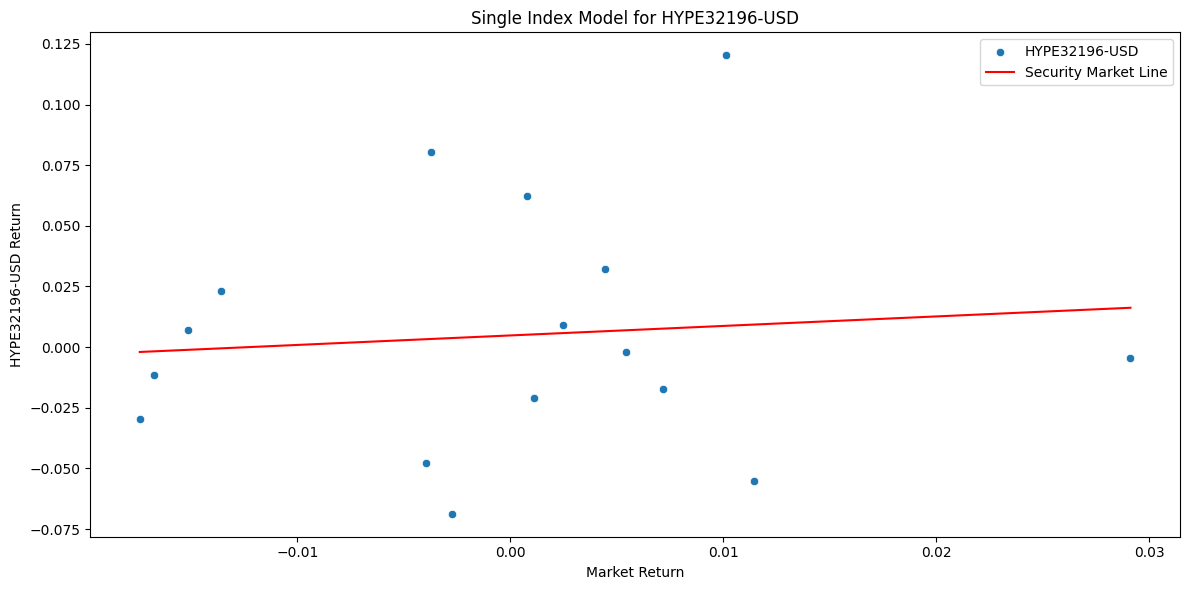

In [5]:
for ticker in config.all_tickers:
    if ticker == config.sp500_ticker:
        continue 
    
    print(get_models[ticker].summary())
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=returns[config.sp500_ticker], y=returns[ticker], label=ticker)
    fitted = sim.results[ticker].fittedvalues
    sns.lineplot(x=returns[config.sp500_ticker], y=fitted, color='red', label='Security Market Line')
    plt.title(f'Single Index Model for {ticker}')
    plt.xlabel('Market Return')
    plt.ylabel(f'{ticker} Return')
    plt.legend()
    plt.tight_layout()
    plt.show()
